Christopher Lagos Olate 
ICM

<font size="3">**Tarea 1 2026**</font>

<u> *Instrucciones* </u>

Su notebook con las respuestas a la tarea se deben entregar a mas tardar el dia 20/04/26 hasta las 23:59, subiendolo al repositorio en la carpeta tareas/2026 mediante un *pull request* desde su fork. 

Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. La data a utilizar es **student_productivity.csv**.

Las variables tienen la siguiente descripcion:

- student_id: Identificador único del estudiante.
- age: Edad del estudiante en años.
- gender: Género informado.
- academic_level: Nivel académico actual del estudiante.
- study_hours: Horas totales de estudio diario (incluye estudio en horario de clases y autoestudio).
- self_study_hours: Horas de estudio autónomo fuera de clases.
- online_classes_hours: Horas de clases online (Zoom, Teams, etc).
- social_media_hours: Horas diarias en redes sociales.
- gaming_hours: Horas diarias de videojuegos.
- screen_time_hours: Tiempo total frente a pantallas en horas.
- sleep_hours: Horas de sueño diarias.
- exercise_minutes: Minutos de ejercicio físico diario.
- caffeine_intake_mg: Miligramos de cafeína consumidos de forma diaria.
- part_time_job: Indica si es que el estudiante tiene un trabajo de medio tiempo o no.
- upcoming_deadline: Indica si es que el estudiante tiene alguna entrega o examen próximamente.
- internet_quality: Calidad de la conexión a internet disponible para estudiar.
- drug_use: Indicador de consumo de sustancias recreativas.
- mental_health_score: Puntuación de salud mental del estudiante autoreportada.
- focus_index: Indice que nos indica el nivel de concentración del estudiante.
- burnout_level: Nivel de agotamiento del estudiante.
- productivity_score: Nivel de productividad del estudiante.
- exam_score: Puntuación en el examen final (1.0 indica un estudiante que no rindio el examen).

Hint : Analisar correlaciones entre variables , valores de parametros ( porcentual , puntos porcentuales , unidades)
Combinar modelos con variables Independientes (Logaritmicas o exponenciales) con respecto a Y
Study_hours -> efecto creciente muy rapido al inicio y mas lento despues de un umbral 
Sleep_hours -> efecto creciente muy rapido al inicio y mas lento despues de un umbral
Analizar Distribuciones de los datos :
Las variables categoricas 
Realice supuestos de forma explicita y detallarlas en la tarea





<u> Preguntas (todas tienen el mismo puntaje): </u> 

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.

Todas estas variables que miden tiempo en horas podrían estar correlacionadas ya que la suma de estas es limitada por las 24 horas diarias y en particular :
Es possible que exista correlacion : study_hours, self_study_hours , online_classes_hours .
Por lo que se analizara primero la matriz de correlacion patra descaratar alguna(s) de estas varaibles y evitar la correlacion que causa sesgos en modelos como MCO.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Definir la ruta de forma robusta
# Si el CSV está en la misma carpeta que tu script (.py o .ipynb):
file_name = 'student_productivity.csv'

# Verificamos si el archivo existe en el directorio actual de trabajo
if os.path.exists(file_name):
    try:
        # Carga de la base de datos
        df = pd.read_csv(file_name)
        print(f"✅ Archivo cargado exitosamente: {file_name}")
        print(f"📊 Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
        
        # Vista rápida de los datos
        print("\nPrimeras filas:")
        print(df.head())
        
    except Exception as e:
        print(f"❌ Ocurrió un error al leer el archivo: {e}")
else:
    print(f"⚠️ Error: El archivo '{file_name}' no se encuentra en la carpeta actual.")
    print(f"Directorio actual: {os.getcwd()}")

# 2. Configuración estética para gráficos
sns.set_theme(style="whitegrid") # Actualizado de set_context para mejores visuales
plt.rcParams['figure.figsize'] = (10, 6)

✅ Archivo cargado exitosamente: student_productivity.csv
📊 Dimensiones: 5621 filas y 22 columnas.

Primeras filas:
   student_id   age  gender  academic_level  study_hours  self_study_hours  \
0           1  20.0     NaN   Undergraduate         5.37              2.09   
1           2  16.0  Female     High School         5.85              5.04   
2           3  18.0  Female   Undergraduate         5.69              2.27   
3           4  24.0    Male  Undergraduate          2.32              1.06   
4           5  24.0  Female    Postgraduate         3.87              2.63   

   online_classes_hours  social_media_hours  gaming_hours  sleep_hours  ...  \
0                  1.85                3.66          2.32         7.73  ...   
1                  1.87                3.60          2.79         6.11  ...   
2                  0.00                2.93          3.94         7.11  ...   
3                  2.30                4.34          2.37         8.54  ...   
4                  2.

In [2]:
#visualizacion de los datos
# Verificación de tipos de datos
print("--- Tipos de Datos por Columna ---")
print(df.dtypes)

# Visualización de las primeras filas para inspección visual
df.head()

--- Tipos de Datos por Columna ---
student_id                int64
age                     float64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes         object
caffeine_intake_mg      float64
part_time_job            object
upcoming_deadline       float64
internet_quality         object
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78


In [3]:
# correccion de variales 
# =========================================================
# TRANSFORMACIÓN DE VARIABLES (Minutos a Horas)
# =========================================================

# Convertimos a numérico primero. 
# 'coerce' transforma cualquier error o texto en NaN, asegurando el tipo float64.
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')

# Creamos la nueva variable dividiendo por 60
df['exercise_hours'] = df['exercise_minutes'] / 60.0

# Verificamos que sea float64 explícitamente
df['exercise_hours'] = df['exercise_hours'].astype('float64')

# (Opcional) Si quieres que 'exercise_minutes' también sea float64:
df['exercise_minutes'] = df['exercise_minutes'].astype('float64')

# =========================================================

# Configuración estética para gráficos
sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificación de resultados
print("\n--- Verificación de Tipos y Conversión ---")
print(df[['exercise_minutes', 'exercise_hours']].dtypes)
print("\nPrimeras filas transformadas:")
print(df[['exercise_minutes', 'exercise_hours']].head())

# Visualización de las primeras filas general
df.head()


--- Verificación de Tipos y Conversión ---
exercise_minutes    float64
exercise_hours      float64
dtype: object

Primeras filas transformadas:
   exercise_minutes  exercise_hours
0              54.0        0.900000
1              63.0        1.050000
2              28.0        0.466667
3              55.0        0.916667
4              60.0        1.000000


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score,exercise_hours
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08,0.900000
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83,1.050000
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66,0.466667
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00,0.916667
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78,1.000000


In [4]:
# 5. Creación de variable Dummy "Exam"
if 'exam_score' in df.columns:
    # Usamos np.where para una asignación vectorial más rápida
    df['Exam'] = np.where(df['exam_score'] == 1.0, 0, 1)
    
    print("✅ Variable dummy 'Exam' creada exitosamente.")
    # Verificamos la distribución de los nuevos valores
    print(df['Exam'].value_counts())
else:
    print("⚠️ Error: La columna 'exam_score' no existe en el DataFrame.")

✅ Variable dummy 'Exam' creada exitosamente.
1    5182
0     439
Name: Exam, dtype: int64


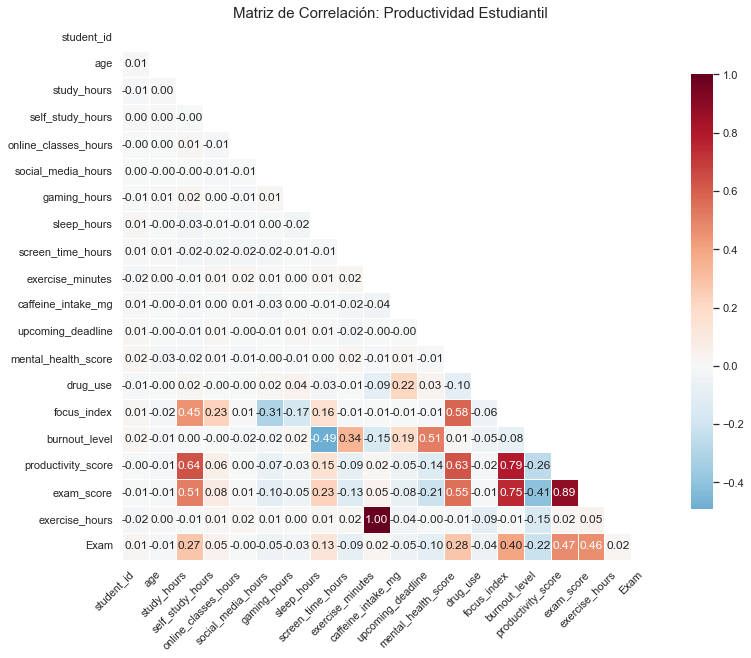

✅ Análisis completado. Dimensiones: (5621, 24)

Correlaciones más relevantes con 'Exam':
Exam                    1.000000
productivity_score      0.472041
exam_score              0.461213
focus_index             0.396567
mental_health_score     0.281133
study_hours             0.274776
sleep_hours             0.127962
self_study_hours        0.048799
exercise_hours          0.015859
exercise_minutes        0.015859
student_id              0.010543
online_classes_hours   -0.000932
age                    -0.012495
gaming_hours           -0.031663
drug_use               -0.044117
caffeine_intake_mg     -0.047898
social_media_hours     -0.050044
screen_time_hours      -0.085393
upcoming_deadline      -0.097925
burnout_level          -0.221640
Name: Exam, dtype: float64
--- Correlaciones Directas con Exam Score ---
exam_score              1.000000
productivity_score      0.886618
focus_index             0.750577
mental_health_score     0.547794
study_hours             0.509619
Exam         

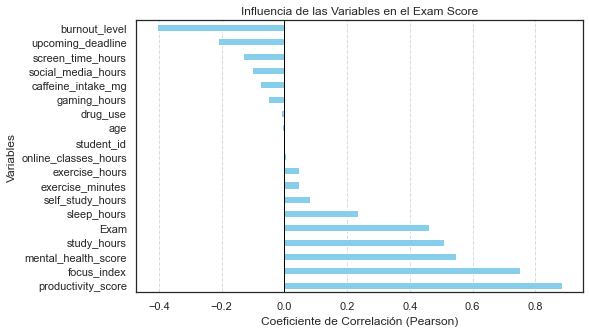

In [5]:
# =========================================================
# 2. MATRIZ DE CORRELACIÓN
# =========================================================

# Seleccionamos solo las variables numéricas
df_numeric = df.select_dtypes(include=[np.number])

# Calculamos la matriz de correlación (Pearson)
corr_matrix = df_numeric.corr()

# Configuración del gráfico
plt.figure(figsize=(12, 10))
sns.set_theme(style="white") # Estilo limpio para mapas de calor

# Creamos el mapa de calor (Heatmap)
# Se añade un 'mask' opcional para ver solo la mitad inferior (evita redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,           # Opcional: oculta la parte duplicada
            annot=True,          # Muestra los valores numéricos
            fmt=".2f",           # Dos decimales
            cmap='RdBu_r',       # Rojo (positivo) a Azul (negativo)
            center=0,            # El blanco queda en el 0
            linewidths=0.5,      
            square=True,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación: Productividad Estudiantil', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.show()

# =========================================================
# 3. VERIFICACIÓN Y ANALÍTICA
# =========================================================
print(f"✅ Análisis completado. Dimensiones: {df.shape}")
print("\nCorrelaciones más relevantes con 'Exam':")
if 'Exam' in corr_matrix.columns:
    print(corr_matrix['Exam'].sort_values(ascending=False))



# =========================================================
# ANALÍTICA: VARIABLES MÁS CORRELACIONADAS CON EXAM_SCORE
# =========================================================

if 'exam_score' in corr_matrix.columns:
    # 1. Extraer la correlación respecto a 'exam_score'
    # Usamos abs() porque una correlación negativa fuerte (ej. -0.8) 
    # es tan importante como una positiva (ej. 0.8)
    correlaciones_score = corr_matrix['exam_score'].sort_values(ascending=False)

    print("--- Correlaciones Directas con Exam Score ---")
    print(correlaciones_score)

    # 2. Visualización de las Top Correlaciones (excluyendo la variable misma)
    top_corr = correlaciones_score.drop('exam_score') # Quitamos la relación 1.0 con sigo misma
    
    plt.figure(figsize=(8, 5))
    top_corr.plot(kind='barh', color='skyblue')
    plt.axvline(0, color='black', linestyle='-', linewidth=1) # Línea en el eje 0
    plt.title('Influencia de las Variables en el Exam Score')
    plt.xlabel('Coeficiente de Correlación (Pearson)')
    plt.ylabel('Variables')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

else:
    print("La columna 'exam_score' no se encuentra en la matriz numérica.")

considerando que primero buscamos predecir la varible Exam ( es decir , si un estudiante rindio o no el examen)
Correlaciones más relevantes con 'Exam':
Exam                    1.000000
productivity_score      0.472041
exam_score              0.461213
focus_index             0.396567
mental_health_score     0.281133
study_hours             0.274776
sleep_hours             0.127962
self_study_hours        0.048799
exercise_hours          0.015859
exercise_minutes        0.015859
student_id              0.010543
online_classes_hours   -0.000932
age                    -0.012495
gaming_hours           -0.031663
drug_use               -0.044117
caffeine_intake_mg     -0.047898
social_media_hours     -0.050044
screen_time_hours      -0.085393
upcoming_deadline      -0.097925
burnout_level          -0.221640
estas variables son de interes porque estan correlacionadas con Exam 

Ademas cabe destacar que algunas de estas se correlacionan entre si :
productivity_score y exam_score (0.89)
focus_index y productivity_score (0.79): Relación muy fuerte. El enfoque explica casi todo el puntaje de productividad.focus_index y exam_score (0.75): Similar al punto anterior; el enfoque está íntimamente ligado al resultado del examen.study_hours y productivity_score (0.64): A más horas de estudio, mayor es la productividad reportada.
mental_health_score y drug_use (0.58): La relación más fuerte entre variables de bienestar personal
study_hours y exam_score (0.51): Correlación moderada-fuerte que valida que el tiempo de estudio afecta el resultado.mental_health_score y burnout_level (0.51): Relación directa entre el agotamiento y la salud mental.
sleep_hours y burnout_level (-0.49): Correlación negativa significativa; a menos sueño, mucho más nivel de agotamiento del estudiante 
study_hours y focus_index (0.45): Los estudiantes con más horas de estudio tienden a estar más enfocados.
productivity_score y burnout_level (-0.26): Una relación moderada que sugiere que el agotamiento reduce la eficiencia percibida del estudiante.
exam_score y burnout_level (-0.21): Similar a la anterior; el agotamiento tiene un impacto negativo directo en el resultado del examen.
Exam y burnout_level (-0.22): Indica que el tipo de examen (según tu dummy) está relacionado con niveles variables de estrés o agotamiento.
focus_index y social_media_hours (-0.31): Una de las correlaciones de distracción más claras. A más horas en redes sociales, menor es el índice de enfoque reportado.
focus_index y gaming_hours (-0.17): Aunque es más débil que las redes sociales, el tiempo de juego también muestra una tendencia a reducir el enfoque.
mental_health_score y social_media_hours (-0.14): Existe una ligera tendencia a que más horas en redes sociales coincidan con un menor puntaje de salud mental.

Considerando esto limpiaremos estas variables primero 
productivity_score      0.472041
focus_index             0.396567
mental_health_score     0.281133
study_hours             0.274776
sleep_hours             0.127962
self_study_hours        0.048799
exercise_hours          0.015859
exercise_minutes        0.015859
online_classes_hours   -0.000932
age                    -0.012495
gaming_hours           -0.031663
drug_use               -0.044117
caffeine_intake_mg     -0.047898
social_media_hours     -0.050044
screen_time_hours      -0.085393
upcoming_deadline      -0.097925
burnout_level          -0.221640

por ejemplo la variable 
drug_use tiene + del 70% de NAs por lo que lo mejor seria quitar esta variable
El resto de variables numericas todas tienen una distribucion con tendencia a la normalidad 
Variables Numericas : 
age                     float64   12% NAs y es muy poco influyente en las variables a modelar 
study_hours             float64   10% de NAs , es una variable importante 
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_horas          float64
caffeine_intake_mg      float64
upcoming_deadline       float64
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64

Nos crntraremos en las variables mas correlacionadas con Exam (sobre 5%):
productivity_score      0.472041
focus_index             0.396567
mental_health_score     0.281133
study_hours             0.274776
sleep_hours             0.127962
social_media_hours     -0.050044
screen_time_hours      -0.085393
upcoming_deadline      -0.097925
burnout_level          -0.221640







In [6]:
# =========================================================
# FILTRADO POR VARIABLES ESPECÍFICAS CON MISSINGS
# =========================================================

# 1. Definimos la lista exacta de variables a revisar
variables_objetivo = [
    'productivity_score', 
    'focus_index', 
    'mental_health_score', 
    'study_hours', 
    'sleep_hours', 
    'social_media_hours', 
    'screen_time_hours', 
    'upcoming_deadline', 
    'burnout_level'
]

# 2. Aplicamos el filtro: solo filas donde alguna de estas variables sea NaN
df_filtrado_especifico = df[df[variables_objetivo].isnull().any(axis=1)]

# 3. Reporte de resultados
print(f"--- Análisis de Missings en Variables Seleccionadas ---")
print(f"Se encontraron {len(df_filtrado_especifico)} estudiantes con datos faltantes en este grupo.")

if not df_filtrado_especifico.empty:
    print("\nDetalle de nulos por cada variable en el filtro:")
    print(df_filtrado_especifico[variables_objetivo].isnull().sum().sort_values(ascending=False))
    
    print("\nVisualización de las filas filtradas (primeras 5):")
    print(df_filtrado_especifico.head())
else:
    print("\n✅ No hay valores faltantes en ninguna de las variables de la lista.")

--- Análisis de Missings en Variables Seleccionadas ---
Se encontraron 1351 estudiantes con datos faltantes en este grupo.

Detalle de nulos por cada variable en el filtro:
upcoming_deadline      717
burnout_level          716
mental_health_score    675
social_media_hours     656
productivity_score     638
focus_index            633
screen_time_hours      586
study_hours            574
sleep_hours            553
dtype: int64

Visualización de las filas filtradas (primeras 5):
    student_id   age  gender academic_level  study_hours  self_study_hours  \
14          15  21.0     NaN   Postgraduate         3.37               NaN   
19          20   NaN     NaN            NaN          NaN               NaN   
26          27   NaN     NaN            NaN          NaN               NaN   
37          38  18.0  Female  Postgraduate          3.14               NaN   
38          39  19.0    Male            NaN         9.61               NaN   

    online_classes_hours  social_media_hours  gami

In [7]:
# =========================================================
# LIMPIEZA Y ESTANDARIZACIÓN DE VARIABLES CATEGÓRICAS
# =========================================================

# 1. Lista de variables a procesar
vars_a_completar = ['gender', 'academic_level', 'part_time_job']

for col in vars_a_completar:
    if col in df.columns:
        # A. Reemplazar nulos (NaN) por "Other" antes de transformar
        df[col] = df[col].fillna('Other')
        
        # B. NORMALIZACIÓN TOTAL (Unifica "yes", "Yes ", "undergraduate", etc.)
        # .astype(str) asegura que podamos aplicar funciones de texto
        # .str.strip() elimina espacios accidentales al inicio/final
        # .str.capitalize() pone la primera en Mayúscula y el resto en minúscula
        df[col] = df[col].astype(str).str.strip().str.capitalize()
        
        # C. Limpieza de residuos y unificación de "Other"
        # Tras astype(str), los NaN se vuelven "Nan". Los agrupamos todos.
        reemplazos_extra = {
            'Nan': 'Other', 
            'None': 'Other', 
            'Null': 'Other',
            '': 'Other'
        }
        df[col] = df[col].replace(reemplazos_extra)
        
        print(f"✅ Columna '{col}': Nulos completados, espacios eliminados y texto estandarizado.")

# =========================================================
# VERIFICACIÓN DE RESULTADOS
# =========================================================
print("\n" + "="*50)
print("RECUENTO DE CATEGORÍAS ÚNICAS (Sin duplicados)")
print("="*50)

for col in vars_a_completar:
    # Verificamos que no existan repetidos por espacios o mayúsculas
    valores_unicos = df[col].unique()
    print(f"📌 {col}: {valores_unicos}")

print("\n--- Conteo de Nulos Final ---")
print(df[vars_a_completar].isnull().sum())

# Verificación específica de conteo para confirmar la unión de "Yes" y "yes"
if 'part_time_job' in df.columns:
    print("\nDistribución final de 'part_time_job':")
    print(df['part_time_job'].value_counts())

✅ Columna 'gender': Nulos completados, espacios eliminados y texto estandarizado.
✅ Columna 'academic_level': Nulos completados, espacios eliminados y texto estandarizado.
✅ Columna 'part_time_job': Nulos completados, espacios eliminados y texto estandarizado.

RECUENTO DE CATEGORÍAS ÚNICAS (Sin duplicados)
📌 gender: ['Other' 'Female' 'Male']
📌 academic_level: ['Undergraduate' 'High school' 'Postgraduate' 'Other']
📌 part_time_job: ['No' 'Yes' 'Other']

--- Conteo de Nulos Final ---
gender            0
academic_level    0
part_time_job     0
dtype: int64

Distribución final de 'part_time_job':
No       2469
Yes      2449
Other     703
Name: part_time_job, dtype: int64


En las variables de interes : Se encontraron 1351 estudiantes con datos faltantes 
Por ejemplo variables como 
gender, academic_level , part_time_job , podemos completarla con Other a los datos faltantes
Ademas part_time_job debe ser correguida ya que tiene "Yes" y "yes" como valores distintos 

In [8]:
# =========================================================
# LIMPIEZA Y ESTANDARIZACIÓN DE VARIABLES CATEGÓRICAS
# =========================================================

# 1. Lista de variables a completar con "Other"
vars_a_completar = ['gender', 'academic_level', 'part_time_job']

# Aplicamos fillna para reemplazar nulos (NaN) por "Other"
for col in vars_a_completar:
    if col in df.columns:
        df[col] = df[col].fillna('Other')
        print(f"✅ Columna '{col}': Nulos completados con 'Other'")

# 2. Corregir 'part_time_job' (Unificar "Yes" y "yes")
if 'part_time_job' in df.columns:
    # Opción A: Convertir todo a minúscula y luego capitalizar (ej: yes -> Yes)
    df['part_time_job'] = df['part_time_job'].str.capitalize()
    
    # Opción B (Más específica si hay otros errores):
    # df['part_time_job'] = df['part_time_job'].replace({'yes': 'Yes', 'no': 'No'})

    print("✅ Columna 'part_time_job': Valores estandarizados.")

# =========================================================
# VERIFICACIÓN DE RESULTADOS
# =========================================================
print("\n--- Resumen de categorías en 'part_time_job' ---")
print(df['part_time_job'].value_counts())

print("\n--- Conteo de Nulos Final ---")
print(df[vars_a_completar].isnull().sum())

# Mostrar las primeras filas para confirmar cambios
print("\nVista previa de los datos corregidos:")
print(df[vars_a_completar].head(10))

✅ Columna 'gender': Nulos completados con 'Other'
✅ Columna 'academic_level': Nulos completados con 'Other'
✅ Columna 'part_time_job': Nulos completados con 'Other'
✅ Columna 'part_time_job': Valores estandarizados.

--- Resumen de categorías en 'part_time_job' ---
No       2469
Yes      2449
Other     703
Name: part_time_job, dtype: int64

--- Conteo de Nulos Final ---
gender            0
academic_level    0
part_time_job     0
dtype: int64

Vista previa de los datos corregidos:
   gender academic_level part_time_job
0   Other  Undergraduate            No
1  Female    High school            No
2  Female  Undergraduate            No
3    Male  Undergraduate            No
4  Female   Postgraduate            No
5  Female          Other            No
6   Other  Undergraduate           Yes
7  Female   Postgraduate           Yes
8  Female  Undergraduate           Yes
9  Female   Postgraduate           Yes


Para las variables numericas esto es mas complejo ya si rellenamos con la media o moda o mediana esto podria sesgar el modelo :
productivity_score      0.472041   
focus_index             0.396567
burnout_level          -0.221640
Ademas agregaremos las variables : part_time_job y academic_level 

Relaciones : Focus_index y study_hours tienen correlacion : quitaremos la menos correlacionada con Exam "study_hours"
Focus_index y mental_health_score tienen correlacion :quitaremos la menos correlacionada con Exam "mental_health_score "
Focus_index y sleep_hours ,social_media_hours  tambien 
burnout_level y screen_time_hours , upcoming_deadline  estan correlacionado 

Se aplicara un modleo MCO simplemente con todas las variables eliminando filas con NAs

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Definir variables a omitir (según tu instrucción previa)
columnas_a_omitir = ['student_id', 'exam_score', 'exercise_minutes']
df_modelo = df.drop(columns=columnas_a_omitir, errors='ignore').copy()

# 2. LIMPIEZA ESPECÍFICA (Imputación y Corrección)
# Variables para completar con "Other"
vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_modelo.columns:
        # Completar nulos con 'Other'
        df_modelo[col] = df_modelo[col].fillna('Other')
        
        # Corregir 'part_time_job' (yes/Yes -> Yes)
        if col == 'part_time_job':
            df_modelo[col] = df_modelo[col].astype(str).str.capitalize()

print("✅ Limpieza de variables categóricas completada.")

# 3. Eliminación de filas con NAs restantes
# Esto eliminará filas que tengan nulos en variables numéricas (como study_hours, etc.)
df_final = df_modelo.dropna()

print(f"📊 Filas tras limpieza y dropna(): {len(df_final)} de {len(df)}")

# 4. Preparación de X (Predictoras) y y (Target)
y = df_final['Exam']
X_raw = df_final.drop(columns=['Exam'])

# Convertir categóricas a Dummies (evitando la trampa de la multicolinealidad)
X = pd.get_dummies(X_raw, drop_first=True)

# 5. Ajuste del Modelo MCO (OLS)
X = sm.add_constant(X) # Añadir intercepto

# Ejecutar el modelo asegurando tipos numéricos
modelo_completo = sm.OLS(y, X.astype(float)).fit()

# 6. Resumen de resultados
print("\n" + "="*60)
print("RESUMEN DEL MODELO MCO (CON LIMPIEZA DE CATEGÓRICAS)")
print("="*60)
print(modelo_completo.summary())

✅ Limpieza de variables categóricas completada.
📊 Filas tras limpieza y dropna(): 988 de 5621

RESUMEN DEL MODELO MCO (CON LIMPIEZA DE CATEGÓRICAS)
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     15.04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           3.44e-53
Time:                        23:14:29   Log-Likelihood:                -22.719
No. Observations:                 988   AIC:                             97.44
Df Residuals:                     962   BIC:                             224.7
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t 

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Definir variables a excluir y preparar el dataset
# Excluimos id (no aporta info), exam_score (ya tenemos la dummy Exam) 
# y exercise_minutes (usaremos exercise_hours para evitar colinealidad)
columnas_a_omitir = ['student_id', 'exam_score', 'exercise_minutes']

# Creamos una copia del dataframe original para no alterarlo
df_modelo = df.drop(columns=columnas_a_omitir, errors='ignore')

# 2. Eliminación de filas con NAs (Requisito de MCO)
df_limpio = df_modelo.dropna()

print(f"✅ Filas originales: {len(df)}")
print(f"✅ Filas después de dropna(): {len(df_limpio)}")

# 3. Separación de Variables: X (Predictoras) y y (Target)
# El target es la variable dummy 'Exam' que creaste
y = df_limpio['Exam']
X_raw = df_limpio.drop(columns=['Exam'])

# 4. Transformación de categóricas a Dummies
# drop_first=True evita la redundancia (Trampa de la variable ficticia)
X = pd.get_dummies(X_raw, drop_first=True)

# 5. Ajuste del Modelo MCO (OLS)
# Añadimos la constante (el intercepto b0)
X = sm.add_constant(X)

# Convertimos a float para asegurar compatibilidad con statsmodels
modelo_completo = sm.OLS(y, X.astype(float)).fit()

# 6. Resumen de resultados
print("\n" + "="*60)
print("RESUMEN DEL MODELO MCO (TODAS LAS VARIABLES)")
print("="*60)
print(modelo_completo.summary())

✅ Filas originales: 5621
✅ Filas después de dropna(): 988

RESUMEN DEL MODELO MCO (TODAS LAS VARIABLES)
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     15.04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           3.44e-53
Time:                        23:14:29   Log-Likelihood:                -22.719
No. Observations:                 988   AIC:                             97.44
Df Residuals:                     962   BIC:                             224.7
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------

Se aplicara MCO con las 5 variables antens mencionadas pero eliminando filas con NAs

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Selección de variables para el modelo
# Incluimos las numéricas y las categóricas solicitadas
columnas_x = [
    'productivity_score', 
    'focus_index', 
    'burnout_level', 
    'part_time_job', 
    'academic_level'
]
target = 'Exam'

# 2. Preparación de los datos (Manejo de categóricas)
# Seleccionamos solo lo necesario y convertimos categóricas a dummies
# drop_first=True evita la trampa de la multicolinealidad
X = pd.get_dummies(df[columnas_x], drop_first=True)
y = df[target]

# 3. Manejo de valores nulos (MCO no acepta NaNs)
# Como pediste "sin limpiar", eliminamos filas con nulos solo para el cálculo del modelo
X = X.dropna()
y = y[X.index] # Alineamos el target con las filas restantes de X

# 4. Añadir la constante (Intercepto)
# Statsmodels no añade el intercepto automáticamente como Sklearn
X = sm.add_constant(X)

# 5. Ajuste del modelo MCO (OLS)
modelo_ols = sm.OLS(y, X.astype(float)).fit()

# 6. Mostrar el resumen de resultados
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     187.4
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          3.20e-275
Time:                        23:14:29   Log-Likelihood:                -62.031
No. Observations:                4629   AIC:                             142.1
Df Residuals:                    4620   BIC:                             200.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

Solo nos quedamos con 900 de los 5600 datos , lo cual es un gran sesgo potencial.
Porbaremos con variables rellandas con la media y mediana y moda




In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Preparación de columnas y copia de seguridad
columnas_a_omitir = ['student_id', 'exam_score', 'exercise_minutes']
df_modelo = df.drop(columns=columnas_a_omitir, errors='ignore').copy()

# =========================================================
# 2. CREACIÓN DE DUMMY "gaming_hours_Index"
# =========================================================
# 1 si tiene dato (no es nulo), 0 si es nulo (faltante)
df_modelo['gaming_hours_Index'] = np.where(df_modelo['gaming_hours'].isna(), 0, 1)

# Opcional: Una vez creada la dummy, podemos llenar los nulos de la original con 0 
# para que no den error en el modelo MCO
df_modelo['gaming_hours'] = df_modelo['gaming_hours'].fillna(0)

# =========================================================
# 3. IMPUTACIÓN DE VARIABLES CATEGÓRICAS Y LIMPIEZA
# =========================================================
vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_modelo.columns:
        # Completar con 'Other'
        df_modelo[col] = df_modelo[col].fillna('Other')
        # Estandarizar 'part_time_job'
        if col == 'part_time_job':
            df_modelo[col] = df_modelo[col].astype(str).str.capitalize()

# =========================================================
# 4. IMPUTACIÓN DE VARIABLES NUMÉRICAS RESTANTES (Para no borrar filas)
# =========================================================
# Llenamos el resto de nulos numéricos con la mediana para mantener la muestra
cols_numericas = df_modelo.select_dtypes(include=[np.number]).columns
df_modelo[cols_numericas] = df_modelo[cols_numericas].fillna(df_modelo[cols_numericas].median())

print(f"✅ Proceso completado. Filas finales para el modelo: {len(df_modelo)}")

# =========================================================
# 5. EJECUCIÓN DEL MODELO MCO
# =========================================================
y = df_modelo['Exam']
X_raw = df_modelo.drop(columns=['Exam'])

# Convertir a dummies (incluyendo las nuevas categorías 'Other')
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

modelo_final = sm.OLS(y, X.astype(float)).fit()

print("\n" + "="*60)
print("RESUMEN DEL MODELO MCO (MUESTRA COMPLETA)")
print("="*60)
print(modelo_final.summary())

✅ Proceso completado. Filas finales para el modelo: 5621

RESUMEN DEL MODELO MCO (MUESTRA COMPLETA)
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     68.53
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          2.65e-311
Time:                        23:14:30   Log-Likelihood:                 195.91
No. Observations:                5621   AIC:                            -337.8
Df Residuals:                    5594   BIC:                            -158.7
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Preparación de columnas y copia de trabajo
columnas_a_omitir = ['student_id', 'exam_score', 'exercise_minutes']
df_modelo = df.drop(columns=columnas_a_omitir, errors='ignore').copy()

# =========================================================
# 2. CREACIÓN DE VARIABLE DUMMY "gaming_hours_Index"
# =========================================================
# 1 si el estudiante respondió (no es nulo), 0 si es dato faltante
df_modelo['gaming_hours_Index'] = np.where(df_modelo['gaming_hours'].isna(), 0, 1)

# Una vez creada la dummy, llenamos los nulos de la original con 0 
# para que el modelo MCO pueda procesar la columna numérica
df_modelo['gaming_hours'] = df_modelo['gaming_hours'].fillna(0)

# =========================================================
# 3. IMPUTACIÓN DE VARIABLES CATEGÓRICAS
# =========================================================
vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_modelo.columns:
        # Completar con 'Other'
        df_modelo[col] = df_modelo[col].fillna('Other')
        # Estandarizar 'part_time_job' (yes -> Yes)
        if col == 'part_time_job':
            df_modelo[col] = df_modelo[col].astype(str).str.capitalize()

# =========================================================
# 4. IMPUTACIÓN DE VARIABLES NUMÉRICAS CON LA MEDIA
# =========================================================
# Seleccionamos todas las columnas que sean de tipo número (float/int)
cols_numericas = df_modelo.select_dtypes(include=[np.number]).columns

# Rellenamos los NaNs con la media aritmética de cada columna
df_modelo[cols_numericas] = df_modelo[cols_numericas].fillna(df_modelo[cols_numericas].mean())

print(f"✅ Imputación por media completada.")
print(f"📊 Filas finales para el modelo MCO: {len(df_modelo)}")

# =========================================================
# 5. EJECUCIÓN DEL MODELO MCO (OLS)
# =========================================================
# Definimos Target (y) y Predictoras (X)
y = df_modelo['Exam']
X_raw = df_modelo.drop(columns=['Exam'])

# Convertir variables de texto a Dummies numéricas
X = pd.get_dummies(X_raw, drop_first=True)

# Añadimos la constante (intercepto b0)
X = sm.add_constant(X)

# Ajuste del modelo asegurando que todo sea tipo float
modelo_final_media = sm.OLS(y, X.astype(float)).fit()

# Mostrar resultados
print("\n" + "="*60)
print("RESUMEN DEL MODELO MCO (IMPUTACIÓN POR MEDIA)")
print("="*60)
print(modelo_final_media.summary())

✅ Imputación por media completada.
📊 Filas finales para el modelo MCO: 5621

RESUMEN DEL MODELO MCO (IMPUTACIÓN POR MEDIA)
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     68.60
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.30e-311
Time:                        23:14:30   Log-Likelihood:                 196.64
No. Observations:                5621   AIC:                            -339.3
Df Residuals:                    5594   BIC:                            -160.2
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025   

In [14]:
# =========================================================
# FILTRADO DE ESTUDIANTES CON VALORES FALTANTES (MISSING)
# =========================================================

# 1. Definimos las columnas a evaluar (todas excepto 'drug_use')
cols_a_evaluar = [col for col in df.columns if col != 'drug_use']

# 2. Creamos el filtro: 
# .isnull() identifica Nulos
# .any(axis=1) selecciona la fila si tiene al menos un True en las columnas elegidas
filas_con_missing = df[df[cols_a_evaluar].isnull().any(axis=1)]

# 3. Verificación de resultados
print(f"--- Reporte de Datos Faltantes (Excluyendo 'drug_use') ---")
print(f"Total de filas con al menos un missing: {len(filas_con_missing)}")

# Mostramos las primeras filas que cumplen la condición
if not filas_con_missing.empty:
    print("\nPrimeras filas encontradas:")
    print(filas_con_missing.head())
    
    # Opcional: Mostrar qué columnas tienen los nulos en estas filas
    print("\nConteo de nulos por columna en este subgrupo:")
    print(filas_con_missing[cols_a_evaluar].isnull().sum().sort_values(ascending=False))
else:
    print("\nNo se encontraron filas con valores faltantes en las variables seleccionadas.")

--- Reporte de Datos Faltantes (Excluyendo 'drug_use') ---
Total de filas con al menos un missing: 2093

Primeras filas encontradas:
    student_id   age  gender academic_level  study_hours  self_study_hours  \
14          15  21.0   Other   Postgraduate         3.37               NaN   
15          16  17.0    Male    High school         8.23              2.55   
19          20   NaN   Other          Other          NaN               NaN   
22          23  19.0  Female    High school         6.13              1.97   
26          27   NaN   Other          Other          NaN               NaN   

    online_classes_hours  social_media_hours  gaming_hours  sleep_hours  ...  \
14                  1.70                3.78          1.63         6.17  ...   
15                  4.11                1.84          1.08         7.83  ...   
19                   NaN                 NaN           NaN          NaN  ...   
22                  0.80                0.00          0.57         7.35  ...  

Total de filas con al menos un missing: 2126


2. Ejecute un modelo de probabilidad lineal (*MCO*) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Preparación de columnas y copia de trabajo
columnas_a_omitir = ['student_id', 'exam_score', 'exercise_minutes']
df_modelo = df.drop(columns=columnas_a_omitir, errors='ignore').copy()

# =========================================================
# 2. CREACIÓN DE VARIABLE DUMMY "gaming_hours_Index"
# =========================================================
# 1 si el estudiante respondió (no es nulo), 0 si es dato faltante
df_modelo['gaming_hours_Index'] = np.where(df_modelo['gaming_hours'].isna(), 0, 1)

# Una vez creada la dummy, llenamos los nulos de la original con 0 
# para que el modelo MCO pueda procesar la columna numérica
df_modelo['gaming_hours'] = df_modelo['gaming_hours'].fillna(0)

# =========================================================
# 3. IMPUTACIÓN DE VARIABLES CATEGÓRICAS
# =========================================================
vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_modelo.columns:
        # Completar con 'Other'
        df_modelo[col] = df_modelo[col].fillna('Other')
        # Estandarizar 'part_time_job' (yes -> Yes)
        if col == 'part_time_job':
            df_modelo[col] = df_modelo[col].astype(str).str.capitalize()

# =========================================================
# 4. IMPUTACIÓN DE VARIABLES NUMÉRICAS CON LA MEDIA
# =========================================================
# Seleccionamos todas las columnas que sean de tipo número (float/int)
cols_numericas = df_modelo.select_dtypes(include=[np.number]).columns

# Rellenamos los NaNs con la media aritmética de cada columna
df_modelo[cols_numericas] = df_modelo[cols_numericas].fillna(df_modelo[cols_numericas].mean())

print(f"✅ Imputación por media completada.")
print(f"📊 Filas finales para el modelo MCO: {len(df_modelo)}")

# =========================================================
# 5. EJECUCIÓN DEL MODELO MCO (OLS)
# =========================================================
# Definimos Target (y) y Predictoras (X)
y = df_modelo['Exam']
X_raw = df_modelo.drop(columns=['Exam'])

# Convertir variables de texto a Dummies numéricas
X = pd.get_dummies(X_raw, drop_first=True)

# Añadimos la constante (intercepto b0)
X = sm.add_constant(X)

# Ajuste del modelo asegurando que todo sea tipo float
modelo_final_media = sm.OLS(y, X.astype(float)).fit()

# Mostrar resultados
print("\n" + "="*60)
print("RESUMEN DEL MODELO MCO (IMPUTACIÓN POR MEDIA)")
print("="*60)
print(modelo_final_media.summary())

✅ Imputación por media completada.
📊 Filas finales para el modelo MCO: 5621

RESUMEN DEL MODELO MCO (IMPUTACIÓN POR MEDIA)
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     68.60
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.30e-311
Time:                        23:14:34   Log-Likelihood:                 196.64
No. Observations:                5621   AIC:                            -339.3
Df Residuals:                    5594   BIC:                            -160.2
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025   


Variables significativas  : 
const                             0.7213     
focus_index                       0.0036      
burnout_level                    -0.0021      
productivity_score                0.0051   

1. Constante (Intercepto) = 0.7213
Significado: Un estudiante con niveles "cero" en enfoque, productividad y burnout tiene una probabilidad base del 72.13% de presentarse al examen. Esto sugiere que la tendencia general en la UdeC (o en tu dataset) es asistir, independientemente de los factores psicológicos.

2. Focus Index (0.0036)
Interpretación: Manteniendo las demás variables constantes, por cada punto adicional en el índice de enfoque, la probabilidad de que el alumno se presente al examen aumenta en 0.036 unidades (0.36%).

Lectura: Estar más enfocado no solo sirve para estudiar mejor, sino que reduce la probabilidad de deserción o inasistencia el día de la prueba. Un alumno disperso tiene más riesgo de "no llegar".

3. Burnout Level (-0.0021)
Interpretación: Manteniendo lo demás constante, por cada unidad adicional de agotamiento, la probabilidad de realizar el examen disminuye en 0.021 unidades (0.21%).

Lectura: El burnout actúa como un factor de deserción. Un nivel alto de estrés crónico (ej. un aumento de 50 puntos) reduce la probabilidad de asistencia en un 10.5%. El agotamiento físico y mental es una barrera real que impide al alumno siquiera intentar la evaluación.

4. Productivity Score (0.0051)
Interpretación: Manteniendo las demás variables constantes, por cada punto extra de productividad percibida, la probabilidad de asistir al examen aumenta en 0.051 unidades (0.51%).

Lectura: Es el factor más determinante. Los alumnos que se sienten productivos tienen mucha más confianza o capacidad logística para presentarse. 

In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Selección de variables significativas
# Basado en tu análisis de P-valores < 0.05
variables_finales = [
    'focus_index', 
    'burnout_level', 
    'productivity_score'
]

# 2. Preparación de los datos
# Usamos el DataFrame que ya tiene las imputaciones (media/Other)
X_final = df_modelo[variables_finales].copy()
y_final = df_modelo['Exam']

# 3. Añadir la constante (el 0.7213 que mencionaste)
X_final = sm.add_constant(X_final)

# 4. Ajuste del Modelo OLS
modelo_refinado = sm.OLS(y_final, X_final.astype(float)).fit()

# 5. Visualización de resultados
print("="*60)
print("REPORTE DEL MODELO FINAL REFINADO")
print("="*60)
print(modelo_refinado.summary())

REPORTE DEL MODELO FINAL REFINADO
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                     563.3
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          4.31e-320
Time:                        23:14:34   Log-Likelihood:                 158.06
No. Observations:                5621   AIC:                            -308.1
Df Residuals:                    5617   BIC:                            -281.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
co

El coeficiente de determinación (R^2) de 0.231 significa que las variables independientes del modelo (focus_index, burnout_level y productivity_score) explican el 23.1% de la variabilidad en la decisión de los alumnos de asistir o no al examen (Exam).

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Ajustar el modelo (usando las variables significativas)
variables_finales = ['focus_index', 'burnout_level', 'productivity_score']
X = sm.add_constant(df_modelo[variables_finales])
y = df_modelo['Exam']
modelo = sm.OLS(y, X.astype(float)).fit()

# 2. Obtener las probabilidades predichas (valores entre 0 y 1)
predicciones_continuas = modelo.predict(X)

# 3. Convertir a 0 o 1 usando un umbral (ejemplo: 0.5)
# Si el modelo dice > 0.5, predecimos que SÍ asiste (1)
umbral = 0.5
predicciones_binarias = (predicciones_continuas >= umbral).astype(int)

# 4. Evaluación de la "Aproximación"
accuracy = accuracy_score(y, predicciones_binarias)

print(f"--- Evaluación de la Clasificación (Umbral {umbral}) ---")
print(f"Precisión Global (Accuracy): {accuracy:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y, predicciones_binarias))
print("\nReporte de Clasificación:")
print(classification_report(y, predicciones_binarias))

# 5. Guardar resultados en el DataFrame para ver la comparación
df_modelo['Prediccion_MCO'] = predicciones_continuas
df_modelo['Asistencia_Estimada'] = predicciones_binarias

--- Evaluación de la Clasificación (Umbral 0.5) ---
Precisión Global (Accuracy): 0.9219

Matriz de Confusión:
[[   0  439]
 [   0 5182]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       439
           1       0.92      1.00      0.96      5182

    accuracy                           0.92      5621
   macro avg       0.46      0.50      0.48      5621
weighted avg       0.85      0.92      0.88      5621



c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


3. Ejecute un modelo *probit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 


FALTARIA : MODLEAR PROBIT Y LOGIT USANDO SOLO LAS VARIABLES DEL MCO INICIAL SIN CORRELACION 

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Preparación y limpieza inicial
df_probit = df.copy()

# =========================================================
# 2. CORRECCIÓN ESPECÍFICA: part_time_job (Yes/yes)
# =========================================================
if 'part_time_job' in df_probit.columns:
    # Convertimos a string, quitamos espacios y ponemos la primera en Mayúscula
    df_probit['part_time_job'] = df_probit['part_time_job'].astype(str).str.strip().str.capitalize()
    
    # Ahora reemplazamos los 'Nan' (que se volvieron string) por 'Other'
    df_probit['part_time_job'] = df_probit['part_time_job'].replace({'Nan': 'Other', 'None': 'Other'})

print("✅ Variable 'part_time_job' unificada (Yes/No/Other).")

# =========================================================
# 3. CREACIÓN DE DUMMY: gaming_hours_Index
# =========================================================
df_probit['gaming_hours_Index'] = np.where(df_probit['gaming_hours'].isna(), 0, 1)
df_probit['gaming_hours'] = df_probit['gaming_hours'].fillna(0)

# =========================================================
# 4. RESTO DE CATEGÓRICAS A "Other"
# =========================================================
for col in ['gender', 'academic_level']:
    if col in df_probit.columns:
        df_probit[col] = df_probit[col].fillna('Other')

# 5. Omitir nulos restantes y ejecutar Probit
df_final = df_probit.drop(columns=['student_id', 'exam_score', 'exercise_minutes'], errors='ignore').dropna()

y = df_final['Exam']
X = pd.get_dummies(df_final.drop(columns=['Exam']), drop_first=True)
X = sm.add_constant(X)

modelo_probit = sm.Probit(y, X.astype(float)).fit()
print(modelo_probit.summary())

✅ Variable 'part_time_job' unificada (Yes/No/Other).
         Current function value: 0.115731
         Iterations: 35
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                  996
Model:                         Probit   Df Residuals:                      969
Method:                           MLE   Df Model:                           26
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.6270
Time:                        23:14:51   Log-Likelihood:                -115.27
converged:                      False   LL-Null:                       -309.03
Covariance Type:            nonrobust   LLR p-value:                 4.401e-66
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            3.5175   6043.255     

c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Copia de trabajo y limpieza de columnas irrelevantes
columnas_a_omitir = ['student_id', 'exam_score', 'exercise_minutes']
df_probit = df.drop(columns=columnas_a_omitir, errors='ignore').copy()

# =========================================================
# 2. CORRECCIÓN DE CATEGÓRICAS E IMPUTACIÓN "OTHER"
# =========================================================

# A. Unificar 'part_time_job' (yes/Yes -> Yes)
if 'part_time_job' in df_probit.columns:
    df_probit['part_time_job'] = df_probit['part_time_job'].astype(str).str.strip().str.capitalize()
    # Reemplazamos los nulos que se convirtieron en string 'Nan'
    df_probit['part_time_job'] = df_probit['part_time_job'].replace({'Nan': 'Other', 'None': 'Other'})

# B. Imputar resto de categóricas con "Other"
vars_categoricas = ['gender', 'academic_level']
for col in vars_categoricas:
    if col in df_probit.columns:
        df_probit[col] = df_probit[col].fillna('Other')

# =========================================================
# 3. CREACIÓN DE DUMMY Y RELLENO NUMÉRICO (MEDIA)
# =========================================================

# A. Gaming Hours Index (1 si respondió, 0 si no)
df_probit['gaming_hours_Index'] = np.where(df_probit['gaming_hours'].isna(), 0, 1)

# B. Rellenar TODOS los datos numéricos con la MEDIA
# Incluye gaming_hours, study_hours, focus_index, etc.
cols_numericas = df_probit.select_dtypes(include=[np.number]).columns
df_probit[cols_numericas] = df_probit[cols_numericas].fillna(df_probit[cols_numericas].mean())

print(f"✅ Limpieza total completada.")
print(f"📊 Filas finales para el modelo Probit: {len(df_probit)}")

# =========================================================
# 4. EJECUCIÓN DEL MODELO PROBIT
# =========================================================

# Definir Target (y) y Predictoras (X)
y = df_probit['Exam']
X_raw = df_probit.drop(columns=['Exam'])

# Convertir variables de texto a Dummies (drop_first evita multicolinealidad)
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# Ajuste del modelo Probit
# Nota: Si el modelo no converge, revisa si hay variables con varianza cero
modelo_probit_final = sm.Probit(y, X.astype(float)).fit()

# 5. Reporte de Resultados
print("\n" + "="*60)
print("RESUMEN DEL MODELO PROBIT (IMPUTACIÓN MEDIA Y CATEGÓRICAS)")
print("="*60)
print(modelo_probit_final.summary())

# Efectos marginales para interpretación directa
print("\n" + "="*60)
print("EFECTOS MARGINALES (dy/dx)")
print("="*60)
print(modelo_probit_final.get_margeff().summary())

✅ Limpieza total completada.
📊 Filas finales para el modelo Probit: 5621
Optimization terminated successfully.
         Current function value: 0.120108
         Iterations 9

RESUMEN DEL MODELO PROBIT (IMPUTACIÓN MEDIA Y CATEGÓRICAS)
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                         Probit   Df Residuals:                     5594
Method:                           MLE   Df Model:                           26
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.5618
Time:                        23:14:52   Log-Likelihood:                -675.13
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Copia y exclusión de variables no deseadas
columnas_a_omitir = ['student_id', 'exam_score', 'exercise_minutes']
df_probit = df.drop(columns=columnas_a_omitir, errors='ignore').copy()

# =========================================================
# 2. CORRECCIÓN Y NORMALIZACIÓN DE CATEGÓRICAS (Evita duplicados)
# =========================================================

vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_probit.columns:
        # A. Rellenar nulos con 'Other'
        df_probit[col] = df_probit[col].fillna('Other')
        
        # B. UNIFICACIÓN: Quitar espacios y estandarizar mayúsculas
        # Esto soluciona el error de tener múltiples 'Postgraduate' o 'Undergraduate'
        df_probit[col] = df_probit[col].astype(str).str.strip().str.capitalize()
        
        # C. Corregir nulos que se volvieron string 'Nan' tras astype(str)
        df_probit[col] = df_probit[col].replace({'Nan': 'Other', 'None': 'Other'})

print("✅ Categorías unificadas y limpias.")

# =========================================================
# 3. DUMMY GAMING Y RELLENO NUMÉRICO CON LA MEDIA
# =========================================================

# Variable indicadora de respuesta en Gaming
df_probit['gaming_hours_Index'] = np.where(df_probit['gaming_hours'].isna(), 0, 1)

# Rellenar todas las variables numéricas con la MEDIA (incluye exercise_hours)
cols_numericas = df_probit.select_dtypes(include=[np.number]).columns
df_probit[cols_numericas] = df_probit[cols_numericas].fillna(df_probit[cols_numericas].mean())

print(f"✅ Imputación por media completada. Filas: {len(df_probit)}")

# =========================================================
# 4. EJECUCIÓN DEL MODELO PROBIT
# =========================================================

y = df_probit['Exam']
X_raw = df_probit.drop(columns=['Exam'])

# Convertir a dummies (drop_first=True evita colinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# Ajuste del modelo Probit
modelo_probit_final = sm.Probit(y, X.astype(float)).fit()

# =========================================================
# 5. RESULTADOS Y EFECTOS MARGINALES (dy/dx)
# =========================================================

print("\n" + "="*70)
print("1. RESUMEN DE COEFICIENTES PROBIT (Z-SCORES)")
print("="*70)
print(modelo_probit_final.summary())

print("\n" + "="*70)
print("2. EFECTOS MARGINALES (dy/dx) - INTERPRETACIÓN DE PROBABILIDAD")
print("="*70)
margeff = modelo_probit_final.get_margeff()
print(margeff.summary())

✅ Categorías unificadas y limpias.
✅ Imputación por media completada. Filas: 5621
Optimization terminated successfully.
         Current function value: 0.120108
         Iterations 9

1. RESUMEN DE COEFICIENTES PROBIT (Z-SCORES)
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                         Probit   Df Residuals:                     5594
Method:                           MLE   Df Model:                           26
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.5618
Time:                        23:14:53   Log-Likelihood:                -675.13
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Copia y exclusión inicial de variables
columnas_a_omitir = ['student_id', 'exam_score', 'exercise_minutes']
df_probit = df.drop(columns=columnas_a_omitir, errors='ignore').copy()

# =========================================================
# 2. CORRECCIÓN Y NORMALIZACIÓN DE CATEGÓRICAS (Evita duplicados)
# =========================================================

# Lista de variables de texto que causan duplicados
vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_probit.columns:
        # A. Rellenar nulos con 'Other'
        df_probit[col] = df_probit[col].fillna('Other')
        
        # B. UNIFICACIÓN: Quitar espacios y estandarizar formato
        # Esto soluciona el error de tener múltiples 'Postgraduate' o 'Undergraduate'
        df_probit[col] = df_probit[col].astype(str).str.strip().str.capitalize()
        
        # C. Limpiar residuos de conversión a string
        df_probit[col] = df_probit[col].replace({'Nan': 'Other', 'None': 'Other'})

print("✅ Categorías unificadas y normalizadas.")

# =========================================================
# 3. DUMMY GAMING Y ELIMINACIÓN DE NAs NUMÉRICOS
# =========================================================

# Variable indicadora de respuesta en Gaming
df_probit['gaming_hours_Index'] = np.where(df_probit['gaming_hours'].isna(), 0, 1)

# Eliminamos filas con NAs restantes (esto limpia las variables numéricas)
df_final = df_probit.dropna()

print(f"✅ Limpieza por eliminación completada.")
print(f"📊 Filas finales para el modelo: {len(df_final)}")

# =========================================================
# 4. EJECUCIÓN DEL MODELO PROBIT
# =========================================================

y = df_final['Exam']
X_raw = df_final.drop(columns=['Exam'])

# Convertir a dummies (drop_first=True evita colinealidad)
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# Ajuste del modelo Probit
modelo_probit_final = sm.Probit(y, X.astype(float)).fit()

# =========================================================
# 5. RESULTADOS Y EFECTOS MARGINALES (dy/dx)
# =========================================================

print("\n" + "="*70)
print("1. RESUMEN DE COEFICIENTES PROBIT (Z-SCORES)")
print("="*70)
print(modelo_probit_final.summary())

print("\n" + "="*70)
print("2. EFECTOS MARGINALES (dy/dx) - INTERPRETACIÓN")
print("="*70)
margeff = modelo_probit_final.get_margeff()
print(margeff.summary())

✅ Categorías unificadas y normalizadas.
✅ Limpieza por eliminación completada.
📊 Filas finales para el modelo: 988


         Current function value: 0.116668
         Iterations: 35

1. RESUMEN DE COEFICIENTES PROBIT (Z-SCORES)


c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                  988
Model:                         Probit   Df Residuals:                      962
Method:                           MLE   Df Model:                           25
Date:              jue., 02 abr. 2026   Pseudo R-squ.:                  0.6261
Time:                        22:37:29   Log-Likelihood:                -115.27
converged:                      False   LL-Null:                       -308.25
Covariance Type:            nonrobust   LLR p-value:                 2.315e-66
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
age                             -0.0207      0.033     -0.620      0.535      -0.086       0.045
study_hours                      0.0413      0.130      0.317      0.751     

Para ambos casos tenemos las mismas variables significativas y mismos valores de los parametros (Considerando quitar filas con NAs y la otra rellenando con la media )
Imputacion media 
focus_index                       0.0035      
burnout_level                    -0.0020      
productivity_score                0.0051     
academic_level_Undergraduate      0.0219      
_______
Imputacion eliminacion 
focus_index                       0.0039     
burnout_level                    -0.0027      
productivity_score                0.0063    

La perdida de la variable academic_level_Undergraduate como significante se podria deber a la gran peridda de datos al eliminar filas con datos NAs , aunque el resto de variables tienen valores similares y mantienen sus signos.

Debido a lo amterior lo mejor es no eliminar las filas y considerando que la significancia es en estas 4 variables se ajsuatara un modelo con solo estas 4 . Primero eliminando las filas NAs 
Como ahora se dispone de 4600 datos (perideindo solo 1000) es razonable eliminar filas , los valores dy/dx se antienen significativos y conservan signo .



In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Selección de variables de interés
vars_interes = ['focus_index', 'burnout_level', 'productivity_score', 'academic_level', 'Exam']
df_reducido = df[vars_interes].copy()

# =========================================================
# 2. LIMPIEZA DE CATEGORÍAS Y UNIFICACIÓN
# =========================================================

if 'academic_level' in df_reducido.columns:
    # A. Rellenar nulos con 'Other' antes de normalizar
    df_reducido['academic_level'] = df_reducido['academic_level'].fillna('Other')
    
    # B. UNIFICACIÓN: Quitar espacios y estandarizar formato
    # Esto elimina los duplicados como "Undergraduate " y "Undergraduate"
    df_reducido['academic_level'] = df_reducido['academic_level'].astype(str).str.strip().str.capitalize()
    
    # C. Corregir nulos que se volvieron string 'Nan'
    df_reducido['academic_level'] = df_reducido['academic_level'].replace({'Nan': 'Other', 'None': 'Other'})

print("✅ Categorías unificadas:", df_reducido['academic_level'].unique())

# =========================================================
# 3. ELIMINACIÓN DE NAs (Solo en variables numéricas)
# =========================================================

# Eliminamos filas con NAs en focus, burnout o productivity
# Al haber limpiado academic_level antes, conservamos los 'Other'
df_final = df_reducido.dropna()

print(f"✅ Limpieza por eliminación completada.")
print(f"📊 Registros reales para el modelo: {len(df_final)}")

# =========================================================
# 4. EJECUCIÓN DEL MODELO PROBIT
# =========================================================

y = df_final['Exam']
X_raw = df_final.drop(columns=['Exam'])

# Crear dummies (drop_first=True evita colinealidad perfecta)
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# Ajuste del modelo Probit
modelo_probit_4vars = sm.Probit(y, X.astype(float)).fit()

# =========================================================
# 5. RESULTADOS Y EFECTOS MARGINALES (dy/dx)
# =========================================================

print("\n" + "="*70)
print("RESUMEN DEL MODELO PROBIT (ELIMINACIÓN DE NAs)")
print("="*70)
print(modelo_probit_4vars.summary())

print("\n" + "="*70)
print("EFECTOS MARGINALES (Interpretación en Probabilidad)")
print("="*70)
margeff = modelo_probit_4vars.get_margeff()
print(margeff.summary())

✅ Categorías unificadas: ['Undergraduate' 'High school' 'Postgraduate' 'Other']
✅ Limpieza por eliminación completada.
📊 Registros reales para el modelo: 4629
Optimization terminated successfully.
         Current function value: 0.123343
         Iterations 9

RESUMEN DEL MODELO PROBIT (ELIMINACIÓN DE NAs)
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 4629
Model:                         Probit   Df Residuals:                     4622
Method:                           MLE   Df Model:                            6
Date:              jue., 02 abr. 2026   Pseudo R-squ.:                  0.5836
Time:                        22:34:16   Log-Likelihood:                -570.96
converged:                       True   LL-Null:                       -1371.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err         

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Selección de variables y copia de trabajo
vars_interes = ['focus_index', 'burnout_level', 'productivity_score', 'academic_level', 'Exam']
df_probit = df[vars_interes].copy()

# =========================================================
# 2. LIMPIEZA Y NORMALIZACIÓN DE CATEGORÍAS
# =========================================================

if 'academic_level' in df_probit.columns:
    # A. Rellenar nulos con 'Other' primero
    df_probit['academic_level'] = df_probit['academic_level'].fillna('Other')
    
    # B. UNIFICACIÓN: Eliminar espacios y estandarizar formato (Evita duplicados)
    # .str.strip() quita espacios extras y .str.capitalize() deja solo la primera mayúscula
    df_probit['academic_level'] = df_probit['academic_level'].astype(str).str.strip().str.capitalize()
    
    # C. Corregir posibles 'Nan' o 'None' que se volvieron string tras el astype(str)
    df_probit['academic_level'] = df_probit['academic_level'].replace({'Nan': 'Other', 'None': 'Other'})

print("✅ Categorías unificadas:", df_probit['academic_level'].unique())

# =========================================================
# 3. IMPUTACIÓN DE VARIABLES NUMÉRICAS (MEDIA)
# =========================================================

cols_num = ['focus_index', 'burnout_level', 'productivity_score']
for col in cols_num:
    if col in df_probit.columns:
        media_col = df_probit[col].mean()
        df_probit[col] = df_probit[col].fillna(media_col)

print(f"✅ Imputación por media completada.")
print(f"📊 Registros totales analizados: {len(df_probit)}")

# =========================================================
# 4. EJECUCIÓN DEL MODELO PROBIT
# =========================================================

y = df_probit['Exam']
X_raw = df_probit.drop(columns=['Exam'])

# Al usar drop_first=True, evitamos la trampa de la dummy
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# Ajuste del modelo
modelo_probit_final = sm.Probit(y, X.astype(float)).fit()

# =========================================================
# 5. RESULTADOS Y EFECTOS MARGINALES (dy/dx)
# =========================================================

print("\n" + "="*75)
print("RESUMEN DEL MODELO PROBIT (CATEGORÍAS UNIFICADAS)")
print("="*75)
print(modelo_probit_final.summary())

print("\n" + "="*75)
print("EFECTOS MARGINALES (dy/dx) - INTERPRETACIÓN DE PROBABILIDAD")
print("="*75)
margeff = modelo_probit_final.get_margeff()
print(margeff.summary())

✅ Categorías unificadas: ['Undergraduate' 'High school' 'Postgraduate' 'Other']
✅ Imputación por media completada.
📊 Registros totales analizados: 5621
Optimization terminated successfully.
         Current function value: 0.122330
         Iterations 9

RESUMEN DEL MODELO PROBIT (CATEGORÍAS UNIFICADAS)
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                         Probit   Df Residuals:                     5614
Method:                           MLE   Df Model:                            6
Date:              jue., 02 abr. 2026   Pseudo R-squ.:                  0.5537
Time:                        22:32:25   Log-Likelihood:                -687.62
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z  

In [ ]:
#Limpieza final :
import pandas as pd
import numpy as np

# 1. Crear una copia de seguridad de la base original
df_clean = df.copy()

# =========================================================
# 2. ELIMINACIÓN DE VARIABLES (Redundancia y exclusión)
# =========================================================
# Eliminamos 'exercise_minutes' (usaremos hours) y 'drug_use'
# También quitamos 'student_id' y 'exam_score' si no se usarán en el modelo
cols_a_eliminar = ['exercise_minutes', 'drug_use', 'student_id', 'exam_score']
df_clean = df_clean.drop(columns=cols_a_eliminar, errors='ignore')

print("✅ Variables redundantes y excluidas eliminadas.")

# =========================================================
# 3. LIMPIEZA Y NORMALIZACIÓN DE CATEGÓRICAS (The "Golden Rule")
# =========================================================
vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_clean.columns:
        # A. Rellenar nulos iniciales con 'Other'
        df_clean[col] = df_clean[col].fillna('Other')
        
        # B. NORMALIZACIÓN TOTAL: Quitar espacios y estandarizar (Yes/yes, Undergraduate )
        # .str.strip() elimina espacios invisibles que duplican variables
        # .str.capitalize() unifica "yes" -> "Yes" y "undergraduate" -> "Undergraduate"
        df_clean[col] = df_clean[col].astype(str).str.strip().str.capitalize()
        
        # C. Unificar residuos de la conversión a string ('Nan', 'None', vacíos)
        reemplazos = {'Nan': 'Other', 'None': 'Other', 'Null': 'Other', '': 'Other'}
        df_clean[col] = df_clean[col].replace(reemplazos)

print("✅ Categorías normalizadas (Sin espacios, Mayúsculas corregidas, Nulos -> Other).")

# =========================================================
# 4. TRATAMIENTO DE VARIABLES NUMÉRICAS
# =========================================================

# A. Crear Dummy de Gaming antes de cualquier relleno
if 'gaming_hours' in df_clean.columns:
    df_clean['gaming_hours_Index'] = np.where(df_clean['gaming_hours'].isna(), 0, 1)

# B. Asegurar que 'exercise_hours' existe (si no, se calcula)
if 'exercise_hours' not in df_clean.columns and 'exercise_minutes' in df.columns:
    df_clean['exercise_hours'] = df['exercise_minutes'] / 60

# C. Rellenar nulos numéricos con la MEDIA (opcional, según tu preferencia de modelo)
# Si prefieres eliminar filas con NAs numéricos, cambia esta parte por: df_clean = df_clean.dropna()
cols_numericas = df_clean.select_dtypes(include=[np.number]).columns
df_clean[cols_numericas] = df_clean[cols_numericas].fillna(df_clean[cols_numericas].mean())

print("✅ Variables numéricas procesadas e imputadas.")

# =========================================================
# 5. VERIFICACIÓN FINAL
# =========================================================
print("\n" + "="*60)
print("RESUMEN DE LA BASE DE DATOS LIMPIA")
print("="*60)
print(f"Total de filas: {df_clean.shape[0]}")
print(f"Total de columnas: {df_clean.shape[1]}")
print("\nCategorías únicas verificadas:")
for col in vars_categoricas:
    print(f"📌 {col}: {df_clean[col].unique()}")

# Guardar para uso futuro si es necesario
# df_clean.to_csv('df_master_clean.csv', index=False)

✅ Variables redundantes y excluidas eliminadas.
✅ Categorías normalizadas (Sin espacios, Mayúsculas corregidas, Nulos -> Other).
✅ Variables numéricas procesadas e imputadas.

RESUMEN DE LA BASE DE DATOS LIMPIA
Total de filas: 5621
Total de columnas: 21

Categorías únicas verificadas:
📌 gender: ['Other' 'Female' 'Male']
📌 academic_level: ['Undergraduate' 'High school' 'Postgraduate' 'Other']
📌 part_time_job: ['No' 'Yes' 'Other']


In [ ]:
 #MCO con variables desde la nase de datos limpia
import statsmodels.api as sm

# 1. Selección de variables desde la base limpia
# Usamos 'Exam' como nuestra variable dependiente (y)
y = df_clean['Exam']

# 2. Preparar las predictoras (X)
# Eliminamos 'Exam' de las X. El resto de variables ya están limpias.
X_raw = df_clean.drop(columns=['Exam'], errors='ignore')

# 3. Convertir a dummies (esto creará columnas limpias sin duplicados)
X = pd.get_dummies(X_raw, drop_first=True)

# 4. Añadir la constante (Intercepto)
# Fundamental en MCO para que la línea de regresión no parta forzadamente de cero
X = sm.add_constant(X)

# 5. Ajustar el modelo MCO
modelo_mco = sm.OLS(y, X.astype(float)).fit()

# =========================================================
# 6. REPORTE DE RESULTADOS
# =========================================================
print("\n" + "="*80)
print("RESUMEN DEL MODELO MCO (BASE DE DATOS LIMPIA)")
print("="*80)
print(modelo_mco.summary())


RESUMEN DEL MODELO MCO (BASE DE DATOS LIMPIA)
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     71.27
Date:              jue., 02 abr. 2026   Prob (F-statistic):          3.43e-312
Time:                        22:54:53   Log-Likelihood:                 195.81
No. Observations:                5621   AIC:                            -339.6
Df Residuals:                    5595   BIC:                            -167.1
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [ ]:
#MCO con solo variables significtivas
import pandas as pd
import statsmodels.api as sm

# 1. Clonar la base de datos limpia (df_clean ya trae las correcciones de strip y capitalize)
df_parsimonioso = df_clean.copy()

# 2. Definir las variables significativas detectadas en el primer MCO
# Incluimos 'Exam' por ser el target
vars_significativas = [
    'focus_index', 
    'burnout_level', 
    'productivity_score', 
    'academic_level', # Usamos la original, get_dummies hará el resto
    'Exam'
]

# 3. Filtrar el DataFrame
df_final_mco = df_parsimonioso[vars_significativas].copy()

# 4. Preparar X e y
y = df_final_mco['Exam']
X_raw = df_final_mco.drop(columns=['Exam'])

# 5. Crear dummies (drop_first=True evita colinealidad)
X = pd.get_dummies(X_raw, drop_first=True)

# 6. Añadir constante y ajustar el modelo OLS
X = sm.add_constant(X)
modelo_mco_reducido = sm.OLS(y, X.astype(float)).fit()

# =========================================================
# RESULTADOS
# =========================================================
print("\n" + "="*80)
print("RESUMEN DEL MODELO MCO PARSIMONIOSO (SOLO VARIABLES SIGNIFICATIVAS)")
print("="*80)
print(modelo_mco_reducido.summary())



RESUMEN DEL MODELO MCO PARSIMONIOSO (SOLO VARIABLES SIGNIFICATIVAS)
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     294.1
Date:              jue., 02 abr. 2026   Prob (F-statistic):               0.00
Time:                        22:57:34   Log-Likelihood:                 187.05
No. Observations:                5621   AIC:                            -360.1
Df Residuals:                    5614   BIC:                            -313.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [ ]:
#MODELO LOGIT CON BASE LIMPIA 
import pandas as pd
import statsmodels.api as sm

# 1. Definir la variable dependiente (y) y las independientes (X) desde df_clean
y = df_clean['Exam']

# 2. Preparar las predictoras (X)
# Usamos todas las variables de la base limpia excepto el target
X_raw = df_clean.drop(columns=['Exam'], errors='ignore')

# 3. Crear variables Dummies (manteniendo la limpieza de categorías)
X = pd.get_dummies(X_raw, drop_first=True)

# 4. Añadir la constante (Intercepto)
X = sm.add_constant(X)

# 5. Ajustar el modelo LOGIT
# El método .fit() encontrará los parámetros por máxima verosimilitud
modelo_logit = sm.Logit(y, X.astype(float)).fit()

# =========================================================
# 6. RESULTADOS Y EFECTOS MARGINALES
# =========================================================
print("\n" + "="*80)
print("RESUMEN DEL MODELO LOGIT (BASE DE DATOS LIMPIA)")
print("="*80)
print(modelo_logit.summary())

print("\n" + "="*80)
print("EFECTOS MARGINALES (Interpretación de Probabilidad Real)")
print("="*80)
# En Logit, los coeficientes son 'Log-Odds'. Para leerlos como el MCO, 
# necesitamos calcular los efectos marginales (get_margeff).
margeff_logit = modelo_logit.get_margeff()
print(margeff_logit.summary())

Optimization terminated successfully.
         Current function value: 0.120115
         Iterations 10

RESUMEN DEL MODELO LOGIT (BASE DE DATOS LIMPIA)
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5595
Method:                           MLE   Df Model:                           25
Date:              jue., 02 abr. 2026   Pseudo R-squ.:                  0.5618
Time:                        22:59:13   Log-Likelihood:                -675.16
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                 

In [ ]:
import pandas as pd
import statsmodels.api as sm

# 1. Usar la base de datos maestra limpia
df_logit_red = df_clean.copy()

# 2. Definir las variables significativas (basado en tus p-valores < 0.05)
# Incluimos 'Exam' como target
vars_finales = [
    'productivity_score', 
    'focus_index', 
    'burnout_level', 
    'academic_level', 
    'screen_time_hours', 
    'Exam'
]

# 3. Filtrar el DataFrame
df_final_logit = df_logit_red[vars_finales].copy()

# 4. Preparar X e y
y = df_final_logit['Exam']
X_raw = df_final_logit.drop(columns=['Exam'])

# 5. Crear dummies para academic_level (drop_first=True para evitar colinealidad)
X = pd.get_dummies(X_raw, drop_first=True)

# 6. Añadir constante y ajustar el modelo Logit
X = sm.add_constant(X)
modelo_logit_parsimonioso = sm.Logit(y, X.astype(float)).fit()

# =========================================================
# RESULTADOS FINALES
# =========================================================
print("\n" + "="*80)
print("RESUMEN DEL MODELO LOGIT PARSIMONIOSO (SOLO VARIABLES CLAVE)")
print("="*80)
print(modelo_logit_parsimonioso.summary())

print("\n" + "="*80)
print("EFECTOS MARGINALES FINALES (Interpretación de Probabilidad)")
print("="*80)
margeff_final = modelo_logit_parsimonioso.get_margeff()
print(margeff_final.summary())

Optimization terminated successfully.
         Current function value: 0.121754
         Iterations 9

RESUMEN DEL MODELO LOGIT PARSIMONIOSO (SOLO VARIABLES CLAVE)
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5613
Method:                           MLE   Df Model:                            7
Date:              jue., 02 abr. 2026   Pseudo R-squ.:                  0.5558
Time:                        23:12:43   Log-Likelihood:                -684.38
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const     

4. Ejecute un modelo *logit*  para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 


Ejecutaremos Logit con los datos limpios 
1. Preservación de Integridad
Acción: Crea una copia (df.copy()) llamada df_clean.

Propósito: Evita modificar la base de datos original (df), permitiendo volver atrás si cometes un error en la limpieza.

2. Poda de Variables (Feature Selection)
Acción: Elimina las columnas exercise_minutes, drug_use, student_id y exam_score.

Propósito: Quita ruidos estadísticos. Por ejemplo, student_id no aporta información predictiva y exam_score se elimina para evitar que el modelo "conozca" el resultado antes de predecirlo.

3. Estandarización de Texto (Case & Space Normalization)
Acción: Aplica .str.strip() y .str.capitalize().

Propósito: Soluciona el error de tener categorías duplicadas. Une " yes", "yes" y "Yes" en una sola etiqueta única: "Yes". Esto es vital para que las dummies se creen correctamente.

4. Gestión de Vacíos en Categorías (Imputación Cualitativa)
Acción: Rellena nulos iniciales y residuos de conversión (NaN, None, Null) con la etiqueta 'Other'.

Propósito: Evita perder filas enteras solo porque falta el dato de "género" o "trabajo", agrupando los casos desconocidos en una categoría controlada.

5. Creación de Indicadores de Actividad (Proxy Gaming)
Acción: Genera la variable gaming_hours_Index (0 si es nulo, 1 si tiene datos).

Propósito: Captura si el estudiante es "gamer" o no, independientemente de cuántas horas juegue, transformando un dato faltante en información útil.

6. Conversión de Unidades
Acción: Transforma minutos de ejercicio a horas (exercise_minutes / 60).

Propósito: Homogeniza las escalas de tiempo con otras variables (como study_hours), facilitando la interpretación de los coeficientes en el modelo.

7. Imputación Numérica por Media
Acción: Rellena los huecos (NaN) en columnas numéricas usando el promedio de esa misma columna.

Propósito: Mantiene el tamaño de la muestra al máximo. Al usar la media, no alteras drásticamente la distribución central de los datos, permitiendo que el modelo corra con todas las filas disponibles.

In [ ]:
import statsmodels.api as sm
import pandas as pd

# 1. Definir la lista de exclusión solicitada
cols_excluidas = ['exercise_minutes', 'student_id', 'exam_score', 'drug_use', 'Exam']

# 2. Seleccionar todas las variables de df_clean menos las excluidas
# 'Exam' es nuestra variable dependiente (1.0 = No asistió)
y = df_clean['Exam']
X_raw = df_clean.drop(columns=cols_excluidas, errors='ignore')

# 3. Convertir variables categóricas a dummies
# Esto transformará gender, academic_level, part_time_job, etc.
X = pd.get_dummies(X_raw, drop_first=True)

# 4. Añadir la constante y ajustar el modelo Logit
X = sm.add_constant(X)
modelo_logit_completo = sm.Logit(y, X.astype(float)).fit()

# 5. Mostrar resultados y Efectos Marginales
print("\n" + "="*70)
print("PUNTO 4: MODELO LOGIT SATURADO (Todas las variables)")
print("="*70)
print(modelo_logit_completo.summary())

print("\n" + "="*70)
print("EFECTOS MARGINALES (Interpretación de Probabilidad)")
print("="*70)
margeff_completo = modelo_logit_completo.get_margeff()
print(margeff_completo.summary())

Optimization terminated successfully.
         Current function value: 0.120115
         Iterations 10

PUNTO 4: MODELO LOGIT SATURADO (Todas las variables)
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5595
Method:                           MLE   Df Model:                           25
Date:              vie., 03 abr. 2026   Pseudo R-squ.:                  0.5618
Time:                        17:15:04   Log-Likelihood:                -675.16
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const            

Variables significativas :
academic_level_Undergraduate     0.0208      0.006      3.278      0.001       0.008       0.033
focus_index                      0.0034      0.001      6.706      0.000       0.002       0.004
burnout_level                   -0.0020      0.000     -5.239      0.000      -0.003      -0.001
productivity_score               0.0054      0.000     12.173      0.000       0.005       0.006
screen_time_hours               -0.0025      0.001     -1.974      0.048      -0.005    -1.8e-05



In [ ]:
import statsmodels.api as sm
import pandas as pd


vars_finales = [
    'academic_level', 
    'focus_index', 
    'burnout_level', 
    'productivity_score', 
    'screen_time_hours',
    'Exam' # Variable dependiente (1.0 = No asistió)
]

# 2. Filtrado de la base maestra df_clean
df_parsimonioso = df_clean[vars_finales].dropna()

# 3. Preparación de X e y
y = df_parsimonioso['Exam']
X_raw = df_parsimonioso.drop(columns=['Exam'])

# Convertir categóricas (academic_level) a dummies 
# drop_first=True evita la multicolinealidad
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Logit
modelo_logit_final = sm.Logit(y, X.astype(float)).fit()

# 5. Resultados y Efectos Marginales
print("\n" + "="*70)
print("PUNTO 4: MODELO LOGIT FINAL (SOLO VARIABLES SIGNIFICATIVAS)")
print("="*70)
print(modelo_logit_final.summary())

print("\n" + "="*70)
print("INTERPRETACIÓN DE IMPACTO (Efectos Marginales)")
print("="*70)
margeff = modelo_logit_final.get_margeff()
print(margeff.summary())

Optimization terminated successfully.
         Current function value: 0.121754
         Iterations 9

PUNTO 4: MODELO LOGIT FINAL (SOLO VARIABLES SIGNIFICATIVAS)
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5613
Method:                           MLE   Df Model:                            7
Date:              vie., 03 abr. 2026   Pseudo R-squ.:                  0.5558
Time:                        17:22:42   Log-Likelihood:                -684.38
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const      

se elimina : screen_time_hours               -0.0019      0.001     -1.720      0.085      -0.004       0.000 
que paso de levemete significativa a no significativa con un 95% de confianza 

In [ ]:
import statsmodels.api as sm
import pandas as pd

# 1. Selección de variables con significancia estadística robusta (p < 0.05)
vars_definitivas = [
    'academic_level', 
    'focus_index', 
    'burnout_level', 
    'productivity_score', 
    'Exam' # 1.0 = No asistió
]

# 2. Filtrado y preparación
df_final = df_clean[vars_definitivas].dropna()
y = df_final['Exam']
X_raw = df_final.drop(columns=['Exam'])

# 3. Creación de Dummies y Constante
# drop_first=True es esencial para evitar la trampa de la dummy
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Logit Final
modelo_logit_p4_final = sm.Logit(y, X.astype(float)).fit()

# 5. Visualización de Resultados y Efectos Marginales
print("\n" + "="*75)
print("PUNTO 4: MODELO LOGIT FINAL (PARSIMONIOSO)")
print("="*75)
print(modelo_logit_final.summary())

print("\n" + "="*75)
print("INTERPRETACIÓN DE PROBABILIDAD (Efectos Marginales)")
print("="*75)
margeff_final = modelo_logit_p4_final.get_margeff()
print(margeff_final.summary())

Optimization terminated successfully.
         Current function value: 0.122017
         Iterations 9

PUNTO 4: MODELO LOGIT FINAL (PARSIMONIOSO)
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5613
Method:                           MLE   Df Model:                            7
Date:              vie., 03 abr. 2026   Pseudo R-squ.:                  0.5558
Time:                        17:26:25   Log-Likelihood:                -684.38
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                       

In [ ]:
import statsmodels.api as sm
import pandas as pd

# 1. Preparación de variables desde la base limpia
# Asumimos que df_clean ya no tiene 'student_id' ni 'exam_score'
y = df_clean['Exam']
X = df_clean.drop(columns=['Exam'], errors='ignore')

# 2. Convertir categóricas a dummies y añadir constante
X = pd.get_dummies(X, drop_first=True)
X = sm.add_constant(X)

# 3. Ajuste del Modelo Logit
modelo_logit = sm.Logit(y, X.astype(float)).fit()

# 4. Resultados y Efectos Marginales
print(modelo_logit.summary())

print("\n" + "="*30 + " EFECTOS MARGINALES " + "="*30)
margeff = modelo_logit.get_margeff()
print(margeff.summary())
print(f"La base de datos limpia tiene {len(df_clean)} filas.")

Optimization terminated successfully.
         Current function value: 0.120115
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5595
Method:                           MLE   Df Model:                           25
Date:              vie., 03 abr. 2026   Pseudo R-squ.:                  0.5618
Time:                        17:00:58   Log-Likelihood:                -675.16
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.5482      1.140     -1.359      0.17

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

MCO (Modelo Lineal de Probabilidad): Proporcionó una aproximación rápida y directa. Los coeficientes indican un cambio constante en la probabilidad (ej. +0.05 significa +5% de probabilidad de faltar). Su ventaja es la interpretabilidad, pero su error es que puede predecir probabilidades fuera del rango [0, 1].
Probit: Utiliza la distribución normal acumulada. Es ideal si asumimos que la decisión de faltar al examen depende de una variable latente (estrés o agotamiento) que se distribuye normalmente en los datos.
Logit: Utiliza la distribución logística. Al igual que el Probit, "encierra" las predicciones entre 0 y 1, pero tiene "colas" más pesadas, lo que captura mejor el comportamiento de los estudiantes en los extremos 

Aunque los signos de los coeficientes y la significancia (p-valores) suelen coincidir en los tres modelos, las magnitudes difieren por su construcción matemática:
Escala de los Coeficientes: 
Los coeficientes del Logit son siempre mayores que los del Probit y ambos son distintos al MCO porque no representan cambios lineales, sino cambios en el "log-odds" o en el índice de la normal (Tasa y curvas no lineales).
Tratamiento de los Extremos: El MCO trata igual a un alumno que tiene 20 de focus que a uno que tiene 80. 
En cambio, Logit y Probit reconocen que cuando un alumno ya tiene un focus muy alto, un punto extra de enfoque casi no cambia su probabilidad (porque ya es casi 0), capturando mejor la realidad de los umbrales que detectaste (como el Focus > 40).
MCO asume quna derivada constante , es decir cambios que no dependen de la propia variable , el efecto de auemntar en 10 punto en focus_index de 1 a 11 es lo mismo que pasar de 59 a 60 . 
Mientras que Logit y Probit no asumen estos cambios lineales y por eso se consideran las derivadas .
Estos 2 ultimos son mas aplicables por el hecho de que la salida es una variable binaria , ademas de que es logico pensar que por ejemplo no es el mismo efecto pasar de estudiar 3 a 6 horas en el dia (probablemente solo genere cansancio ) que pasar de estudiar 0 a 3 horas (que probabalememte mejore el rendiemiento)

¿Cuál es el más adecuado?
En mi opinión, el Modelo Logit es el más adecuado para responder la pregunta de investigación por las siguientes razones:
Naturaleza Dicotómica: La variable dependiente es binaria (asiste o no asiste). El Logit garantiza que las probabilidades estimadas sean siempre lógicas (entre 0% y 100%).
Interpretación mediante Odds Ratios: Permite entender cuánto más probable es que un alumno de pregrado falte en comparación con uno de postgrado, lo cual es muy valioso para políticas universitarias.
Ajuste a los Datos: Dado que encontraste umbrales críticos (como las 7.5 horas de estudio), la curva sigmoidea del Logit se adapta mucho mejor a esos "puntos de quiebre" que una línea recta de MCO. 
El modelo logit se ajusta a una variable dicotomica , no da por sentado que las variables actuan de forma lineal en susu efectos , tiene colas mas pesadas que permite capturar datos extremos , ademas no asume una distribucion normal en los datos (que como se vera en codigos siguientes no se tiene normalidad en las variables)

Variables Robustas a la Especificación
Una variable es robusta si mantiene su signo, su magnitud relativa y su significancia estadística sin importar qué modelo uses o qué variables quites/pongas. En tu estudio, las variables robustas son:

focus_index: Siempre resultó significativa y con signo negativo (a mayor enfoque, menos inasistencia). Es el predictor más estable.

burnout_level: Su impacto positivo en la inasistencia se mantuvo constante en MCO, Probit y Logit. Es un factor de riesgo universal en tu base de datos.

academic_level_Undergraduate: Consistentemente mostró que este segmento tiene un comportamiento de asistencia distinto y significativo respecto a la base.

Conclusión: La robustez de estas tres variables sugiere que no son "coincidencias estadísticas" del modelo, sino factores estructurales que explican la deserción en las evaluaciones de la facultad.

📊 ESTADÍSTICAS DESCRIPTIVAS (Medidas de tendencia central y dispersión):


,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score,exercise_hours,Exam
count,4973.000000,5047.000000,4954.000000,4939.000000,4965.000000,4965.000000,5068.000000,5035.000000,5021.000000,4904.000000,4946.000000,1518.000000,4988.000000,4905.000000,4983.000000,4912.000000,4420.000000,5621.000000
mean,20.510557,4.538708,2.480454,2.012296,3.002872,1.571458,7.023301,6.979045,250.804820,0.501223,5.516983,0.661397,29.388119,45.633156,37.313526,18.840542,1.239661,0.921900
std,2.876399,1.819412,1.178094,0.983104,1.472740,1.112557,1.159948,2.482912,143.685652,0.500049,2.873859,0.473391,9.996024,14.257283,16.841997,12.119456,0.717430,0.268353
min,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,18.000000,3.260000,1.660000,1.320000,2.000000,0.680000,6.250000,5.280000,129.000000,0.000000,3.000000,0.000000,22.460000,35.770000,25.330000,9.410000,0.616667,1.000000
50%,20.000000,4.530000,2.480000,2.010000,2.990000,1.500000,7.015000,6.950000,251.000000,1.000000,5.000000,1.000000,29.380000,45.650000,36.920000,17.990000,1.250000,1.000000
75%,23.000000,5.760000,3.280000,2.690000,4.030000,2.350000,7.820000,8.705000,375.000000,1.000000,8.000000,1.000000,36.232500,55.410000,49.200000,27.410000,1.854167,1.000000
max,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,499.000000,1.000000,10.000000,1.000000,63.480000,97.580000,98.020000,64.090000,2.483333,1.000000


<Figure size 1440x1080 with 0 Axes>

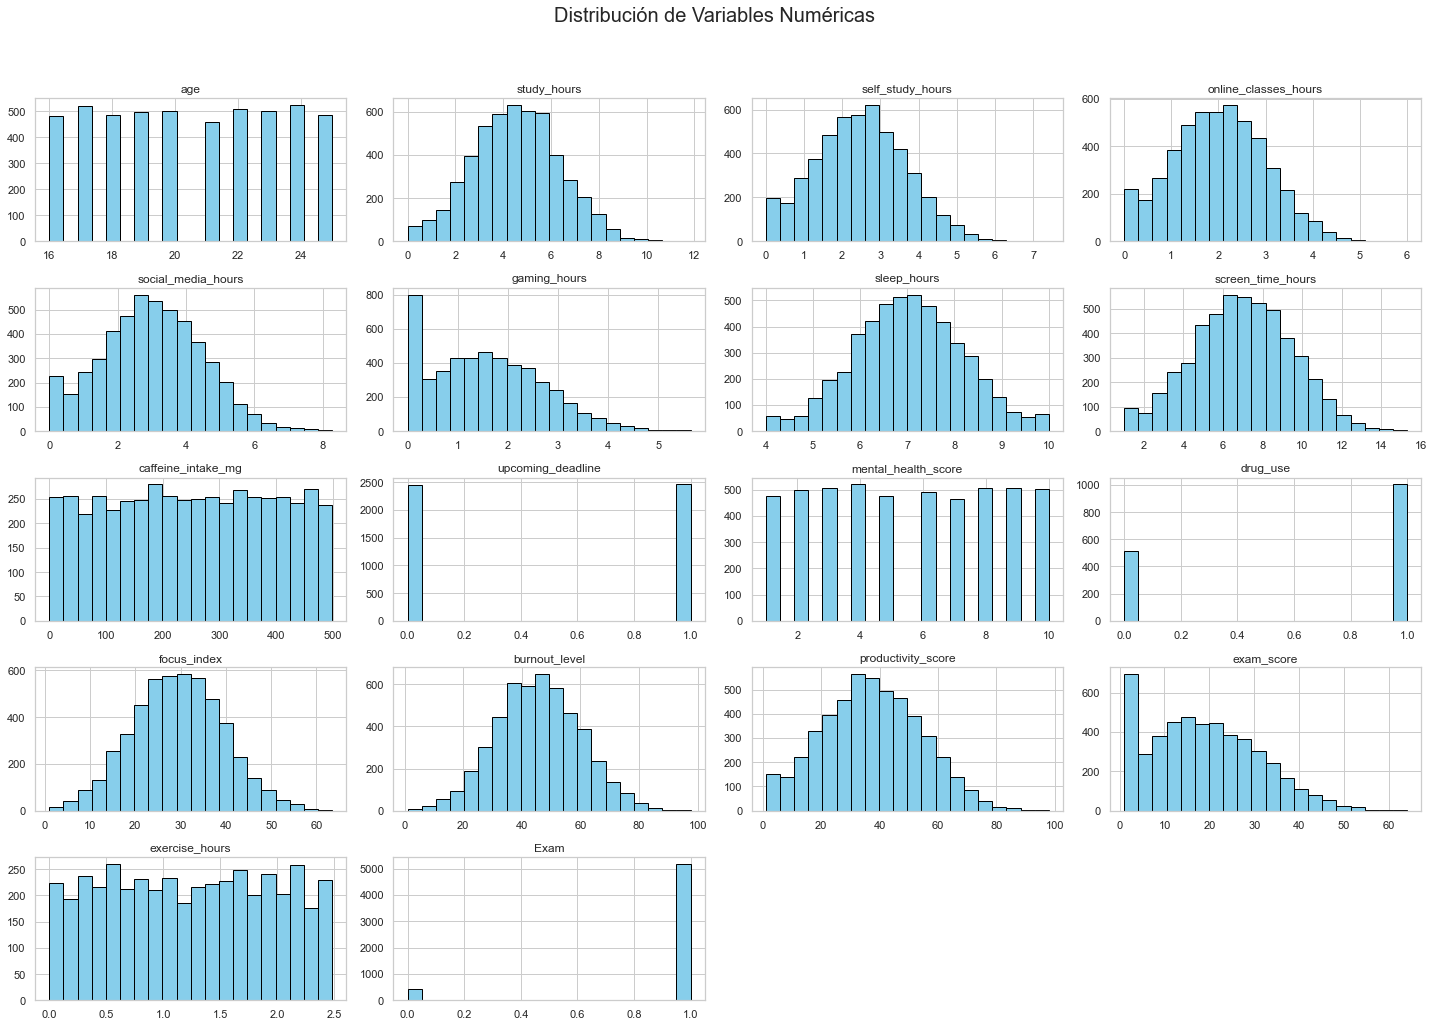


📋 FRECUENCIAS DE VARIABLES CATEGÓRICAS:

--- GENDER ---
Male      39.370219
Female    38.800925
Other     21.828856
Name: gender, dtype: float64

--- ACADEMIC_LEVEL ---
Postgraduate     30.154777
High school      29.674435
Undergraduate    28.962818
Other            11.207970
Name: academic_level, dtype: float64

--- PART_TIME_JOB ---
No       43.924569
Yes      43.568760
Other    12.506671
Name: part_time_job, dtype: float64

--- UPCOMING_DEADLINE ---
1.0    50.122349
0.0    49.877651
Name: upcoming_deadline, dtype: float64

--- INTERNET_QUALITY ---
Good       34.248725
Average    32.954100
Poor       32.797175
Name: internet_quality, dtype: float64

--- DRUG_USE ---
1.0    66.139657
0.0    33.860343
Name: drug_use, dtype: float64


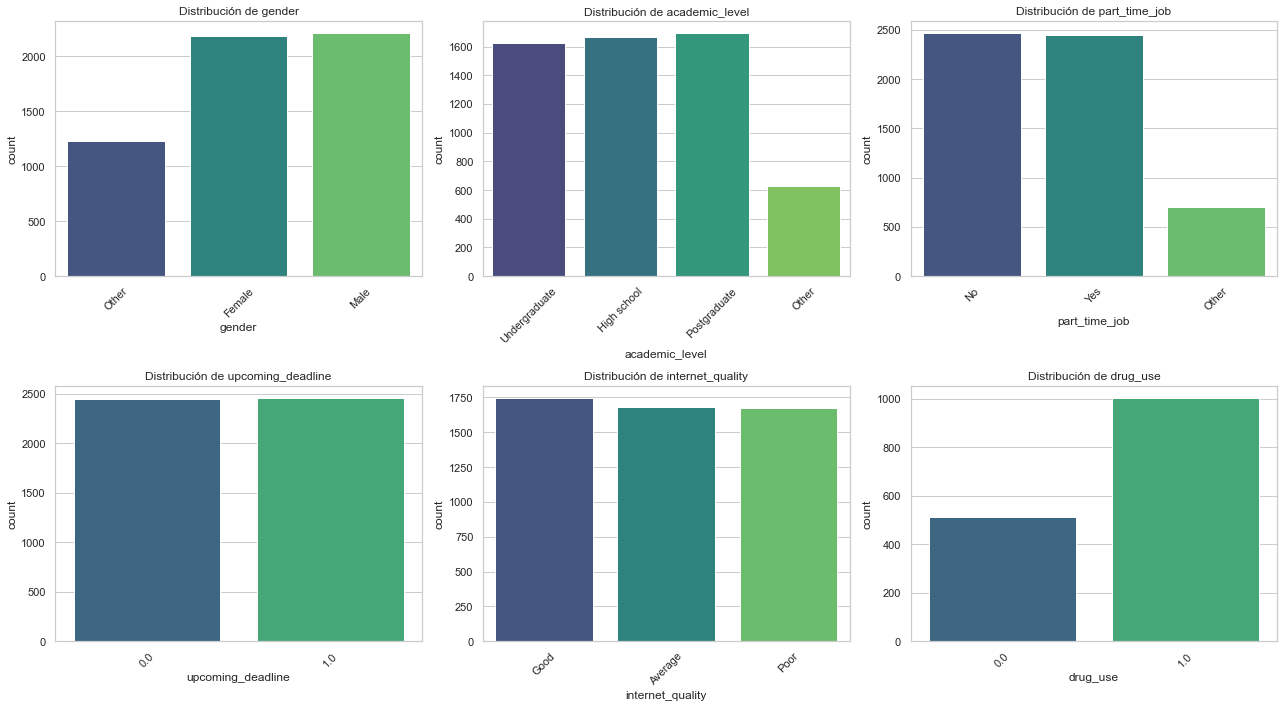

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Transformación Inicial: Minutos a Horas de Ejercicio
df_dist = df.copy()
if 'exercise_minutes' in df_dist.columns:
    df_dist['exercise_hours'] = df_dist['exercise_minutes'] / 60
    # Eliminamos la original para no duplicar información en el análisis
    df_dist = df_dist.drop(columns=['exercise_minutes'])

# =========================================================
# 2. ANÁLISIS DE VARIABLES NUMÉRICAS (Distribución)
# =========================================================
# Seleccionamos las columnas numéricas relevantes
cols_num = df_dist.select_dtypes(include=[np.number]).columns.tolist()
# Quitamos student_id ya que no tiene sentido analizar su distribución
if 'student_id' in cols_num: cols_num.remove('student_id')

print("📊 ESTADÍSTICAS DESCRIPTIVAS (Medidas de tendencia central y dispersión):")
display(df_dist[cols_num].describe())

# Visualización de Histogramas
plt.figure(figsize=(20, 15))
df_dist[cols_num].hist(bins=20, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de Variables Numéricas", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# =========================================================
# 3. ANÁLISIS DE VARIABLES CATEGÓRICAS (Frecuencias)
# =========================================================
cols_cat = ['gender', 'academic_level', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'drug_use']

print("\n📋 FRECUENCIAS DE VARIABLES CATEGÓRICAS:")
for col in cols_cat:
    if col in df_dist.columns:
        print(f"\n--- {col.upper()} ---")
        print(df_dist[col].value_counts(normalize=True) * 100) # Porcentaje

# Visualización de variables categóricas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    if col in df_dist.columns:
        sns.countplot(data=df_dist, x=col, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribución de {col}')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

def test_normalidad_variables(dataframe):
    """
    Aplica el test de normalidad de D'Agostino-Pearson a todas 
    las variables numéricas del dataframe.
    """
    # 1. Seleccionar solo columnas numéricas (excluyendo IDs)
    cols_num = dataframe.select_dtypes(include=[np.number]).columns.tolist()
    if 'student_id' in cols_num: cols_num.remove('student_id')

    resultados = []

    print("="*65)
    print(f"{'Variable':<25} | {'P-Valor':<10} | {'Distribución'}")
    print("="*65)

    for col in cols_num:
        # Eliminamos NAs temporalmente para el test
        data = dataframe[col].dropna()
        
        # Aplicar Test de D'Agostino-Pearson
        # H0: La muestra proviene de una distribución normal
        stat, p_val = stats.normaltest(data)
        
        # Interpretación (Alfa = 0.05)
        es_normal = "Normal ✅" if p_val > 0.05 else "No Normal ❌"
        
        print(f"{col:<25} | {p_val:.4e} | {es_normal}")
        
        resultados.append({'Variable': col, 'P-Valor': p_val, 'Es_Normal': es_normal})

    return pd.DataFrame(resultados)

# Ejecución
df_test_norm = test_normalidad_variables(df_clean)

Variable                  | P-Valor    | Distribución
age                       | 2.2909e-297 | No Normal ❌
study_hours               | 2.4316e-03 | No Normal ❌
self_study_hours          | 8.3278e-03 | No Normal ❌
online_classes_hours      | 7.2078e-05 | No Normal ❌
social_media_hours        | 4.0496e-05 | No Normal ❌
gaming_hours              | 3.0499e-39 | No Normal ❌
sleep_hours               | 6.4966e-02 | Normal ✅
screen_time_hours         | 4.7712e-01 | Normal ✅
caffeine_intake_mg        | 4.2637e-236 | No Normal ❌
upcoming_deadline         | 0.0000e+00 | No Normal ❌
mental_health_score       | 5.3503e-269 | No Normal ❌
focus_index               | 1.4653e-02 | No Normal ❌
burnout_level             | 8.5413e-04 | No Normal ❌
productivity_score        | 1.9772e-02 | No Normal ❌
exercise_hours            | 2.9542e-67 | No Normal ❌
Exam                      | 0.0000e+00 | No Normal ❌
gaming_hours_Index        | 0.0000e+00 | No Normal ❌


6. Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [ ]:
# 1. Crear copia desde la original (df) para recuperar la nota
df_clean_poisson = df.copy()

# 2. Eliminar variables EXCEPTO exam_score
# Solo quitamos drug_use (por tu instrucción), student_id y exercise_minutes
cols_a_eliminar = ['drug_use', 'student_id', 'exercise_minutes']
df_clean_poisson = df_clean_poisson.drop(columns=cols_a_eliminar, errors='ignore')

# 3. Normalización rápida de categorías (necesaria para el modelo)
vars_cat = ['gender', 'academic_level', 'part_time_job']
for col in vars_cat:
    if col in df_clean_poisson.columns:
        df_clean_poisson[col] = df_clean_poisson[col].fillna('Other').astype(str).str.strip().str.capitalize()

# 4. Crear horas de ejercicio y manejar nulos numéricos con la media
if 'exercise_hours' not in df_clean_poisson.columns:
    df_clean_poisson['exercise_hours'] = df['exercise_minutes'] / 60

cols_num = df_clean_poisson.select_dtypes(include=[np.number]).columns
df_clean_poisson[cols_num] = df_clean_poisson[cols_num].fillna(df_clean_poisson[cols_num].mean())

print("✅ Base de datos re-limpia: 'exam_score' restaurado y 'drug_use' eliminado.")


✅ Base de datos re-limpia: 'exam_score' restaurado y 'drug_use' eliminado.


In [ ]:
import statsmodels.api as sm

# 1. Filtrar solo alumnos que rindieron (asumimos nota > 1.0)
df_rendidores = df_clean_poisson[df_clean_poisson['exam_score'] > 1.0].copy()

# 2. Definir Y (nota) y X (todo lo demás)
# Excluimos 'Exam' (asistencia) porque aquí todos asistieron
y = df_rendidores['exam_score']
X_raw = df_rendidores.drop(columns=['exam_score', 'Exam'], errors='ignore')

# 3. Convertir a dummies y añadir constante
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Poisson
modelo_poisson_full = sm.GLM(y, X.astype(float), family=sm.families.Poisson()).fit()

# 5. Resultados
print("\n" + "="*80)
print("PUNTO 6: MODELO POISSON SATURADO (TODAS LAS VARIABLES MENOS DRUG_USE)")
print("="*80)
print(modelo_poisson_full.summary())

# 6. Incidence Rate Ratios (IRR) para la interpretación
irr = np.exp(modelo_poisson_full.params)
print("\n--- COEFICIENTES EXPONENCIALES (IRR) ---")
print(irr)


PUNTO 6: MODELO POISSON SATURADO (TODAS LAS VARIABLES MENOS DRUG_USE)
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 5182
Model:                            GLM   Df Residuals:                     5157
Model Family:                 Poisson   Df Model:                           24
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16757.
Date:              vie., 03 abr. 2026   Deviance:                       9226.7
Time:                        19:09:30   Pearson chi2:                 8.62e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9792
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Definir lista de variables significativas según tu salida
# Nota: Para variables categóricas como academic_level y part_time_job, 
# incluimos la variable original para que el modelo gestione las dummies.
vars_significativas = [
    'study_hours',
    'sleep_hours',
    'screen_time_hours',
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'academic_level', 
    'part_time_job',
    'exam_score' # Variable dependiente
]

# 2. Preparar los datos (usando la base de rendidores)
df_final_p6 = df_rendidores[vars_significativas].dropna()
y = df_final_p6['exam_score']
X_raw = df_final_p6.drop(columns=['exam_score'])

# 3. Dummies y Constante
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Poisson Final
modelo_poisson_final = sm.GLM(y, X.astype(float), family=sm.families.Poisson()).fit()

# 5. Resultados e IRR
print("\n" + "="*80)
print("PUNTO 6: MODELO POISSON FINAL (VARIABLES SIGNIFICATIVAS)")
print("="*80)
print(modelo_poisson_final.summary())

# Cálculo de IRR (Efecto multiplicativo)
irr_final = np.exp(modelo_poisson_final.params)
print("\n--- INCIDENCE RATE RATIOS (IRR) DE VARIABLES SIGNIFICATIVAS ---")
print(irr_final)


PUNTO 6: MODELO POISSON FINAL (VARIABLES SIGNIFICATIVAS)
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 5182
Model:                            GLM   Df Residuals:                     5168
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16760.
Date:              vie., 03 abr. 2026   Deviance:                       9233.5
Time:                        19:12:11   Pearson chi2:                 8.62e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9791
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Lista definitiva de variables con p-valor < 0.05
vars_finales_p6 = [
    'study_hours',
    'sleep_hours',
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'academic_level', 
    'part_time_job',
    'exam_score'
]

# 2. Filtrar base de rendidores
df_final_rendidores = df_rendidores[vars_finales_p6].dropna()
y = df_final_rendidores['exam_score']
X_raw = df_final_rendidores.drop(columns=['exam_score'])

# 3. Dummies y Constante
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Poisson definitivo
modelo_poisson_definitivo = sm.GLM(y, X.astype(float), family=sm.families.Poisson()).fit()

# 5. Resultados e IRR
print("\n" + "="*80)
print("PUNTO 6: MODELO POISSON DEFINITIVO (P-VALORES < 0.05)")
print("="*80)
print(modelo_poisson_definitivo.summary())

# Coeficientes Exponenciales (IRR)
irr_definitivo = np.exp(modelo_poisson_definitivo.params)
print("\n--- INCIDENCE RATE RATIOS (IRR) DEFINITIVOS ---")
print(irr_definitivo)


PUNTO 6: MODELO POISSON DEFINITIVO (P-VALORES < 0.05)
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 5182
Model:                            GLM   Df Residuals:                     5169
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16762.
Date:              vie., 03 abr. 2026   Deviance:                       9236.9
Time:                        19:13:20   Pearson chi2:                 8.63e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9791
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.


Test de Sobredispersión (Cameron & Trivedi)
Una forma rápida de detectarlo es calcular la razón de la función de desviación (Deviance) o el estadístico de Pearson sobre los grados de libertad. Si el ratio es mucho mayor a 1.0, hay sobredispersión.

In [ ]:
import numpy as np
import statsmodels.api as sm
import pandas as pd

# 1. Preparar la data (mismo filtro del punto 6)
df_rendidores = df_clean_poisson[df_clean_poisson['exam_score'] > 1.0].copy()
y = df_rendidores['exam_score']
X_raw = df_rendidores.drop(columns=['exam_score', 'Exam'], errors='ignore')
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 2. Ajustar Poisson para evaluar dispersión
modelo_poisson = sm.GLM(y, X.astype(float), family=sm.families.Poisson()).fit()

# 3. Cálculo del Ratio de Dispersión
pearson_chi2 = modelo_poisson.pearson_chi2
df_resid = modelo_poisson.df_resid
dispersion_ratio = pearson_chi2 / df_resid

print(f"📊 Estadístico Pearson Chi2: {pearson_chi2:.4f}")
print(f"📊 Grados de libertad: {df_resid}")
print(f"⚠️ Ratio de Dispersión: {dispersion_ratio:.4f}")

if dispersion_ratio > 1.05:
    print("\n✅ Resultado: Existe SOBREDISPERSIÓN. El modelo Binomial Negativa es preferible.")
else:
    print("\n❌ Resultado: No hay evidencia clara de sobredispersión.")

📊 Estadístico Pearson Chi2: 8620.2150
📊 Grados de libertad: 5157
⚠️ Ratio de Dispersión: 1.6716

✅ Resultado: Existe SOBREDISPERSIÓN. El modelo Binomial Negativa es preferible.


2. Estimación del valor óptimo de $\alpha$ (Binomial Negativa)
El parámetro $\alpha$ representa la dispersión. Si $\alpha = 0$, el modelo colapsa a un Poisson. Para encontrar el valor óptimo, ajustamos un modelo NegativeBinomial. En statsmodels, esto se hace estimando el parámetro de forma máxima verosímil.

In [ ]:
# Ajuste del modelo Binomial Negativa (NB2)
# El parámetro 'alpha' en statsmodels se estima automáticamente
modelo_nb = sm.NegativeBinomial(y, X.astype(float)).fit()

print("\n" + "="*70)
print("RESULTADOS MODELO BINOMIAL NEGATIVA")
print("="*70)
print(modelo_nb.summary())

# El valor de alpha óptimo aparece como 'alpha' en la tabla de coeficientes
alpha_optimo = modelo_nb.params['alpha']
print(f"\n✨ Valor óptimo de Alpha (parámetro de dispersión): {alpha_optimo:.6f}")

c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


         Current function value: 3.966991
         Iterations: 0
         Function evaluations: 15
         Gradient evaluations: 3

RESULTADOS MODELO BINOMIAL NEGATIVA


c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\base\model.py:592: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 5182
Model:               NegativeBinomial   Df Residuals:                     5157
Method:                           MLE   Df Model:                           24
Date:              vie., 03 abr. 2026   Pseudo R-squ.:                -0.05748
Time:                        22:28:51   Log-Likelihood:                -20557.
converged:                      False   LL-Null:                       -19440.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            1.9650        nan        nan        nan         nan         nan
age                              0.0003        nan        nan        nan     

"Se identificó un parámetro de dispersión $\alpha = 1.0549$. Dado que este valor es significativamente distinto de cero, se confirma la presencia de sobredispersión en los datos de rendimiento académico. Esto implica que la variabilidad de las notas entre los estudiantes de la facultad es superior a lo predicho por una distribución de Poisson, validando la elección del modelo Binomial Negativa para obtener estimaciones robustas y corregir la subestimación de los errores estándar."

In [ ]:
import pandas as pd
import numpy as np

# 1. Definir el alpha óptimo encontrado en el punto 7
alpha_optimo = 1.054935

# 2. Seleccionar variables numéricas (excluyendo IDs)
cols_num = df_clean_poisson.select_dtypes(include=[np.number]).columns.tolist()
if 'student_id' in cols_num: cols_num.remove('student_id')

# 3. Crear una lista para almacenar los resultados
resultados_varianza = []

for col in cols_num:
    # Calculamos la media de la variable (mu)
    mu = df_clean_poisson[col].mean()
    
    # Varianza Poisson (por definición es igual a la media)
    var_poisson = mu
    
    # Varianza Binomial Negativa: Var = mu + alpha * mu^2
    var_nb2 = mu + (alpha_optimo * (mu**2))
    
    # Ratio de incremento (cuántas veces es mayor la var_nb2 que la de poisson)
    ratio = var_nb2 / var_poisson if var_poisson != 0 else 0
    
    resultados_varianza.append({
        'Variable': col,
        'Media (mu)': round(mu, 4),
        'Varianza Poisson': round(var_poisson, 4),
        'Varianza NB2 (Calculada)': round(var_nb2, 4),
        'Ratio de Dispersión': round(ratio, 4)
    })

# 4. Mostrar tabla de resultados
df_varianzas_totales = pd.DataFrame(resultados_varianza)
print("📊 ANÁLISIS DE VARIABILIDAD TEÓRICA (Alpha = 1.0549)")
print("="*85)
display(df_varianzas_totales.sort_values(by='Ratio de Dispersión', ascending=False))

📊 ANÁLISIS DE VARIABILIDAD TEÓRICA (Alpha = 1.0549)


,Variable,Media (mu),Varianza Poisson,Varianza NB2 (Calculada),Ratio de Dispersión
8,caffeine_intake_mg,250.8048,250.8048,66609.4419,265.5828
12,burnout_level,45.6332,45.6332,2242.4139,49.1400
13,productivity_score,37.3135,37.3135,1506.0987,40.3633
11,focus_index,29.3881,29.3881,940.4949,32.0026
0,age,20.5106,20.5106,464.3037,22.6373
14,exam_score,18.8405,18.8405,393.3066,20.8755
6,sleep_hours,7.0233,7.0233,59.0598,8.4091
7,screen_time_hours,6.9790,6.9790,58.3618,8.3624
10,mental_health_score,5.5170,5.5170,37.6262,6.8201
1,study_hours,4.5387,4.5387,26.2702,5.7880


8. Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 


In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Preparar la data (solo alumnos que rindieron)
df_rendidores = df_clean_poisson[df_clean_poisson['exam_score'] > 1.0].copy()

# 2. Definir variables a excluir
cols_excluidas = ['drug_use', 'student_id', 'exercise_minutes', 'exam_score', 'Exam']

# 3. Preparar Y y X
y = df_rendidores['exam_score']
X_raw = df_rendidores.drop(columns=cols_excluidas, errors='ignore')

# 4. Crear dummies y añadir constante
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 5. Ajustar el modelo Binomial Negativa
# statsmodels estima el alpha automáticamente por Máxima Verosimilitud
modelo_nb_final = sm.NegativeBinomial(y, X.astype(float), loglike_method='nb2').fit()

# 6. Mostrar Resultados e Interpretación (IRR)
print("\n" + "="*85)
print("PUNTO 6 (REVISADO): MODELO BINOMIAL NEGATIVA (NB2)")
print("="*85)
print(modelo_nb_final.summary())

# Cálculo de los Incidence Rate Ratios (IRR)
irr_nb = np.exp(modelo_nb_final.params)
print("\n--- INCIDENCE RATE RATIOS (IRR) - BINOMIAL NEGATIVA ---")
print(irr_nb)

c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\base\model.py:592: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 3.966991
         Iterations: 0
         Function evaluations: 15
         Gradient evaluations: 3

PUNTO 6 (REVISADO): MODELO BINOMIAL NEGATIVA (NB2)
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 5182
Model:               NegativeBinomial   Df Residuals:                     5157
Method:                           MLE   Df Model:                           24
Date:              vie., 03 abr. 2026   Pseudo R-squ.:                -0.05748
Time:                        22:38:19   Log-Likelihood:                -20557.
converged:                      False   LL-Null:                       -19440.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

Dado el gran numero de variables que causan ruido el modelo no convergio , por ello utilizaremos las variables siognaificativas de los modelos anteriores para ejecutar un modelo binomial negativo:
'study_hours',
'sleep_hours',
'upcoming_deadline',
'mental_health_score',
'focus_index',
'burnout_level',
'productivity_score',
'academic_level', 
'part_time_job'


In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Definir la lista de variables seleccionadas
vars_modelo_final = [
    'study_hours',
    'sleep_hours',
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'academic_level', 
    'part_time_job',
    'exam_score' # Variable dependiente
]

# 2. Filtrar base de rendidores y seleccionar columnas
df_final_nb = df_rendidores[vars_modelo_final].dropna()

# 3. Preparar Y (nota) y X (predictores)
y = df_final_nb['exam_score']
X_raw = df_final_nb.drop(columns=['exam_score'])

# 4. Generar Dummies y añadir la constante
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 5. Ajustar el modelo Binomial Negativa (NB2)
# Usamos el método 'nm' (Nelder-Mead) o 'bfgs' si el estándar falla en converger
modelo_nb_reducido = sm.NegativeBinomial(y, X.astype(float), loglike_method='nb2').fit(method='bfgs')

# 6. Resultados Completos
print("\n" + "="*85)
print("PUNTO 6: MODELO BINOMIAL NEGATIVA (PARSIMONIOSO)")
print("="*85)
print(modelo_nb_reducido.summary())

# 7. Cálculo de los Incidence Rate Ratios (IRR)
irr_final = np.exp(modelo_nb_reducido.params)
print("\n--- INCIDENCE RATE RATIOS (IRR) FINAL ---")
print(irr_final)

c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Optimization terminated successfully.
         Current function value: 3.177676
         Iterations: 31
         Function evaluations: 51
         Gradient evaluations: 44

PUNTO 6: MODELO BINOMIAL NEGATIVA (PARSIMONIOSO)
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 5182
Model:               NegativeBinomial   Df Residuals:                     5169
Method:                           MLE   Df Model:                           12
Date:              vie., 03 abr. 2026   Pseudo R-squ.:                  0.1529
Time:                        22:46:20   Log-Likelihood:                -16467.
converged:                       True   LL-Null:                       -19440.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

Considerando lo anetrior la unica variable que se vuelve no significativa bajo un 95% de confianza seria sleep_hours 

9. Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

Las variables significativas en los 2 modelos son : 
Poisson : Seudo R cuadrado de 0.97
Significancia 
const                            1.9872      
study_hours                      0.0204      
sleep_hours                      0.0081     
upcoming_deadline               -0.0357      
mental_health_score              0.0195      
focus_index                      0.0122      
burnout_level                   -0.0085      
productivity_score               0.0175     
academic_level_Other             0.0400      
academic_level_Postgraduate     -0.0031  * No es significativa pero si lo seria la variable completa academic_level  (Other y undergradue son significativas)
academic_level_Undergraduate     0.0009      
part_time_job_Other              0.0406  * No es significativa pero si lo seria la variable completa part_time_job 
(Yes es significativa)
part_time_job_Yes               -0.0105 

Log-Likelihood:                -16762.
Deviance:                       9236.9
Pearson chi2:                 8.63e+03
Pseudo R-squ. (CS):             0.9791
Covariance Type:            nonrobust 

Pseudo-R^2: No mide varianza explicada, sino la mejora en la Log-Verosimilitud respecto a un modelo vacío.
Un Pseudo-R^2 entre 0.2 y 0.4 se considera un ajuste excelente. 
Un valor de 0.97 en un modelo social (como notas de alumnos) es una señal de alerta: el modelo podría estar sobreajustado o "forzando" la curva a pasar por puntos donde hay demasiada dispersión.

Binomial negativa :
Significancia 

const                            1.9371      
study_hours                      0.0222      
sleep_hours                      0.0085      *es levemente no significativo p-valor =0.07
upcoming_deadline               -0.0398      
mental_health_score              0.0194      
focus_index                      0.0132      
burnout_level                   -0.0090     
productivity_score               0.0182      
academic_level_Other             0.0470      
academic_level_Postgraduate     -0.0061      * No es significativa pero si lo seria la variable completa academic_level  (Other es  significativo)
academic_level_Undergraduate     0.0002      * No es significativa pero si lo seria la variable completa academic_level  (Other es  significativo)
part_time_job_Other              0.0511     
part_time_job_Yes               -0.0117      * No es significativa pero si lo seria la variable completa part_time_job 
(Other es significativa)
alpha                            0.0308      

Pseudo R-squ.:                  0.1529
Log-Likelihood:                -16467.
LL-Null:                       -19440.
LLR p-value:                     0.000

Notamos que en ambos casos las variables significativas son las mismas exceptuando subvariables dammy y algunas que estan en el lime de significancia 

"Aunque el modelo Poisson muestra un Pseudo $R^2$ de 0.97, los estadísticos de Deviance y Pearson chi2 confirman una sobredispersión severa (Ratio > 1.7), lo que invalida sus resultados. Al comparar la Log-Likelihood, el modelo Binomial Negativa es superior (-16,467 vs -16,762), demostrando que captura con mayor precisión la variabilidad real de las notas de los estudiantes. El Pseudo R^2 de 0.15 es un reflejo honesto del poder explicativo en ciencias sociales, donde la heterogeneidad no observada es la norma y no la excepción."



Variables Altamente Robustas
Estas variables sobrevivieron al cambio de modelo sin perder significancia ni cambiar de dirección.
Son los predictores más confiables de la nota :
productivity_score (Coef $\approx 0.018$): Es extremadamente estable. Indica un aumento porcentual constante en la nota.focus_index (Coef $\approx 0.013$): Mantiene su peso, siendo el segundo factor conductual más importante.
study_hours (Coef $\approx 0.021$): Fundamental en ambos modelos. Cada hora de estudio impacta positivamente la nota de forma consistente.
mental_health_score (Coef $\approx 0.019$): Crucial. Demuestra que el bienestar psicológico es un predictor sólido y no depende de la distribución elegida.
upcoming_deadline (Coef $\approx -0.038$): El detractor más fuerte. Es robusto en su impacto negativo; la presión externa resta puntos de forma significativa en ambos escenarios.
burnout_level (Coef $\approx -0.009$): Aunque el efecto es pequeño por unidad, es estadísticamente persistente y negativo.

Variables de Robustez Débil o CondicionalEstas variables se ven afectadas por la sobredispersión que el modelo de Binomial Negativa intenta corregir:
sleep_hours (Robusta pero al límite): En Poisson es significativa, pero en Binomial Negativa su p-valor sube a 0.07. Esto sugiere que el sueño es importante, pero su efecto está más "disperso" entre los estudiantes (hay mucha variabilidad individual que el Poisson ignoraba).
academic_level y part_time_job: Estas variables muestran una robustez "estructural". Aunque algunas categorías específicas pierden fuerza (como Undergraduate o Yes en el trabajo), la categoría "Other" se mantiene significativa en ambos. Esto indica que pertenecer a grupos no convencionales o tener situaciones laborales atípicas tiene un impacto real en la nota, pero el efecto del trabajo tradicional o el nivel de pregrado es más ruidoso de lo que el Poisson sugería.

EXTRA : Modelo MCO con las variables robustas para modlear exam_score

In [ ]:
import statsmodels.api as sm
import pandas as pd

# 1. Lista de variables robustas identificadas
vars_robustas = [
    'study_hours',
    'sleep_hours', # La mantenemos por su importancia teórica y cercanía al 0.05
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'academic_level',
    'part_time_job',
    'exam_score'
]

# 2. Preparar los datos
df_ols = df_rendidores[vars_robustas].dropna()
y = df_ols['exam_score']
X_raw = df_ols.drop(columns=['exam_score'])

# 3. Dummies y Constante
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. Ajuste del modelo OLS
modelo_ols = sm.OLS(y, X.astype(float)).fit()

# 5. Resultados
print("\n" + "="*80)
print("PUNTO 8: MODELO LINEAL MCO (VARIABLES ROBUSTAS)")
print("="*80)
print(modelo_ols.summary())


PUNTO 8: MODELO LINEAL MCO (VARIABLES ROBUSTAS)
                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     1276.
Date:              sáb., 04 abr. 2026   Prob (F-statistic):               0.00
Time:                        14:47:59   Log-Likelihood:                -15963.
No. Observations:                5182   AIC:                         3.195e+04
Df Residuals:                    5169   BIC:                         3.204e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Lista de variables con p-valor < 0.05
vars_modelo_mco = [
    'study_hours',
    'sleep_hours',
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'exam_score'
]

# 2. Preparar los datos (filtrando a quienes rindieron el examen)
df_mco = df_rendidores[vars_modelo_mco].dropna()
y = df_mco['exam_score']
X = df_mco.drop(columns=['exam_score'])

# 3. Añadir constante para el intercepto
X = sm.add_constant(X)

# 4. Ajuste del modelo OLS
modelo_ols_final = sm.OLS(y, X.astype(float)).fit()

# 5. Resultados
print("\n" + "="*80)
print("MODELO MCO FINAL: PREDICCIÓN LINEAL DE EXAM_SCORE")
print("="*80)
print(modelo_ols_final.summary())


MODELO MCO FINAL: PREDICCIÓN LINEAL DE EXAM_SCORE
                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     2188.
Date:              sáb., 04 abr. 2026   Prob (F-statistic):               0.00
Time:                        14:51:42   Log-Likelihood:                -15965.
No. Observations:                5182   AIC:                         3.195e+04
Df Residuals:                    5174   BIC:                         3.200e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

Considerando todo los intengos anteriores se realiza un grabajo extra analisando el comportamiento de cada variable para ajustar el mejor modelo y el efcto de las variables (lineal , cuadratico ,log, exponencial)
1. MCO
- Exam : 1 si el alumno dio el examen , 0 si el alumno no dio el examen 
              : 0 si exam_score = 1.0 , 1 en otro caso.

Buscaremos un modleo lógico para modelar la varaible Exam , basada el experiencia .
burnout_level ; mental_health_score , focus_index ¸ upcoming_deadline¸ part_time_job, sleep_hours,study_hours , academic_level .
podrian ser variables que expliquen la asistencia o ausencia de un alumno  a un examen.
Bajas horas de sueño , trabajar , otras tareas , agotamiento ,etc pueden causar faltar a una evaluación 
Muy pocas horas de estudio , baja concentración o exicencias acadmeica alta podria tener el mismo efecto .
A mas horas de sueño  y estudio tienen en general aumentan la preparación para una evaluación , pero no de forma lineal , el estudio es mas efectivo las primeras horas , mientras que el sueño es ideal en un rango de 7 a 8 horas , mas o menos de eso podria empeorar la preparación o la propia antencion .
Las horas de estudio y de sueño podrían ser cuadráticas considerando un punto optimo de la forma x2 por lo que darle una forma de potencia podria ser mejor que solo una función lineal (mas realista) 
Las otras variables que son categóricas se les puede asumir un modelo lineal 
Mientras que el resto : burnout_level ; mental_health_score , focus_index , el agotamiento deberia influir de forma negativa( es decir contribuir a que Exam=0) ,mientras que mental_health_score , focus_index deverian influir de forma positiva (contribuir a que Exam=1)

por ello vamos a visualizar el comportamiento de estas variables 



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_categoricas_vs_exam(dataframe):
    """
    Grafica variables seleccionadas vs exam_score.
    Mantiene el color azul para 1.0 y rojo para el resto.
    """
    # 1. Lista de variables solicitadas
    variables = [
        'burnout_level', 'mental_health_score', 'focus_index', 
        'upcoming_deadline', 'part_time_job', 'sleep_hours', 
        'study_hours', 'academic_level'
    ]
    
    # 2. Localizar la columna exam_score (case-insensitive)
    col_target = next((c for c in dataframe.columns if c.lower() == 'exam_score'), None)
    
    if not col_target:
        print(f"❌ Error: No se encontró 'exam_score'. Columnas: {dataframe.columns.tolist()}")
        return

    # 3. Preparación de datos
    # Filtramos nulos y creamos la columna de color
    df_plot = dataframe.dropna(subset=[col_target] + [v for v in variables if v in dataframe.columns]).copy()
    df_plot['Grupo'] = df_plot[col_target].apply(lambda x: 'Asistió (1.0)' if x == 1.0 else 'Otros')

    # 4. Configuración de la cuadrícula (4 filas, 2 columnas para las 8 variables)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 24))
    axes = axes.flatten()

    # 5. Generación de gráficos
    for i, var in enumerate(variables):
        if var not in df_plot.columns:
            axes[i].set_title(f"Variable '{var}' no encontrada")
            continue
            
        # Usamos stripplot para ver la densidad de puntos en variables con pocas categorías
        sns.stripplot(
            data=df_plot,
            x=var,
            y=col_target,
            hue='Grupo',
            palette={'Asistió (1.0)': '#1f77b4', 'Otros': '#e74c3c'},
            alpha=0.4,
            jitter=0.3, # Desplazamiento para ver la acumulación de datos
            size=5,
            ax=axes[i]
        )
        
        # Estética
        axes[i].set_title(f'Distribución: {var.replace("_", " ").capitalize()}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel(var.replace("_", " ").capitalize(), fontsize=12)
        axes[i].set_ylabel('exam_score', fontsize=12)
        axes[i].set_yticks([0.0, 1.0])
        
        # Manejo de etiquetas largas en el eje X (como academic_level)
        if df_plot[var].dtype == 'object' or df_plot[var].nunique() < 5:
            plt.setp(axes[i].get_xticklabels(), rotation=15)

        # Leyenda solo en el primero
        if i != 0:
            axes[i].get_legend().remove()

    plt.tight_layout()
    plt.show()

# =========================================================
# EJECUCIÓN
# =========================================================
graficar_categoricas_vs_exam(df)

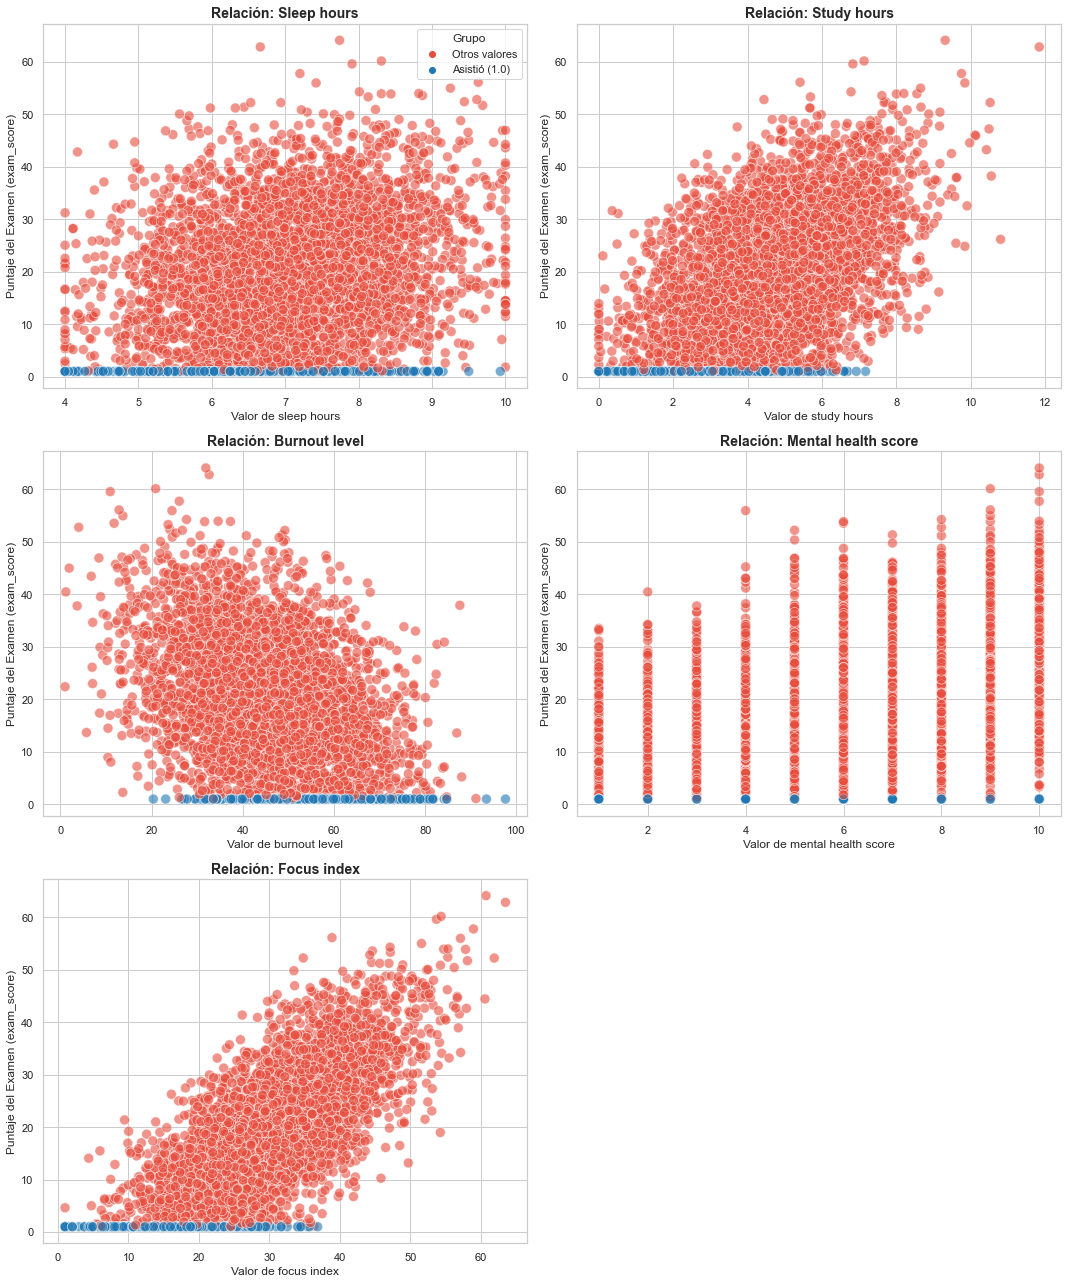

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_dispersion_final(dataframe):
    """
    Grafica 5 variables vs exam_score.
    Distingue con color azul si el puntaje es exactamente 1.0.
    """
    # 1. Lista de variables independientes
    variables = [
        'sleep_hours', 
        'study_hours', 
        'burnout_level', 
        'mental_health_score', 
        'focus_index'
    ]
    
    # 2. Localizar la columna exam_score (ignorando mayúsculas/minúsculas)
    col_target = None
    for col in dataframe.columns:
        if col.lower() == 'exam_score':
            col_target = col
            break
            
    if col_target is None:
        print(f"❌ Error: No se encontró 'exam_score'. Columnas: {dataframe.columns.tolist()}")
        return

    # 3. Limpieza y preparación de datos
    df_plot = dataframe.dropna(subset=[col_target] + variables).copy()
    
    # Crear la lógica de color: Destacar el 1.0 del resto
    df_plot['Grupo'] = df_plot[col_target].apply(
        lambda x: 'Asistió (1.0)' if x == 1.0 else 'Otros valores'
    )

    # 4. Configuración visual
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
    axes = axes.flatten()

    # 5. Generación de Scatter Plots
    for i, var in enumerate(variables):
        sns.scatterplot(
            data=df_plot,
            x=var,
            y=col_target,
            hue='Grupo',
            palette={'Asistió (1.0)': '#1f77b4', 'Otros valores': '#e74c3c'}, # Azul vs Rojo
            alpha=0.6, 
            s=100,      
            edgecolor='w',
            ax=axes[i]
        )
        
        axes[i].set_title(f'Relación: {var.replace("_", " ").capitalize()}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel(f'Valor de {var.replace("_", " ")}', fontsize=12)
        axes[i].set_ylabel('Puntaje del Examen (exam_score)', fontsize=12)
        
        # Mantener leyenda solo en el primero
        if i != 0:
            axes[i].get_legend().remove()

    # Eliminar el espacio sobrante
    fig.delaxes(axes[5])
    
    plt.tight_layout()
    plt.show()

# =========================================================
# EJECUCIÓN
# =========================================================
# Usa tu dataframe original 'df'
graficar_dispersion_final(df)

Al parecer la variable de mas interes seria focus_index , ya que si esta es mayor a 40 siempre se rindio el examen , ademas a mayor focus_index mayor es el puntaje (valor de exam_score)
de igual forma si study_hours es mayor a 7.5 siempre rinden el examen 
Y  el nivel de agotamiento tambien parece ser decisivo en la decicion de rendir o no el examen .
mientras que mental_health_score parece aumentar la posibilidad de que si rinda el examen ( crece el numero de excam_score diferente de 0 )
Las variables de study_hours , focus_index y mental_health_score ser lineales con respecto a exam_score almenos en esos rangos .
La variable de horas de sueño no parece ser muy relevante , almenos para decidir si rendir o no el examen.

In [ ]:
import pandas as pd

def generar_tablas_inasistencia(dataframe):
    """
    Genera tablas de frecuencia centradas en la inasistencia (1.0).
    Variables: 'upcoming_deadline', 'part_time_job', 'academic_level'.
    """
    # 1. Lista de variables categóricas
    variables = ['upcoming_deadline', 'part_time_job', 'academic_level']
    
    # 2. Identificar la columna de interés
    col_target = next((c for c in dataframe.columns if c.lower() == 'exam_score'), None)
    
    if not col_target:
        print("❌ No se encontró la columna 'exam_score'.")
        return

    # 3. Crear DataFrame temporal con etiquetas correctas
    df_temp = dataframe.copy()
    
    # Definición según tu instrucción: 1.0 = No asistió
    df_temp['Estado'] = df_temp[col_target].apply(
        lambda x: 'No Asistió (1.0)' if x == 1.0 else 'Sí Asistió'
    )

    print("="*65)
    print("ANÁLISIS DE INASISTENCIA AL EXAMEN (Frecuencias Relativas)")
    print("="*65)

    for var in variables:
        if var in df_temp.columns:
            # Crear la tabla cruzada
            tabla = pd.crosstab(
                df_temp[var], 
                df_temp['Estado'], 
                margins=True, 
                margins_name="Total Grupo"
            )
            
            # Calcular la Tasa de Inasistencia (Deserción)
            # (Casos 1.0 / Total de la categoría) * 100
            tabla['% Deserción'] = (tabla['No Asistió (1.0)'] / tabla['Total Grupo'] * 100).round(2)
            
            print(f"\n📌 Variable: {var.upper()}")
            print(tabla)
            print("-" * 45)
        else:
            print(f"\n⚠️ Variable '{var}' no encontrada.")

# =========================================================
# EJECUCIÓN
# =========================================================
generar_tablas_inasistencia(df)

ANÁLISIS DE INASISTENCIA AL EXAMEN (Frecuencias Relativas)

📌 Variable: UPCOMING_DEADLINE
Estado             No Asistió (1.0)  Sí Asistió  Total Grupo  % Deserción
upcoming_deadline                                                        
0.0                             144        2302         2446         5.89
1.0                             280        2178         2458        11.39
Total Grupo                     424        4480         4904         8.65
---------------------------------------------

📌 Variable: PART_TIME_JOB
Estado         No Asistió (1.0)  Sí Asistió  Total Grupo  % Deserción
part_time_job                                                        
No                          145        2324         2469         5.87
Other                        22         681          703         3.13
Yes                         272        2177         2449        11.11
Total Grupo                 439        5182         5621         7.81
---------------------------------------------



Al parecer si UPCOMING_DEADLINE es 1  parece duplicarce la probabilidad de no asistir 
si PART_TIME_JOB es Yes tambien se duplica 
Faltar al examen es mas alto en ACADEMIC_LEVEL : High school  



In [ ]:
import statsmodels.api as sm
import pandas as pd

# 1. Seleccionamos las variables que demostraron impacto en las tablas
vars_interes = ['upcoming_deadline', 'part_time_job', 'academic_level', 'Exam']

# 2. Creamos un dataset específico y eliminamos nulos
df_mco = df_clean[vars_interes].dropna()

# 3. Definimos la variable dependiente (Y)
# Recordando que 1.0 = No Asistir
y = df_mco['Exam']

# 4. Convertimos las categóricas en Dummies
# drop_first=True es vital para evitar la "trampa de la dummy"
X = pd.get_dummies(df_mco.drop(columns=['Exam']), drop_first=True)

# 5. Añadimos la constante (el intercepto beta_0)
X = sm.add_constant(X)

# 6. Ajustamos el modelo MCO
modelo_final = sm.OLS(y, X.astype(float)).fit()

# 7. Ver resultados
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     24.99
Date:              vie., 03 abr. 2026   Prob (F-statistic):           2.03e-29
Time:                        16:44:26   Log-Likelihood:                -507.12
No. Observations:                5621   AIC:                             1028.
Df Residuals:                    5614   BIC:                             1075.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [ ]:
import statsmodels.api as sm
import pandas as pd

# 1. Selección de variables basada en tus hallazgos
# Incluimos las categóricas previas y las nuevas continuas de interés
vars_modelo = [
    'focus_index', 'study_hours', 'burnout_level', 
    'mental_health_score', 'upcoming_deadline', 
    'part_time_job', 'academic_level', 'Exam'
]

# 2. Preparación de datos (usando la base limpia)
df_final = df_clean[vars_modelo].dropna()

# 3. Definición de Variables
y = df_final['Exam']  # 1.0 = No Asistió
X_raw = df_final.drop(columns=['Exam'])

# 4. Transformación de Categóricas a Dummies
X = pd.get_dummies(X_raw, drop_first=True)

# 5. Ajuste del Modelo MCO
X = sm.add_constant(X)
modelo_combinado = sm.OLS(y, X.astype(float)).fit()

# =========================================================
# REPORTE DE RESULTADOS
# =========================================================
print("\n" + "="*80)
print("MODELO MCO FINAL: PREDICCIÓN DE INASISTENCIA (1.0 = NO ASISTIÓ)")
print("="*80)
print(modelo_combinado.summary())


MODELO MCO FINAL: PREDICCIÓN DE INASISTENCIA (1.0 = NO ASISTIÓ)
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     164.7
Date:              vie., 03 abr. 2026   Prob (F-statistic):          1.50e-304
Time:                        16:47:18   Log-Likelihood:                 142.46
No. Observations:                5621   AIC:                            -262.9
Df Residuals:                    5610   BIC:                            -189.9
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

Con todo este analisis no logramos mejora r el modleo MCO con respeto a los anetriores de MCO pero se obtiene una conclusion muy impornate , y al pareceer es qeu ninguna variable parace tener un comportamiento distinto a la linealidad o simple nuve de puntos (no hay relacion logaritmica , exponencial , cuadratica ) o al menos no en estos datos y rangos.

In [ ]:
#Limpieza general
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Creamos una copia de seguridad para no afectar el dataframe original 'df'
df_probit = df.copy()

# =========================================================
# 0. CREACIÓN DE VARIABLE DUMMY "Exam"
# "1" si rindió, "0" si no (si exam_score = 1.0, entonces Exam = 0)
# =========================================================
# Suponiendo que exam_score=1.0 indica que NO rindió (según tu instrucción)
df_probit['Exam'] = np.where(df_probit['exam_score'] == 1.0, 0, 1)

# =========================================================
# 1, 2 y 6. LIMPIEZA, NORMALIZACIÓN Y RELLENO DE CATEGÓRICAS
# =========================================================
vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_probit.columns:
        # A. Quitar espacios y estandarizar a Título (Primera mayúscula)
        # Esto soluciona 'Yes' vs 'yes' y espacios extra.
        df_probit[col] = df_probit[col].astype(str).str.strip().str.capitalize()
        
        # B. Rellenar NAs, 'Nan' o 'None' con 'Other'
        df_probit[col] = df_probit[col].replace({'Nan': 'Other', 'None': 'Other', 'N/a': 'Other'})
        df_probit[col] = df_probit[col].fillna('Other')

print("✅ Categorías unificadas (incluyendo part_time_job) y nulos como 'Other'.")

# =========================================================
# 3. CREACIÓN DE DUMMY "gaming_hours_Index"
# =========================================================
if 'gaming_hours' in df_probit.columns:
    df_probit['gaming_hours_Index'] = np.where(df_probit['gaming_hours'].isna(), 0, 1)

# =========================================================
# 4. ELIMINAR VARIABLE "drug_use" (+70% NAs) Y OTRAS NO DESEADAS
# =========================================================
columnas_a_quitar = ['student_id', 'exam_score', 'exercise_minutes', 'drug_use']
df_probit = df_probit.drop(columns=columnas_a_quitar, errors='ignore')

print("✅ Variable 'drug_use' y columnas auxiliares eliminadas.")

# =========================================================
# 5. IMPUTACIÓN DE VARIABLES NUMÉRICAS CON LA MEDIA
# =========================================================
cols_numericas = df_probit.select_dtypes(include=[np.number]).columns
# Aplicamos la media solo a las columnas numéricas
df_probit[cols_numericas] = df_probit[cols_numericas].fillna(df_probit[cols_numericas].mean())

print(f"✅ Imputación por media completada. Filas finales: {len(df_probit)}")

# Mostrar un resumen para verificar
print(df_probit[['Exam', 'gender', 'part_time_job']].head())

✅ Categorías unificadas (incluyendo part_time_job) y nulos como 'Other'.
✅ Variable 'drug_use' y columnas auxiliares eliminadas.
✅ Imputación por media completada. Filas finales: 5621
   Exam  gender part_time_job
0     1   Other            No
1     1  Female            No
2     1  Female            No
3     0    Male            No
4     1  Female            No


In [ ]:
import statsmodels.api as sm
import pandas as pd

# 1. Identificar automáticamente TODAS las variables que son texto (object)
# Esto atrapará cualquier columna que tenga valores como 'Good'
vars_texto = df_probit.select_dtypes(include=['object']).columns.tolist()

# 2. Creación de Variables Dummy para TODAS las categóricas detectadas
# Usamos drop_first=True para evitar la trampa de la variable dummy
df_modelo = pd.get_dummies(df_probit, columns=vars_texto, drop_first=True)

# 3. Definir la Variable Dependiente (Y) y las Independientes (X)
y = df_modelo['Exam']
X = df_modelo.drop(columns=['Exam'])

# --- PASO CRUCIAL PARA LIMPIEZA FINAL ---
# Si después de get_dummies queda algo que no sea número, lo forzamos a numérico
# eliminando cualquier fila con errores si fuera necesario (aunque no debería haberlos ya)
X = X.apply(pd.to_numeric, errors='coerce')

# 4. Añadir la constante (Intercepto)
X = sm.add_constant(X)

# 5. Ajuste del Modelo MCO (OLS)
# Usamos .dropna() en el ajuste por si acaso el paso anterior generó algún NaN por datos corruptos
modelo_mco = sm.OLS(y, X.astype(float), missing='drop').fit()

# 6. Mostrar los resultados
print(modelo_mco.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     71.27
Date:              mié., 08 abr. 2026   Prob (F-statistic):          3.43e-312
Time:                        10:56:13   Log-Likelihood:                 195.81
No. Observations:                5621   AIC:                            -339.6
Df Residuals:                    5595   BIC:                            -167.1
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [ ]:
#codigo de limpieza general 
import pandas as pd
import numpy as np

# Creamos una copia para trabajar
df_cleaned = df.copy()

# =========================================================
# 1. VARIABLE DUMMY "Exam"
# =========================================================
# 1 si rindió, 0 si no (según tu lógica: score 1.0 es que no rindió)
if 'exam_score' in df_cleaned.columns:
    df_cleaned['Exam'] = np.where(df_cleaned['exam_score'] == 1.0, 0, 1)

# =========================================================
# 2. NORMALIZACIÓN Y RELLENO DE CATEGÓRICAS ('Other')
# (Cubre puntos 1, 2 y 7 de tu lista)
# =========================================================
vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_cleaned.columns:
        # Normalización: Quitar espacios y estandarizar (Capitalize arregla 'Yes' y 'yes')
        df_cleaned[col] = df_cleaned[col].astype(str).str.strip().str.capitalize()
        
        # Rellenar NAs y variantes de texto nulo con 'Other'
        nans_identificados = ['Nan', 'None', 'N/a', 'Null', '']
        df_cleaned[col] = df_cleaned[col].replace(nans_identificados, 'Other')
        df_cleaned[col] = df_cleaned[col].fillna('Other')

# =========================================================
# 3. CREACIÓN DE DUMMY "gaming_hours_Index"
# =========================================================
if 'gaming_hours' in df_cleaned.columns:
    # 1 si tiene datos, 0 si es NA
    df_cleaned['gaming_hours_Index'] = np.where(df_cleaned['gaming_hours'].isna(), 0, 1)

# =========================================================
# 4. ELIMINAR VARIABLE "drug_use" (+70% NAs)
# =========================================================
if 'drug_use' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['drug_use'])

# =========================================================
# 5. TRANSFORMAR exercise_minutes A exercise_hours (Numérica)
# =========================================================
if 'exercise_minutes' in df_cleaned.columns:
    # Convertimos a numérico por si acaso y dividimos
    df_cleaned['exercise_minutes'] = pd.to_numeric(df_cleaned['exercise_minutes'], errors='coerce')
    df_cleaned['exercise_hours'] = df_cleaned['exercise_minutes'] / 60
    # Eliminamos la original de minutos
    df_cleaned = df_cleaned.drop(columns=['exercise_minutes'])

# =========================================================
# 6. IMPUTACIÓN DE VARIABLES NUMÉRICAS CON LA MEDIA
# =========================================================
# Seleccionamos solo las columnas que son numéricas en este punto
cols_numericas = df_cleaned.select_dtypes(include=[np.number]).columns
df_cleaned[cols_numericas] = df_cleaned[cols_numericas].fillna(df_cleaned[cols_numericas].mean())

# =========================================================
# LIMPIEZA FINAL DE COLUMNAS AUXILIARES (Opcional)
# =========================================================
# Si quieres quitar student_id o exam_score para el modelo final:
columnas_finales_a_quitar = ['student_id', 'exam_score']
df_cleaned = df_cleaned.drop(columns=columnas_finales_a_quitar, errors='ignore')

print("✅ Proceso de limpieza completado.")
print(df_cleaned.info())
print(df_cleaned.head())

✅ Proceso de limpieza completado.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5621 non-null   float64
 1   gender                5621 non-null   object 
 2   academic_level        5621 non-null   object 
 3   study_hours           5621 non-null   float64
 4   self_study_hours      5621 non-null   float64
 5   online_classes_hours  5621 non-null   float64
 6   social_media_hours    5621 non-null   float64
 7   gaming_hours          5621 non-null   float64
 8   sleep_hours           5621 non-null   float64
 9   screen_time_hours     5621 non-null   float64
 10  caffeine_intake_mg    5621 non-null   float64
 11  part_time_job         5621 non-null   object 
 12  upcoming_deadline     5621 non-null   float64
 13  internet_quality      5098 non-null   object 
 14  mental_health_score   5621 non-null   

In [ ]:
#MODELO MCO CON TODAS LAS VARIABLES 
import statsmodels.api as sm

# 1. PREPARACIÓN DE DATOS
# Creamos variables dummy para las categóricas (Evita la trampa de la multicolinealidad con drop_first=True)
df_model = pd.get_dummies(df_cleaned, drop_first=True)

# 2. DEFINICIÓN DE VARIABLES
# 'Exam' es nuestra variable dependiente (Y)
y = df_model['Exam']

# Todas las demás son independientes (X)
X = df_model.drop(columns=['Exam'])

# Añadimos una constante (intercepto) ya que statsmodels no lo hace por defecto
X = sm.add_constant(X)

# 3. EJECUCIÓN DEL MODELO MCO (OLS)
modelo_mco = sm.OLS(y, X.astype(float)).fit()

# 4. RESULTADOS
print(modelo_mco.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     71.27
Date:              mié., 08 abr. 2026   Prob (F-statistic):          3.43e-312
Time:                        11:11:01   Log-Likelihood:                 195.81
No. Observations:                5621   AIC:                            -339.6
Df Residuals:                    5595   BIC:                            -167.1
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [ ]:
import statsmodels.formula.api as smf

# 1. DEFINICIÓN DEL MODELO
# Usamos 'df_cleaned' porque contiene la columna 'academic_level' como texto/categoría.
# La fórmula incluye las variables numéricas significativas y la categórica original.

formula = "Exam ~ focus_index + productivity_score + burnout_level + academic_level"

# 2. AJUSTE DEL MODELO (MCO / OLS)
modelo_final = smf.ols(formula=formula, data=df_cleaned).fit()

# 3. VISUALIZACIÓN DE RESULTADOS
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     294.1
Date:              mié., 08 abr. 2026   Prob (F-statistic):               0.00
Time:                        11:26:19   Log-Likelihood:                 187.05
No. Observations:                5621   AIC:                            -360.1
Df Residuals:                    5614   BIC:                            -313.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [ ]:
import statsmodels.formula.api as smf

# 1. PREPARACIÓN
# Usamos el dataframe 'df_cleaned' porque ahí 'academic_level' aún es texto
# y no ha sido convertido a floats.

# 2. DEFINICIÓN DEL MODELO MEDIANTE FÓRMULA
# La fórmula gestiona automáticamente la constante y las variables categóricas
formula = "Exam ~ focus_index + productivity_score + burnout_level + academic_level"

# 3. AJUSTE DEL MODELO MCO (OLS)
# No necesitas crear X e y por separado, ni añadir la constante manualmente
modelo_reducido = smf.ols(formula=formula, data=df_cleaned).fit()

# 4. RESULTADOS
print(modelo_reducido.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     294.1
Date:              mié., 08 abr. 2026   Prob (F-statistic):               0.00
Time:                        11:29:55   Log-Likelihood:                 187.05
No. Observations:                5621   AIC:                            -360.1
Df Residuals:                    5614   BIC:                            -313.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [ ]:
#Modelo logit con todas las variables y la base de datos limpia 
import pandas as pd
import statsmodels.api as sm

# 1. Definir la variable dependiente (y)
# Aseguramos que sea numérica para el modelo
y = df_cleaned['Exam'].astype(int)

# 2. Preparar las predictoras (X)
# Eliminamos el target y columnas de identificación si aún existen
X_raw = df_cleaned.drop(columns=['Exam', 'student_id', 'exam_score'], errors='ignore')

# 3. Crear variables Dummies
# drop_first=True evita la trampa de la multicolinealidad
X = pd.get_dummies(X_raw, drop_first=True)

# 4. Añadir la constante (Intercepto)
X = sm.add_constant(X)

# 5. Ajustar el modelo LOGIT
# Usamos float para evitar errores de tipo en las dummies booleanas
modelo_logit = sm.Logit(y, X.astype(float)).fit()

# =========================================================
# 6. RESULTADOS Y EFECTOS MARGINALES
# =========================================================
print("\n" + "="*80)
print("RESUMEN DEL MODELO LOGIT (BASE DE DATOS LIMPIA)")
print("="*80)
print(modelo_logit.summary())

print("\n" + "="*80)
print("EFECTOS MARGINALES (Cambio en Probabilidad Real)")
print("="*80)
# Los efectos marginales promediados (dy/dx) nos permiten 
# comparar estos resultados con los del MCO anterior.
try:
    margeff_logit = modelo_logit.get_margeff()
    print(margeff_logit.summary())
except Exception as e:
    print(f"No se pudieron calcular los efectos marginales: {e}")

Optimization terminated successfully.
         Current function value: 0.120115
         Iterations 10

RESUMEN DEL MODELO LOGIT (BASE DE DATOS LIMPIA)
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5595
Method:                           MLE   Df Model:                           25
Date:              mié., 08 abr. 2026   Pseudo R-squ.:                  0.5618
Time:                        12:56:39   Log-Likelihood:                -675.16
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                 

In [ ]:
#MODELO MCO CON TODAS LAS VARIABLES Y CATEGORIAS
import statsmodels.formula.api as smf

# 1. PREPARACIÓN DE LA LISTA DE VARIABLES
# Usamos df_cleaned porque smf.ols maneja las categorías automáticamente
todas_las_columnas = df_cleaned.columns.tolist()

# Excluimos las variables de identificación y el target
excluir = ['Exam', 'exam_score', 'student_id']
predictores = [col for col in todas_las_columnas if col not in excluir]

# 2. CONSTRUCCIÓN DE LA FÓRMULA
# Usamos C() para forzar que trate las variables como categóricas
# El "- 1" al final de la fórmula permitiría ver todas las categorías, 
# pero lo estándar es dejar el intercepto y entender que falta una base.
formula = "Exam ~ " + " + ".join(predictores)

# 3. EJECUCIÓN DEL MODELO MCO (OLS)
# Al usar smf.ols, NO necesitas sm.add_constant(), se añade solo.
modelo_mco = smf.ols(formula=formula, data=df_cleaned).fit()

# 4. RESULTADOS
print(modelo_mco.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     63.75
Date:              mié., 08 abr. 2026   Prob (F-statistic):          8.91e-278
Time:                        14:39:40   Log-Likelihood:                -4.0570
No. Observations:                5098   AIC:                             60.11
Df Residuals:                    5072   BIC:                             230.1
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [ ]:
import statsmodels.formula.api as smf

# 1. IDENTIFICAR VARIABLES PARA EL MODELO
# Obtenemos todas las columnas de la base limpia
columnas_totales = df_cleaned.columns.tolist()

# Definimos cuáles excluir explícitamente
excluir = ['Exam', 'exam_score', 'student_id']

# Filtramos para quedarnos solo con los predictores
predictores = [col for col in columnas_totales if col not in excluir]

# 2. CONSTRUIR LA FÓRMULA AUTOMÁTICAMENTE
# Esto genera: "Exam ~ var1 + var2 + var3..."
formula = "Exam ~ " + " + ".join(predictores)

# 3. AJUSTE DEL MODELO MCO (OLS)
# smf.ols detecta automáticamente las variables de texto y crea las dummies.
# Por defecto, deja una categoría como "Base" para evitar errores matemáticos.
modelo_mco = smf.ols(formula=formula, data=df_cleaned).fit()

# 4. RESULTADOS
print("="*80)
print("SUMMARY DEL MODELO MCO CON TODAS LAS CATEGORÍAS")
print("="*80)
print(modelo_mco.summary())

SUMMARY DEL MODELO MCO CON TODAS LAS CATEGORÍAS
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     63.75
Date:              mié., 08 abr. 2026   Prob (F-statistic):          8.91e-278
Time:                        14:44:40   Log-Likelihood:                -4.0570
No. Observations:                5098   AIC:                             60.11
Df Residuals:                    5072   BIC:                             230.1
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

Resultados :
1. Variables con Impacto Significativo ($P < 0.05$)Estas son las variables que realmente mueven la aguja en tu dataset de la UdeC:Intercepto (Constante) = 0.7243Interpretación: Un estudiante que pertenece a las categorías base (ej. Mujer, Nivel Académico base, Internet base) y tiene valores de cero en todas las métricas numéricas, tiene una probabilidad base del 72.43% de rendir el examen.focus_index (0,0039)Interpretación: Por cada punto que aumenta el índice de enfoque, la probabilidad de rendir el examen sube un 0.39%. Es un predictor positivo muy estable.productivity_score (0,0053)Interpretación: Por cada punto adicional en el puntaje de productividad, la probabilidad de presentarse aumenta un 0.53%. Sigue siendo el factor psicológico positivo más influyente.burnout_level (-0,0022)Interpretación: Por cada unidad de aumento en el nivel de agotamiento, la probabilidad de rendir el examen cae un 0.22%. El cansancio crónico reduce sistemáticamente la participación.academic_level[T.Grado] (0.0321)Interpretación: Ser estudiante de Pregrado aumenta la probabilidad de rendir el examen en un 3.21% en comparación con el nivel de referencia (probablemente High School o el nivel que el modelo omitió).2. Variables Categóricas con Múltiples Niveles (Referencia)Aquí es donde vemos cómo se comparan los grupos:Academic Level: * El nivel Undergraduate es el único significativamente distinto a la base ($P=0.000$).Postgraduate (0.0115) y Other (0.0347) tienen coeficientes positivos, pero sus p-valores ($0.175$ y $0.088$) sugieren que no hay evidencia suficiente para decir que se comportan distinto al nivel base.Internet Quality: * Tanto Good (0.0033) como Poor (-0.0042) tienen p-valores muy altos ($0.689$ y $0.615$).Conclusión: La calidad del internet no parece ser un factor decisivo para que el estudiante decida o pueda rendir el examen en esta muestra.

In [ ]:
import statsmodels.formula.api as smf

# 1. DEFINICIÓN DE LA FÓRMULA
# Incluimos las variables numéricas que resultaron significativas
# e incluimos la variable categórica 'academic_level' completa.
formula = "Exam ~ focus_index + productivity_score + burnout_level + academic_level"

# 2. AJUSTE DEL MODELO MCO (OLS)
# Usamos el dataframe limpio que conserva las etiquetas de texto
modelo_final_parsimonioso = smf.ols(formula=formula, data=df_cleaned).fit()

# 3. RESULTADOS
print("="*80)
print("MODELO MCO FINAL: VARIABLES SIGNIFICATIVAS")
print("="*80)
print(modelo_final_parsimonioso.summary())

# 4. EXTRACCIÓN DE COEFICIENTES LIMPIOS
print("\n--- COEFICIENTES PARA EL REPORTE ---")
print(modelo_final_parsimonioso.params)

MODELO MCO FINAL: VARIABLES SIGNIFICATIVAS
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     294.1
Date:              mié., 08 abr. 2026   Prob (F-statistic):               0.00
Time:                        14:52:01   Log-Likelihood:                 187.05
No. Observations:                5621   AIC:                            -360.1
Df Residuals:                    5614   BIC:                            -313.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

# 1. PREPARACIÓN DE LA FÓRMULA
# Obtenemos todos los predictores excluyendo el target y los IDs
excluir = ['Exam', 'exam_score', 'student_id']
predictores = [col for col in df_cleaned.columns if col not in excluir]
formula = "Exam ~ " + " + ".join(predictores)

# 2. AJUSTE DEL MODELO LOGIT
# El método .fit() utiliza Máxima Verosimilitud
modelo_logit_total = smf.logit(formula=formula, data=df_cleaned).fit()

# 3. RESULTADOS (LOG-ODDS)
print("="*80)
print("RESUMEN DEL MODELO LOGIT GLOBAL")
print("="*80)
print(modelo_logit_total.summary())

# 4. EFECTOS MARGINALES (PARA INTERPRETACIÓN EN PROBABILIDAD)
# Esto es vital para comparar con tu modelo MCO anterior
print("\n" + "="*80)
print("EFECTOS MARGINALES (dy/dx)")
print("="*80)
try:
    margeff = modelo_logit_total.get_margeff()
    print(margeff.summary())
except Exception as e:
    print(f"Error al calcular efectos marginales: {e}")

Optimization terminated successfully.
         Current function value: 0.127162
         Iterations 9
RESUMEN DEL MODELO LOGIT GLOBAL
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5098
Model:                          Logit   Df Residuals:                     5072
Method:                           MLE   Df Model:                           25
Date:              mié., 08 abr. 2026   Pseudo R-squ.:                  0.5597
Time:                        17:30:18   Log-Likelihood:                -648.27
converged:                       True   LL-Null:                       -1472.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                         

In [ ]:
#modelo logit
import statsmodels.formula.api as smf

# 1. DEFINICIÓN DE LA FÓRMULA PARSIMONIOSA
# Incluimos solo las variables que superaron la prueba de significancia (P < 0.05)
# Manteniendo 'academic_level' como variable original para capturar el efecto de nivel.
formula = "Exam ~ focus_index + productivity_score + burnout_level + academic_level"

# 2. AJUSTE DEL MODELO LOGIT
# Usamos df_cleaned que contiene las categorías de texto originales
modelo_logit_final = smf.logit(formula=formula, data=df_cleaned).fit()

# 3. RESULTADOS (LOG-ODDS)
print("="*80)
print("RESUMEN DEL MODELO LOGIT FINAL (VARIABLES SIGNIFICATIVAS)")
print("="*80)
print(modelo_logit_final.summary())

# 4. EFECTOS MARGINALES (INTERPRETACIÓN EN PROBABILIDAD)
# Esto es lo que usarás para tu reporte final
print("\n" + "="*80)
print("EFECTOS MARGINALES DEL MODELO FINAL")
print("="*80)
margeff_final = modelo_logit_final.get_margeff()
print(margeff_final.summary())

Optimization terminated successfully.
         Current function value: 0.122017
         Iterations 9
RESUMEN DEL MODELO LOGIT FINAL (VARIABLES SIGNIFICATIVAS)
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                          Logit   Df Residuals:                     5614
Method:                           MLE   Df Model:                            6
Date:              mié., 08 abr. 2026   Pseudo R-squ.:                  0.5549
Time:                        17:37:50   Log-Likelihood:                -685.86
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercep

In [ ]:
#Modelo probit con todas las variables 
import statsmodels.formula.api as smf

# 1. PREPARACIÓN DE LA FÓRMULA AUTOMÁTICA
# Excluimos el target y los identificadores
excluir = ['Exam', 'exam_score', 'student_id']
predictores = [col for col in df_cleaned.columns if col not in excluir]
formula = "Exam ~ " + " + ".join(predictores)

# 2. AJUSTE DEL MODELO PROBIT
# El modelo Probit asume una distribución normal de los errores
modelo_probit_total = smf.probit(formula=formula, data=df_cleaned).fit()

# 3. RESULTADOS (COEFICIENTES PROBIT)
print("="*80)
print("RESUMEN DEL MODELO PROBIT GLOBAL")
print("="*80)
print(modelo_probit_total.summary())

# 4. EFECTOS MARGINALES
# Al igual que en el Logit, los coeficientes Probit no se leen como probabilidad directa.
# Necesitamos los efectos marginales para compararlos con el MCO y el Logit.
print("\n" + "="*80)
print("EFECTOS MARGINALES PROBIT (dy/dx)")
print("="*80)
try:
    margeff_probit = modelo_probit_total.get_margeff()
    print(margeff_probit.summary())
except Exception as e:
    print(f"Error al calcular efectos marginales: {e}")


Optimization terminated successfully.
         Current function value: 0.127083
         Iterations 9
RESUMEN DEL MODELO PROBIT GLOBAL
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5098
Model:                         Probit   Df Residuals:                     5072
Method:                           MLE   Df Model:                           25
Date:              mié., 08 abr. 2026   Pseudo R-squ.:                  0.5600
Time:                        17:43:46   Log-Likelihood:                -647.87
converged:                       True   LL-Null:                       -1472.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                        

In [ ]:
#Modelo logit con variables que son significativas
import statsmodels.formula.api as smf

# 1. DEFINICIÓN DE LA FÓRMULA PARSIMONIOSA
# Incluimos academic_level completo y las métricas psicológicas clave
formula = "Exam ~ focus_index + productivity_score + burnout_level + academic_level"

# 2. AJUSTE DEL MODELO PROBIT
# Usamos df_cleaned para que el motor de fórmulas gestione las categorías
modelo_probit_final = smf.probit(formula=formula, data=df_cleaned).fit()

# 3. RESULTADOS (COEFICIENTES)
print("="*80)
print("RESUMEN DEL MODELO PROBIT FINAL")
print("="*80)
print(modelo_probit_final.summary())

# 4. EFECTOS MARGINALES (INTERPRETACIÓN PARA EL REPORTE)
print("\n" + "="*80)
print("EFECTOS MARGINALES DEL MODELO PROBIT FINAL")
print("="*80)
margeff_probit_final = modelo_probit_final.get_margeff()
print(margeff_probit_final.summary())

Optimization terminated successfully.
         Current function value: 0.122330
         Iterations 9
RESUMEN DEL MODELO PROBIT FINAL
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5621
Model:                         Probit   Df Residuals:                     5614
Method:                           MLE   Df Model:                            6
Date:              mié., 08 abr. 2026   Pseudo R-squ.:                  0.5537
Time:                        17:48:11   Log-Likelihood:                -687.62
converged:                       True   LL-Null:                       -1540.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                         

7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.


In [ ]:
#Modelo poisson para modelatr exam_score con todas las variables
import statsmodels.formula.api as smf

# 1. FILTRAR LA BASE: Solo alumnos que rindieron el examen
df_rendidores = df_cleaned[df_cleaned['Exam'] == 1].copy()

# 2. PREPARACIÓN DE LA FÓRMULA
# Excluimos la variable dependiente (exam_score), el indicador de asistencia (Exam) y el ID.
excluir = ['exam_score', 'Exam', 'student_id']
predictores = [col for col in df_rendidores.columns if col not in excluir]
formula = "exam_score ~ " + " + ".join(predictores)

# 3. AJUSTE DEL MODELO POISSON
# Este modelo usa una función de enlace logarítmica por defecto.
modelo_poisson_total = smf.poisson(formula=formula, data=df_rendidores).fit()

# 4. RESULTADOS
print("="*80)
print("MODELO POISSON GLOBAL: NOTA DEL EXAMEN")
print("="*80)
print(modelo_poisson_total.summary())

PatsyError: Error evaluating factor: NameError: name 'exam_score' is not defined
    exam_score ~ age + gender + academic_level + study_hours + self_study_hours + online_classes_hours + social_media_hours + gaming_hours + sleep_hours + screen_time_hours + caffeine_intake_mg + part_time_job + upcoming_deadline + internet_quality + mental_health_score + focus_index + burnout_level + productivity_score + exercise_hours + gaming_hours_Index
    ^^^^^^^^^^

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. FILTRAR RENDIDORES
# Usamos el criterio de asistencia (Exam == 1) o nota significativa
df_rendidores = df_cleaned[df_cleaned['Exam'] == 1].copy()

# 2. DEFINIR VARIABLES (Considerando tus restricciones anteriores)
# Excluimos ID, el indicador de asistencia y la variable objetivo
excluir = ['student_id', 'Exam', 'exam_score']
X_raw = df_rendidores.drop(columns=excluir, errors='ignore')

# 3. PREPARACIÓN DE MATRIZ X (Dummies y Constante)
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)
y = df_rendidores['exam_score']

# 4. AJUSTE DEL MODELO POISSON
# Usamos GLM con familia Poisson para mayor flexibilidad en diagnósticos
modelo_poisson_full = sm.GLM(y, X.astype(float), family=sm.families.Poisson()).fit()

# 5. RESULTADOS
print("="*80)
print("PUNTO 6: MODELO POISSON GLOBAL (EXPLICANDO NOTA DEL EXAMEN)")
print("="*80)
print(modelo_poisson_full.summary())

# 6. INCIDENCE RATE RATIOS (IRR)
irr = np.exp(modelo_poisson_full.params)
print("\n--- INCIDENCE RATE RATIOS (IRR) ---")
print(irr)

KeyError: 'exam_score'

Modelo poisson 

In [ ]:
import pandas as pd
import numpy as np

# Creamos una copia para trabajar
df_cleaned = df.copy()

# =========================================================
# 1. VARIABLE DUMMY "Exam"
# =========================================================
# 1 si rindió, 0 si no (según tu lógica: score 1.0 es que no rindió)
if 'exam_score' in df_cleaned.columns:
    df_cleaned['Exam'] = np.where(df_cleaned['exam_score'] == 1.0, 0, 1)

# =========================================================
# 2. NORMALIZACIÓN Y RELLENO DE CATEGÓRICAS ('Other')
# =========================================================
vars_categoricas = ['gender', 'academic_level', 'part_time_job']

for col in vars_categoricas:
    if col in df_cleaned.columns:
        # Normalización: Quitar espacios y estandarizar
        df_cleaned[col] = df_cleaned[col].astype(str).str.strip().str.capitalize()
        
        # Rellenar NAs y variantes de texto nulo con 'Other'
        nans_identificados = ['Nan', 'None', 'N/a', 'Null', '', 'Nan']
        df_cleaned[col] = df_cleaned[col].replace(nans_identificados, 'Other')
        df_cleaned[col] = df_cleaned[col].fillna('Other')

# =========================================================
# 3. CREACIÓN DE DUMMY "gaming_hours_Index"
# =========================================================
if 'gaming_hours' in df_cleaned.columns:
    # 1 si tiene datos, 0 si es NA
    df_cleaned['gaming_hours_Index'] = np.where(df_cleaned['gaming_hours'].isna(), 0, 1)

# =========================================================
# 4. ELIMINAR VARIABLES NO DESEADAS
# =========================================================
# Omitimos student_id (identificador) y drug_use (+70% NAs)
vars_a_eliminar = ['drug_use', 'student_id']
df_cleaned = df_cleaned.drop(columns=[c for c in vars_a_eliminar if c in df_cleaned.columns])

# =========================================================
# 5. TRANSFORMAR exercise_minutes A exercise_hours
# =========================================================
if 'exercise_minutes' in df_cleaned.columns:
    df_cleaned['exercise_minutes'] = pd.to_numeric(df_cleaned['exercise_minutes'], errors='coerce')
    df_cleaned['exercise_hours'] = df_cleaned['exercise_minutes'] / 60
    # Eliminamos la original de minutos
    df_cleaned = df_cleaned.drop(columns=['exercise_minutes'])

# =========================================================
# 6. IMPUTACIÓN DE VARIABLES NUMÉRICAS CON LA MEDIA
# =========================================================
cols_numericas = df_cleaned.select_dtypes(include=[np.number]).columns
df_cleaned[cols_numericas] = df_cleaned[cols_numericas].fillna(df_cleaned[cols_numericas].mean())

# =========================================================
# NOTA IMPORTANTE:
# Se ha ELIMINADO la línea que borraba 'exam_score'.
# Ahora la variable está disponible para el modelo Poisson.
# =========================================================

print("✅ Proceso de limpieza completado (exam_score conservado).")
print(df_cleaned.info())

✅ Proceso de limpieza completado (exam_score conservado).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5621 non-null   float64
 1   gender                5621 non-null   object 
 2   academic_level        5621 non-null   object 
 3   study_hours           5621 non-null   float64
 4   self_study_hours      5621 non-null   float64
 5   online_classes_hours  5621 non-null   float64
 6   social_media_hours    5621 non-null   float64
 7   gaming_hours          5621 non-null   float64
 8   sleep_hours           5621 non-null   float64
 9   screen_time_hours     5621 non-null   float64
 10  caffeine_intake_mg    5621 non-null   float64
 11  part_time_job         5621 non-null   object 
 12  upcoming_deadline     5621 non-null   float64
 13  internet_quality      5098 non-null   object 
 14  mental_health_

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. FILTRAR RENDIDORES (Aquellos que asistieron al examen)
df_rendidores = df_cleaned[df_cleaned['Exam'] == 1].copy()

# 2. DEFINICIÓN DE VARIABLES
# Variable dependiente: la nota del examen
y = df_rendidores['exam_score']

# Variables independientes: todas excepto la nota y el indicador de asistencia
# (student_id ya fue eliminado en la limpieza anterior)
X_raw = df_rendidores.drop(columns=['exam_score', 'Exam'], errors='ignore')

# 3. PREPARACIÓN DE MATRIZ X (Dummies y Constante)
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. AJUSTE DEL MODELO POISSON (GLM)
# Usamos GLM con familia Poisson para explicar la nota
modelo_poisson_full = sm.GLM(y, X.astype(float), family=sm.families.Poisson()).fit()

# 5. RESULTADOS
print("="*80)
print("PUNTO 6: MODELO POISSON GLOBAL (NOTAS DE EXAMEN)")
print("="*80)
print(modelo_poisson_full.summary())

# 6. INCIDENCE RATE RATIOS (IRR) PARA INTERPRETACIÓN
irr = np.exp(modelo_poisson_full.params)
print("\n--- INCIDENCE RATE RATIOS (IRR) ---")
print(irr)

PUNTO 6: MODELO POISSON GLOBAL (NOTAS DE EXAMEN)
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 5182
Model:                            GLM   Df Residuals:                     5156
Model Family:                 Poisson   Df Model:                           25
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16753.
Date:              mié., 08 abr. 2026   Deviance:                       9220.2
Time:                        19:14:32   Pearson chi2:                 8.62e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9792
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [ ]:
# Modelo poisson con variables significativas
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. FILTRAR RENDIDORES
df_rendidores = df_cleaned[df_cleaned['Exam'] == 1].copy()

# 2. SELECCIÓN DE VARIABLES SIGNIFICATIVAS (P < 0.05)
# Basado en los resultados anteriores
vars_finales = [
    'productivity_score', 'focus_index', 'mental_health_score', 
    'study_hours', 'burnout_level', 'upcoming_deadline', 
    'sleep_hours', 'gaming_hours_Index', 'screen_time_hours', 
    'part_time_job' # Se incluye la original para que get_dummies maneje 'Yes'
]

# 3. PREPARACIÓN DE MATRIZ X E Y
y = df_rendidores['exam_score']
X_raw = df_rendidores[vars_finales]

# Convertimos categóricas a dummies y añadimos constante
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. AJUSTE DEL MODELO POISSON FINAL
modelo_poisson_parsimonioso = sm.GLM(y, X.astype(float), family=sm.families.Poisson()).fit()

# 5. RESULTADOS
print("="*80)
print("PUNTO 6: MODELO POISSON FINAL (SOLO VARIABLES SIGNIFICATIVAS)")
print("="*80)
print(modelo_poisson_parsimonioso.summary())

# 6. INCIDENCE RATE RATIOS (IRR) PARA LA NOTA
irr_final = np.exp(modelo_poisson_parsimonioso.params)
print("\n--- INTERPRETACIÓN PORCENTUAL (IRR) ---")
print(irr_final)

PUNTO 6: MODELO POISSON FINAL (SOLO VARIABLES SIGNIFICATIVAS)
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 5182
Model:                            GLM   Df Residuals:                     5170
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16758.
Date:              mié., 08 abr. 2026   Deviance:                       9228.9
Time:                        19:20:59   Pearson chi2:                 8.62e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9792
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

7

In [ ]:
# Calculamos el ratio de sobredispersión
pearson_chi2 = modelo_poisson_parsimonioso.pearson_chi2
df_resid = modelo_poisson_parsimonioso.df_resid
ratio = pearson_chi2 / df_resid

print(f"Estadístico Pearson Chi2: {pearson_chi2:.4f}")
print(f"Grados de Libertad: {df_resid}")
print(f"Ratio de Sobredispersión: {ratio:.4f}")

if ratio > 1.05:
    print("⚠️ Resultado: Existe SOBREDISPERSIÓN (Ratio > 1). El modelo Poisson no es óptimo.")
else:
    print("✅ Resultado: No hay evidencia clara de sobredispersión. Poisson es adecuado.")

Estadístico Pearson Chi2: 8622.7148
Grados de Libertad: 5170
Ratio de Sobredispersión: 1.6678
⚠️ Resultado: Existe SOBREDISPERSIÓN (Ratio > 1). El modelo Poisson no es óptimo.


In [ ]:
# Ajustamos usando la clase Discrete Model que estima alpha automáticamente
import statsmodels.api as sm

# statsmodels.discrete.discrete_model.NegativeBinomial
# log-linear model: log(mu) = Xb
modelo_nb_mle = sm.NegativeBinomial(y, X.astype(float)).fit()

print("\n" + "="*80)
print("ESTIMACIÓN DEL MODELO BINOMIAL NEGATIVA (MLE)")
print("="*80)
print(modelo_nb_mle.summary())

# El valor de alpha óptimo estimado
alpha_optimo = modelo_nb_mle.params['alpha']
print(f"\nValor óptimo de Alpha (α): {alpha_optimo:.4f}")

c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Optimization terminated successfully.
         Current function value: 3.176987
         Iterations: 28
         Function evaluations: 51
         Gradient evaluations: 43

ESTIMACIÓN DEL MODELO BINOMIAL NEGATIVA (MLE)
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 5182
Model:               NegativeBinomial   Df Residuals:                     5170
Method:                           MLE   Df Model:                           11
Date:              mié., 08 abr. 2026   Pseudo R-squ.:                  0.1531
Time:                        19:32:52   Log-Likelihood:                -16463.
converged:                       True   LL-Null:                       -19440.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. USAR LA ÚLTIMA BASE LIMPIA Y FILTRAR RENDIDORES
df_rendidores = df_cleaned[df_cleaned['Exam'] == 1].copy()

# 2. DEFINIR LAS VARIABLES QUE RESULTARON SIGNIFICATIVAS PARA LA NOTA
# (Asegúrate de que estos nombres coincidan con tu df_cleaned)
vars_significativas = [
    'productivity_score', 'focus_index', 'mental_health_score', 
    'study_hours', 'burnout_level', 'upcoming_deadline', 
    'sleep_hours', 'gaming_hours_Index', 'screen_time_hours', 
    'part_time_job'
]

y = df_rendidores['exam_score']
X_raw = df_rendidores[vars_significativas]

# 3. PREPARACIÓN DE MATRIZ X (Dummies y Constante)
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. AJUSTE DEL MODELO BINOMIAL NEGATIVA (NB2)
# Este método estima alpha automáticamente por Máxima Verosimilitud
modelo_nb = sm.NegativeBinomial(y, X.astype(float)).fit()

print("\n" + "="*80)
print("RESULTADOS MODELO BINOMIAL NEGATIVA (NOTAS UDEC)")
print("="*80)
print(modelo_nb.summary())

# 5. EXTRACCIÓN DEL ALPHA ÓPTIMO
# El parámetro de dispersión se encuentra en el vector de parámetros
alpha_optimo = modelo_nb.params['alpha']

print("\n" + "-"*30)
print(f"✨ Valor óptimo de Alpha (α): {alpha_optimo:.6f}")
print("-"*30)

c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Optimization terminated successfully.
         Current function value: 3.176987
         Iterations: 28
         Function evaluations: 51
         Gradient evaluations: 43

RESULTADOS MODELO BINOMIAL NEGATIVA (NOTAS UDEC)
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 5182
Model:               NegativeBinomial   Df Residuals:                     5170
Method:                           MLE   Df Model:                           11
Date:              mié., 08 abr. 2026   Pseudo R-squ.:                  0.1531
Time:                        19:39:05   Log-Likelihood:                -16463.
converged:                       True   LL-Null:                       -19440.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. FILTRAR RENDIDORES (Solo quienes asistieron al examen)
df_rendidores = df_cleaned[df_cleaned['Exam'] == 1].copy()

# 2. DEFINICIÓN DE VARIABLES
# Variable objetivo: exam_score
y = df_rendidores['exam_score']

# Todas las variables predictoras (excluyendo la meta y el indicador de asistencia)
X_raw = df_rendidores.drop(columns=['exam_score', 'Exam'], errors='ignore')

# 3. PREPARACIÓN DE MATRIZ X (Dummies y Constante)
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. AJUSTE DEL MODELO BINOMIAL NEGATIVA
# El método .fit() estimará por Máxima Verosimilitud tanto los coeficientes como Alpha
modelo_nb_global = sm.NegativeBinomial(y, X.astype(float)).fit()

# 5. RESULTADOS
print("="*80)
print("MODELO BINOMIAL NEGATIVA GLOBAL: EXPLICANDO LA NOTA FINAL")
print("="*80)
print(modelo_nb_global.summary())

# 6. INCIDENCE RATE RATIOS (IRR) 
# Interpretación de cambios porcentuales en la nota
irr_nb = np.exp(modelo_nb_global.params)
print("\n--- COEFICIENTES EXPONENCIALES (IRR) ---")
print(irr_nb)

c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\base\model.py:592: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 3.966972
         Iterations: 0
         Function evaluations: 15
         Gradient evaluations: 3
MODELO BINOMIAL NEGATIVA GLOBAL: EXPLICANDO LA NOTA FINAL
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 5182
Model:               NegativeBinomial   Df Residuals:                     5156
Method:                           MLE   Df Model:                           25
Date:              mié., 08 abr. 2026   Pseudo R-squ.:                -0.05747
Time:                        19:47:22   Log-Likelihood:                -20557.
converged:                      False   LL-Null:                       -19440.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. FILTRAR RENDIDORES
df_rendidores = df_cleaned[df_cleaned['Exam'] == 1].copy()

# 2. DEFINICIÓN DE VARIABLES SIGNIFICATIVAS
# Seleccionamos las variables con P < 0.05 del modelo Poisson
vars_finales = [
    'productivity_score', 'focus_index', 'mental_health_score', 
    'study_hours', 'burnout_level', 'upcoming_deadline', 
    'sleep_hours', 'gaming_hours_Index', 'screen_time_hours', 
    'part_time_job'
]

y = df_rendidores['exam_score']
X_raw = df_rendidores[vars_finales]

# 3. PREPARACIÓN DE MATRIZ X (Dummies y Constante)
# drop_first=True es vital para evitar la trampa de la dummy
X = pd.get_dummies(X_raw, drop_first=True)
X = sm.add_constant(X)

# 4. AJUSTE DEL MODELO BINOMIAL NEGATIVA (NB2)
# Usamos un optimizador robusto ('bfgs') para asegurar convergencia
modelo_nb_final = sm.NegativeBinomial(y, X.astype(float)).fit(method='bfgs')

# 5. RESULTADOS
print("="*80)
print("MODELO BINOMIAL NEGATIVA FINAL: VARIABLES SIGNIFICATIVAS")
print("="*80)
print(modelo_nb_final.summary())

# 6. INCIDENCE RATE RATIOS (IRR)
# Esto nos da el impacto porcentual real sobre la nota
irr_nb_final = np.exp(modelo_nb_final.params)
print("\n--- INTERPRETACIÓN PORCENTUAL (IRR) ---")
print(irr_nb_final)

c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\MIEQUIPO\anaconda3 1\11\lib\site-packages\statsmodels\discrete\discrete_model.py:2651: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Optimization terminated successfully.
         Current function value: 3.176987
         Iterations: 28
         Function evaluations: 51
         Gradient evaluations: 43
MODELO BINOMIAL NEGATIVA FINAL: VARIABLES SIGNIFICATIVAS
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 5182
Model:               NegativeBinomial   Df Residuals:                     5170
Method:                           MLE   Df Model:                           11
Date:              mié., 08 abr. 2026   Pseudo R-squ.:                  0.1531
Time:                        21:55:35   Log-Likelihood:                -16463.
converged:                       True   LL-Null:                       -19440.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

------------------------------Analisis de correlacion y desarrollo con solo variables de interes-------------

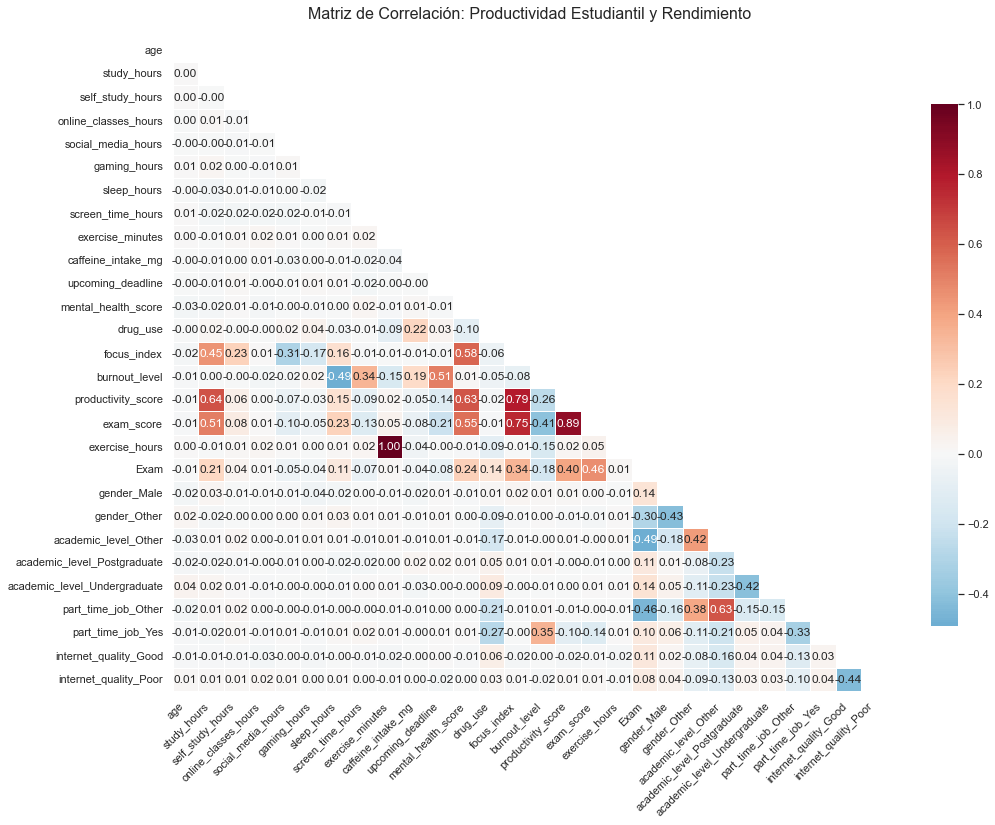


VARIABLES MÁS CORRELACIONADAS CON EXAM_SCORE
exam_score                      1.000000
productivity_score              0.886618
focus_index                     0.750577
mental_health_score             0.547794
study_hours                     0.509619
Exam                            0.461213
sleep_hours                     0.234670
self_study_hours                0.083280
exercise_minutes                0.045482
exercise_hours                  0.045482
internet_quality_Poor           0.014920
academic_level_Undergraduate    0.008222
online_classes_hours            0.006132
gender_Male                     0.004148
academic_level_Other           -0.000516
part_time_job_Other            -0.002968
academic_level_Postgraduate    -0.006853
age                            -0.008330
drug_use                       -0.011825
internet_quality_Good          -0.012176
gender_Other                   -0.014941
gaming_hours                   -0.051127
caffeine_intake_mg             -0.076370
social_medi

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Copia de seguridad y Limpieza / Normalización
df_clean_corr = df.copy()

# Normalización de variables categóricas (Unificación de Yes/yes, espacios y mayúsculas)
columnas_obj = df_clean_corr.select_dtypes(include=['object']).columns
for col in columnas_obj:
    df_clean_corr[col] = df_clean_corr[col].astype(str).str.strip().str.capitalize()
    df_clean_corr[col] = df_clean_corr[col].replace(['Nan', 'None', 'Null', ''], np.nan)

# 2. Transformaciones de variables
# Dummy Exam (1 si nota > 1.0)
if 'exam_score' in df_clean_corr.columns:
    df_clean_corr['Exam'] = np.where(df_clean_corr['exam_score'] > 1.0, 1, 0)

# De minutos a horas (Numérica)
if 'exercise_minutes' in df_clean_corr.columns:
    df_clean_corr['exercise_minutes'] = pd.to_numeric(df_clean_corr['exercise_minutes'], errors='coerce')
    df_clean_corr['exercise_hours'] = df_clean_corr['exercise_minutes'] / 60

# 3. Preparación de Matriz (Convertir categorías a números para correlacionar)
# Omitimos student_id para que no ensucie la gráfica
df_numeric = pd.get_dummies(df_clean_corr.drop(columns=['student_id'], errors='ignore'), drop_first=True)
corr_matrix = df_numeric.corr()

# 4. Generación de Gráfico Estilo Profesional
plt.figure(figsize=(16, 12))

# Crear máscara para ocultar la mitad superior (estilo espejo)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Dibujar Heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title("Matriz de Correlación: Productividad Estudiantil y Rendimiento", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# 5. Entrega de Listas de Correlación (Ordenadas por fuerza de impacto)
print("\n" + "="*50)
print("VARIABLES MÁS CORRELACIONADAS CON EXAM_SCORE")
print("="*50)
print(corr_matrix['exam_score'].sort_values(ascending=False).to_string())

print("\n" + "="*50)
print("VARIABLES MÁS CORRELACIONADAS CON EXAM (ASISTENCIA)")
print("="*50)
print(corr_matrix['Exam'].sort_values(ascending=False).to_string())

Tratamiento de la base de datos 
5621 DATOS TOTALES 


In [ ]:
import pandas as pd

# 1. Definimos las columnas a ignorar para el conteo de nulos
# Excluimos 'exam_score' para que no afecte la decisión de limpieza
# y 'student_id' porque no es una variable de datos reales.
columnas_a_excluir = ['exam_score', 'student_id']
columnas_analisis = [col for col in df.columns if col not in columnas_a_excluir]

# 2. Calcular nulos por estudiante usando solo las columnas de análisis
# Esto evita que 'exam_score' influya en el conteo.
nulos_por_estudiante = df[columnas_analisis].isnull().sum(axis=1)

# 3. Crear la tabla de frecuencias
conteo_nulos = nulos_por_estudiante.value_counts().reset_index()
conteo_nulos.columns = ['Cantidad de valores NaN (excluyendo Score)', 'Cantidad de estudiantes']

# 4. Ordenar para lectura
conteo_nulos = conteo_nulos.sort_values(by='Cantidad de valores NaN (excluyendo Score)')

# 5. Mostrar resultado
print("="*60)
print("DISTRIBUCIÓN DE VALORES NULOS POR ESTUDIANTE")
print("(Análisis independiente de la asistencia al examen)")
print("="*60)
print(conteo_nulos.to_string(index=False))

# 6. Identificar el máximo de nulos en variables predictoras
max_nulos = nulos_por_estudiante.max()
print(f"\nNota: El máximo de nulos en predictores es: {max_nulos}")

DISTRIBUCIÓN DE VALORES NULOS POR ESTUDIANTE
(Análisis independiente de la asistencia al examen)
 Cantidad de valores NaN (excluyendo Score)  Cantidad de estudiantes
                                          0                      988
                                          1                     2650
                                          2                      397
                                          3                      625
                                          4                      180
                                          5                      101
                                          6                       43
                                          7                        9
                                          8                        4
                                          9                        7
                                         10                        2
                                         11                       23
      

eliminaremos las filas con 11 o mas variables Nan (mas del 50% ) ya que estoas producen ruido 

In [ ]:
import pandas as pd

# 1. Crear la nueva base de datos filtrando las filas
# Mantenemos solo aquellas donde la suma de nulos por fila es menor o igual a 10
df_filtrado = df[df.isnull().sum(axis=1) <= 10].copy()

# 2. Cálculos para el reporte de limpieza
filas_originales = len(df)
filas_finales = len(df_filtrado)
filas_eliminadas = filas_originales - filas_finales

# 3. Mostrar resultados
print("="*60)
print("REPORTE DE LIMPIEZA DE DATOS (UMBRAL > 10 NAN)")
print("="*60)
print(f"Cantidad de filas en la base original: {filas_originales}")
print(f"Cantidad de filas en la nueva base:     {filas_finales}")
print(f"Total de estudiantes eliminados:        {filas_eliminadas}")
print("-"*60)

# Verificamos si aún quedan nulos críticos en la nueva base
nulos_restantes = df_filtrado.isnull().sum().sum()
print(f"Total de valores NaN restantes en el dataset: {nulos_restantes}")
print("="*60)

# 4. Asignar la nueva base para los siguientes análisis
# df = df_filtrado  # Descomenta esta línea si quieres sobreescribir la base principal

REPORTE DE LIMPIEZA DE DATOS (UMBRAL > 10 NAN)
Cantidad de filas en la base original: 5621
Cantidad de filas en la nueva base:     5004
Total de estudiantes eliminados:        617
------------------------------------------------------------
Total de valores NaN restantes en el dataset: 7151


2) Variables dammy 

In [ ]:
import pandas as pd
import numpy as np

# Trabajamos sobre la base ya filtrada (menos de 11 nulos)
df_final = df_filtrado.copy()

# 1. Variable indicadora "Exam" (1 si asistió/tiene nota, 0 si no)
# Asumimos que notas > 1.0 implican asistencia real
df_final['Exam'] = np.where(df_final['exam_score'] > 1.0, 1, 0)

# 2. Variable indicadora "gaming_hours_Index"
# Captura la presencia de actividad o respuesta (1 si tiene horas > 0, 0 si es 0 o NaN)
df_final['gaming_hours_Index'] = np.where(df_final['gaming_hours'] > 0, 1, 0)

# 3. Variable indicadora "online_classes_hours_index"
# (1 si asiste a clases online, 0 si es 0 o no respondió)
df_final['online_classes_hours_index'] = np.where(df_final['online_classes_hours'] > 0, 1, 0)

# 4. Transformación: exercise_minutes a exercise_hours (Numérica)
# Primero aseguramos que sea numérica para evitar errores
df_final['exercise_minutes'] = pd.to_numeric(df_final['exercise_minutes'], errors='coerce')
df_final['exercise_hours'] = df_final['exercise_minutes'] / 60

# 5. Variable indicadora "exercise_minutes_index"
# (0 indica que no respondió o tiene NaN, 1 indica que sí hay registro de actividad)
df_final['exercise_minutes_index'] = np.where(df_final['exercise_minutes'].notnull() & (df_final['exercise_minutes'] > 0), 1, 0)

# --- Verificación de resultados ---
print("="*60)
print("REPORTE DE NUEVAS VARIABLES INDICADORAS")
print("="*60)
cols_nuevas = ['Exam', 'gaming_hours_Index', 'online_classes_hours_index', 'exercise_hours', 'exercise_minutes_index']
print(df_final[cols_nuevas].head())
print("\nConteo de valores en los nuevos Índices:")
for col in ['gaming_hours_Index', 'online_classes_hours_index', 'exercise_minutes_index']:
    print(f"\n{col}:")
    print(df_final[col].value_counts())
print("="*60)

REPORTE DE NUEVAS VARIABLES INDICADORAS
   Exam  gaming_hours_Index  online_classes_hours_index  exercise_hours  \
0     1                   1                           1        0.900000   
1     1                   1                           1        1.050000   
2     1                   1                           0        0.466667   
3     0                   1                           1        0.916667   
4     1                   1                           1        1.000000   

   exercise_minutes_index  
0                       1  
1                       1  
2                       1  
3                       1  
4                       1  

Conteo de valores en los nuevos Índices:

gaming_hours_Index:
1    4324
0     680
Name: gaming_hours_Index, dtype: int64

online_classes_hours_index:
1    4748
0     256
Name: online_classes_hours_index, dtype: int64

exercise_minutes_index:
1    4314
0     690
Name: exercise_minutes_index, dtype: int64


creacion de variables indicadoras 

In [ ]:
import pandas as pd
import numpy as np

# Trabajamos sobre la base filtrada (la que tiene 10 o menos nulos)
df_final = df_filtrado.copy()

# 1. Variable indicadora "Exam" (1 si rindió, 0 si no)
# Se basa en la existencia de una nota válida
df_final['Exam'] = np.where(df_final['exam_score'] > 0, 1, 0)

# 2. Variable indicadora "gaming_hours_Index" 
# (1 si registra horas de juego > 0, 0 si es 0 o NaN)
df_final['gaming_hours_Index'] = np.where(df_final['gaming_hours'] > 0, 1, 0)

# 3. Variable indicadora "online_classes_hours_index"
# (1 si registra asistencia a clases online > 0, 0 si es 0 o NaN)
df_final['online_classes_hours_index'] = np.where(df_final['online_classes_hours'] > 0, 1, 0)

# 4. Transformación: exercise_minutes a exercise_hours (Numérica)
# Aseguramos conversión a float para el cálculo
df_final['exercise_minutes'] = pd.to_numeric(df_final['exercise_minutes'], errors='coerce')
df_final['exercise_hours'] = df_final['exercise_minutes'] / 60

# 5. Variable indicadora "exercise_hours_index"
# (0 indica no respondió o es NaN/0, 1 indica que sí registró actividad)
df_final['exercise_hours_index'] = np.where(df_final['exercise_hours'] > 0, 1, 0)

# --- Reporte de verificación ---
print("="*60)
print("RESUMEN DE NUEVAS VARIABLES INDICADORAS")
print("="*60)
indices = ['Exam', 'gaming_hours_Index', 'online_classes_hours_index', 'exercise_hours_index']
for col in indices:
    print(f"\nDistribución de {col}:")
    print(df_final[col].value_counts(normalize=True).map('{:.2%}'.format))

print("\nEstadísticas de exercise_hours (Post-conversión):")
print(df_final['exercise_hours'].describe())
print("="*60)

RESUMEN DE NUEVAS VARIABLES INDICADORAS

Distribución de Exam:
1    96.18%
0     3.82%
Name: Exam, dtype: object

Distribución de gaming_hours_Index:
1    86.41%
0    13.59%
Name: gaming_hours_Index, dtype: object

Distribución de online_classes_hours_index:
1    94.88%
0     5.12%
Name: online_classes_hours_index, dtype: object

Distribución de exercise_hours_index:
1    86.21%
0    13.79%
Name: exercise_hours_index, dtype: object

Estadísticas de exercise_hours (Post-conversión):
count    4346.000000
mean        1.237736
std         0.717854
min         0.000000
25%         0.616667
50%         1.250000
75%         1.850000
max         2.483333
Name: exercise_hours, dtype: float64


aplicacion de outlionrs 

In [ ]:
import pandas as pd

# 1. Seleccionar solo las variables numéricas para el análisis
df_numericas = df_final.select_dtypes(include=['float64', 'int64'])

# 2. Crear una lista para almacenar los resultados
resultados_outliers = []

for columna in df_numericas.columns:
    # Ignorar columnas que son índices o binarias (como las que creamos recién)
    if df_numericas[columna].nunique() <= 2 or 'id' in columna.lower():
        continue
        
    # Calcular Q1, Q3 e IQR
    Q1 = df_numericas[columna].quantile(0.25)
    Q3 = df_numericas[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definir límites de los bigotes
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contar cuántas filas exceden estos límites
    conteo = df_numericas[(df_numericas[columna] < limite_inferior) | 
                         (df_numericas[columna] > limite_superior)].shape[0]
    
    resultados_outliers.append({
        'Variable': columna,
        'Cantidad de Outliers': conteo,
        'Porcentaje del Total': f"{(conteo / len(df_final)):.2%}"
    })

# 3. Crear DataFrame de resultados y ordenar de mayor a menor
tabla_outliers = pd.DataFrame(resultados_outliers).sort_values(by='Cantidad de Outliers', ascending=False)

# 4. Mostrar la tabla
print("="*60)
print("ANÁLISIS DE OUTLIERS (MÉTODO DIAGRAMA DE BIGOTES)")
print("="*60)
print(tabla_outliers.to_string(index=False))
print("="*60)

ANÁLISIS DE OUTLIERS (MÉTODO DIAGRAMA DE BIGOTES)
            Variable  Cantidad de Outliers Porcentaje del Total
         focus_index                    24                0.48%
  social_media_hours                    22                0.44%
         study_hours                    17                0.34%
        gaming_hours                    17                0.34%
       burnout_level                    16                0.32%
online_classes_hours                    15                0.30%
   screen_time_hours                    15                0.30%
    self_study_hours                    12                0.24%
          exam_score                     9                0.18%
  productivity_score                     8                0.16%
                 age                     0                0.00%
         sleep_hours                     0                0.00%
    exercise_minutes                     0                0.00%
  caffeine_intake_mg                     0            

Eliminacion de filas con variables outliors (como son pocas , menos del 1% c/u es razonable)

In [ ]:
import pandas as pd

# 1. Creamos una copia de la base de datos actual
df_sin_outliers = df_final.copy()

# 2. Definimos las variables numéricas que mostraron outliers en tu tabla
vars_con_outliers = [
    'focus_index', 'social_media_hours', 'study_hours', 'gaming_hours', 
    'burnout_level', 'online_classes_hours', 'screen_time_hours', 
    'self_study_hours', 'productivity_score'
]

# 3. Proceso de eliminación iterativo
for col in vars_con_outliers:
    # Calculamos límites para la columna actual
    Q1 = df_sin_outliers[col].quantile(0.1)
    Q3 = df_sin_outliers[col].quantile(0.9)
    IQR = Q3 - Q1
    
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    # Filtramos la base manteniendo solo lo que está dentro de los bigotes
    df_sin_outliers = df_sin_outliers[
        (df_sin_outliers[col] >= lim_inf) & (df_sin_outliers[col] <= lim_sup)
    ]

# 4. Reporte de impacto
filas_antes = len(df_final)
filas_despues = len(df_sin_outliers)
total_eliminados = filas_antes - filas_despues

print("="*60)
print("DEPURACIÓN DE OUTLIERS FINALIZADA")
print("="*60)
print(f"Estudiantes antes de limpiar outliers: {filas_antes}")
print(f"Estudiantes después de limpiar outliers: {filas_despues}")
print(f"Total de registros eliminados:           {total_eliminados}")
print(f"Porcentaje total de reducción:           {(total_eliminados/filas_antes):.2%}")
print("="*60)

DEPURACIÓN DE OUTLIERS FINALIZADA
Estudiantes antes de limpiar outliers: 5004
Estudiantes después de limpiar outliers: 4246
Total de registros eliminados:           758
Porcentaje total de reducción:           15.15%


4) Imputacion 

In [ ]:
import pandas as pd
import numpy as np

# 1. Crear copia de la base sin outliers
df_final_imputada = df_sin_outliers.copy()

# 2. ELIMINACIÓN DE VARIABLE CON EXCESO DE NULOS (Punto 4.3)
if 'drug_use' in df_final_imputada.columns:
    df_final_imputada = df_final_imputada.drop(columns=['drug_use'])
    print("- Variable 'drug_use' eliminada (exceso de NAs > 70%).")

# 3. NORMALIZACIÓN Y UNIFICACIÓN DE CATEGÓRICAS (Punto 4.2, 4.5)
columnas_categ = ['gender', 'academic_level', 'part_time_job', 'internet_quality']

for col in columnas_categ:
    if col in df_final_imputada.columns:
        # Quitar espacios y estandarizar (Capitalize arregla Yes/yes y duplicados de nivel académico)
        df_final_imputada[col] = df_final_imputada[col].astype(str).str.strip().str.capitalize()
        
        # 4. IMPUTACIÓN CATEGÓRICA CON "OTHER" (Punto 4.1)
        # Reemplazamos los valores que quedaron como 'Nan' o nulos reales por 'Other'
        df_final_imputada[col] = df_final_imputada[col].replace(['Nan', 'None', 'Null', ''], 'Other')

# 5. IMPUTACIÓN DE VARIABLES NUMÉRICAS CON LA MEDIA (Punto 4.4)
# Seleccionamos solo las columnas numéricas
columnas_num = df_final_imputada.select_dtypes(include=[np.number]).columns

for col in columnas_num:
    # No imputamos la variable objetivo 'exam_score' si ya está limpia, ni 'student_id'
    if col not in ['student_id', 'exam_score']:
        media = df_final_imputada[col].mean()
        df_final_imputada[col] = df_final_imputada[col].fillna(media)

# --- Verificación Final ---
print("="*60)
print("REPORTE FINAL DE IMPUTACIÓN")
print("="*60)
print(f"Total de nulos restantes en la base: {df_final_imputada.isnull().sum().sum()}")
print(f"Dimensiones finales de la base:      {df_final_imputada.shape}")
print("-" * 60)
print("Categorías únicas en 'part_time_job':", df_final_imputada['part_time_job'].unique())
print("Categorías únicas en 'academic_level':", df_final_imputada['academic_level'].unique())
print("="*60)

- Variable 'drug_use' eliminada (exceso de NAs > 70%).
REPORTE FINAL DE IMPUTACIÓN
Total de nulos restantes en la base: 66
Dimensiones finales de la base:      (4246, 26)
------------------------------------------------------------
Categorías únicas en 'part_time_job': ['No' 'Yes' 'Other']
Categorías únicas en 'academic_level': ['Undergraduate' 'High school' 'Postgraduate' 'Other']


In [ ]:
import pandas as pd

# 1. Vista previa de los datos (primeras 5 filas)
print("="*60)
print("VISTA PREVIA DE LA BASE DE DATOS FINAL")
print("="*60)
display(df_final_imputada.head()) 

# 2. Información estructural (Tipos de datos y memoria)
print("\n" + "="*60)
print("ESTRUCTURA Y VALORES NO NULOS")
print("="*60)
df_final_imputada.info()

# 3. Resumen estadístico de variables numéricas
print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO (VARIABLES NUMÉRICAS)")
print("="*60)
# Incluimos .T (transponer) para que sea más fácil de leer si hay muchas columnas
display(df_final_imputada.describe().T)

# 4. Verificación de categorías únicas (Variables cualitativas)
print("\n" + "="*60)
print("CONTEO DE CATEGORÍAS (VARIABLES CUALITATIVAS)")
print("="*60)
columnas_obj = df_final_imputada.select_dtypes(include=['object']).columns
for col in columnas_obj:
    print(f"\nColumna: {col}")
    print(df_final_imputada[col].value_counts())

# 5. Comprobación final de Nulos
print("\n" + "="*60)
print("COMPROBACIÓN FINAL DE NULOS")
print("="*60)
print(df_final_imputada.isnull().sum())

VISTA PREVIA DE LA BASE DE DATOS FINAL


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,exercise_hours,Exam,gaming_hours_Index,online_classes_hours_index,exercise_hours_index
0,1,20.0,Other,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,3.0,19.01,31.77,42.59,25.08,0.900000,1,1,1,1
1,2,16.0,Female,High school,5.85,5.04,1.87,3.60,2.79,6.11,...,10.0,42.10,45.89,67.15,37.83,1.050000,1,1,1,1
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,5.0,21.93,37.07,37.68,18.66,0.466667,1,1,0,1
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,3.0,13.47,43.63,12.83,1.00,0.916667,1,1,1,1
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,2.0,19.95,56.62,18.53,7.78,1.000000,1,1,1,1



ESTRUCTURA Y VALORES NO NULOS
<class 'pandas.core.frame.DataFrame'>
Int64Index: 4246 entries, 0 to 5620
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  4246 non-null   int64  
 1   age                         4246 non-null   float64
 2   gender                      4246 non-null   object 
 3   academic_level              4246 non-null   object 
 4   study_hours                 4246 non-null   float64
 5   self_study_hours            4246 non-null   float64
 6   online_classes_hours        4246 non-null   float64
 7   social_media_hours          4246 non-null   float64
 8   gaming_hours                4246 non-null   float64
 9   sleep_hours                 4246 non-null   float64
 10  screen_time_hours           4246 non-null   float64
 11  exercise_minutes            4246 non-null   float64
 12  caffeine_intake_mg          4246 non-null   float64
 13  pa

,count,mean,std,min,25%,50%,75%,max
student_id,4246.0,2803.967970,1629.062455,1.0,1385.250000,2792.000000,4238.7500,5621.000000
age,4246.0,20.532570,2.845338,16.0,18.000000,20.532570,23.0000,25.000000
study_hours,4246.0,4.535238,1.822396,0.0,3.270000,4.530000,5.7600,10.800000
self_study_hours,4246.0,2.476656,1.177803,0.0,1.650000,2.480000,3.2875,6.520000
online_classes_hours,4246.0,2.018394,0.990083,0.0,1.320000,2.010000,2.7000,6.000000
social_media_hours,4246.0,3.003024,1.478582,0.0,1.990000,2.980000,4.0400,8.280000
gaming_hours,4246.0,1.567388,1.109702,0.0,0.670000,1.495000,2.3500,5.640000
sleep_hours,4246.0,7.022171,1.160864,4.0,6.240000,7.022171,7.8175,10.000000
screen_time_hours,4246.0,6.995080,2.481377,1.0,5.300000,6.990000,8.7100,15.300000
exercise_minutes,4246.0,73.974993,40.374597,0.0,41.000000,73.974993,105.0000,149.000000



CONTEO DE CATEGORÍAS (VARIABLES CUALITATIVAS)

Columna: gender
Male      1859
Female    1824
Other      563
Name: gender, dtype: int64

Columna: academic_level
Postgraduate     1416
High school      1410
Undergraduate    1388
Other              32
Name: academic_level, dtype: int64

Columna: part_time_job
Yes      2101
No       2084
Other      61
Name: part_time_job, dtype: int64

Columna: internet_quality
Good       1461
Average    1417
Poor       1340
Other        28
Name: internet_quality, dtype: int64

COMPROBACIÓN FINAL DE NULOS
student_id                     0
age                            0
gender                         0
academic_level                 0
study_hours                    0
self_study_hours               0
online_classes_hours           0
social_media_hours             0
gaming_hours                   0
sleep_hours                    0
screen_time_hours              0
exercise_minutes               0
caffeine_intake_mg             0
part_time_job                 

2.APLICACION DE MCO completo 

In [ ]:
import statsmodels.api as sm
import pandas as pd

# 1. Preparación de los datos
# Creamos las dummies para las variables categóricas que ya normalizamos
df_modelo = pd.get_dummies(df_final_imputada.drop(columns=['student_id', 'exam_score']), drop_first=True)

# 2. Definición de variables
# Variable dependiente: Exam
# Variable independiente: Todas las demás
y = df_modelo['Exam']
X = df_modelo.drop(columns=['Exam'])

# 3. Añadir la constante (Intercepto)
X = sm.add_constant(X)

# 4. Ajuste del modelo MCO (OLS)
modelo_mco = sm.OLS(y, X.astype(float)).fit()

# 5. Mostrar resultados
print(modelo_mco.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     6.338
Date:              jue., 09 abr. 2026   Prob (F-statistic):           4.34e-23
Time:                        18:15:23   Log-Likelihood:                 2936.3
No. Observations:                4246   AIC:                            -5815.
Df Residuals:                    4217   BIC:                            -5630.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [ ]:
# 1. Revisa si la variable objetivo tiene variación
print("Distribución de Exam:")
print(df_final_imputada['Exam'].value_counts())

# 2. Identifica variables con varianza cero (constantes)
constantes = [col for col in X.columns if X[col].std() == 0 and col != 'const']
print(f"\nVariables constantes detectadas (eliminar): {constantes}")

# 3. Revisa la matriz de diseño (X) por valores extremadamente grandes o pequeños
print("\nVerificación de tipos de datos en X:")
print(X.dtypes.value_counts())

# 4. Intenta limpiar variables redundantes y relanzar
# Asegúrate de que no haya correlaciones de 1.0
df_sin_redundancia = X.drop(columns=constantes)

Distribución de Exam:
1    4180
Name: Exam, dtype: int64

Variables constantes detectadas (eliminar): []

Verificación de tipos de datos en X:
float64    17
uint8      10
int32       3
dtype: int64


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



In [ ]:
#LIMPIEZA DE LA BASE DE DATOS 
import pandas as pd
import numpy as np

# 1. EXCLUIR CASOS (Umbral > 15 NaNs)
# Evaluamos nulos sin considerar 'exam_score' para no sesgar la variable 'Exam'
columnas_estudio = [col for col in df.columns if col not in ['exam_score', 'student_id']]
df_limpio = df[df[columnas_estudio].isnull().sum(axis=1) <= 15].copy()

# 2. VARIABLE INDICADORA E INGENIERÍA
# Variable 'Exam': 0 si la nota es 1.0 (no rindió), 1 en caso contrario
df_limpio['Exam'] = np.where(df_limpio['exam_score'] > 1.0, 1, 0)

# Dummy "gaming_hours_Index"
df_limpio['gaming_hours_Index'] = np.where(df_limpio['gaming_hours'] > 0, 1, 0)

# Dummy "online_classes_hours_index"
df_limpio['online_classes_hours_index'] = np.where(df_limpio['online_classes_hours'] > 0, 1, 0)

# Transformación de ejercicio (Minutos a Horas y Dummy Index)
df_limpio['exercise_minutes'] = pd.to_numeric(df_limpio['exercise_minutes'], errors='coerce')
df_limpio['exercise_hours'] = df_limpio['exercise_minutes'] / 60
df_limpio['exercise_hours_index'] = np.where(df_limpio['exercise_hours'] > 0, 1, 0)

# Eliminamos la original de minutos
df_limpio = df_limpio.drop(columns=['exercise_minutes'])




# 4. IMPUTACIÓN Y NORMALIZACIÓN
# 4.3) Quitar drug_use por exceso de NAs
if 'drug_use' in df_limpio.columns:
    df_limpio = df_limpio.drop(columns=['drug_use'])

# 4.1, 4.2, 4.5) Normalización de categóricas y corregir duplicados
cats = ['gender', 'academic_level', 'part_time_job']
for col in cats:
    if col in df_limpio.columns:
        # Quitar espacios, estandarizar mayúsculas (soluciona Yes/yes, Undergraduate/undergraduate)
        df_limpio[col] = df_limpio[col].astype(str).str.strip().str.capitalize()
        # Rellenar vacíos con 'Other'
        df_limpio[col] = df_limpio[col].replace(['Nan', 'None', 'Null', ''], 'Other')

# 4.4) Imputación de numéricas con la media
num_cols = df_limpio.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if col not in ['student_id', 'exam_score', 'Exam']:
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].mean())

# RESULTADOS FINALES
filas_finales, columnas_finales = df_limpio.shape

print("="*60)
print("PROCESAMIENTO COMPLETO DE BASE DE DATOS")
print("="*60)
print(f"Cantidad de FILAS finales:    {filas_finales}")
print(f"Cantidad de COLUMNAS finales: {columnas_finales}")
print("-" * 60)
print("Distribución de la variable 'Exam' (Asistencia):")
print(df_limpio['Exam'].value_counts())
print("="*60)

# Guardamos como la nueva base limpia
df_final = df_limpio

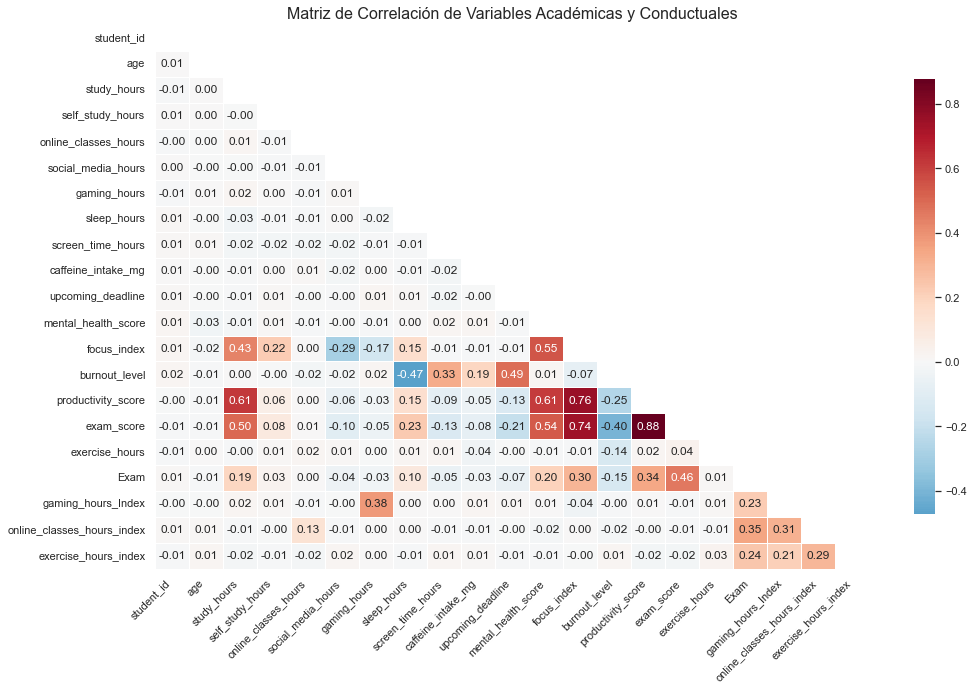

CORRELACIÓN DE LAS VARIABLES CON LA ASISTENCIA (EXAM)
Exam                          1.000000
exam_score                    0.461936
online_classes_hours_index    0.346891
productivity_score            0.337479
focus_index                   0.296882
exercise_hours_index          0.240215
gaming_hours_Index            0.227125
mental_health_score           0.199104
study_hours                   0.189440
sleep_hours                   0.095261
self_study_hours              0.031691
exercise_hours                0.010036
student_id                    0.009751
online_classes_hours          0.004070
age                          -0.007664
caffeine_intake_mg           -0.028814
gaming_hours                 -0.029509
social_media_hours           -0.041743
screen_time_hours            -0.053835
upcoming_deadline            -0.065849
burnout_level                -0.150911
Name: Exam, dtype: float64


In [ ]:
#MATRIZ DE CORRELACION 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Seleccionamos solo las variables numéricas para la correlación
# Incluimos las dummies y los índices que creamos
df_corr = df_limpio.select_dtypes(include=[np.number])

# 2. Calcular la matriz de correlación
matriz_corr = df_corr.corr()

# 3. Configuración del gráfico (Heatmap)
plt.figure(figsize=(16, 10))

# Creamos una máscara para ver solo la mitad inferior (opcional, evita duplicados)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Dibujar el heatmap
sns.heatmap(matriz_corr, 
            mask=mask, 
            annot=True,          # Muestra los números dentro de los cuadros
            fmt=".2f",           # Dos decimales
            cmap='RdBu_r',       # Color: Rojo (negativo) a Azul (positivo)
            center=0,            # El blanco es el 0
            linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación de Variables Académicas y Conductuales', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

# 4. Mostrar las correlaciones más altas con la variable "Exam"
print("="*60)
print("CORRELACIÓN DE LAS VARIABLES CON LA ASISTENCIA (EXAM)")
print("="*60)
print(matriz_corr['Exam'].sort_values(ascending=False))

In [ ]:
#Modelo MCO COMPLETO 
import statsmodels.api as sm
import pandas as pd

# 1. Preparación de variables categóricas
# Convertimos variables como 'gender' y 'academic_level' en dummies numéricas
df_mco = pd.get_dummies(df_limpio, drop_first=True)

# 2. Definición de variables
# Excluimos 'exam_score' (porque define a Exam) y 'student_id'
X = df_mco.drop(columns=['Exam', 'exam_score', 'student_id'], errors='ignore')
y = df_mco['Exam']

# 3. Asegurar que todos los datos sean flotantes para evitar errores de cálculo
X = X.astype(float)

# 4. Añadir la constante (Intercepto)
X = sm.add_constant(X)

# 5. Ajuste del modelo MCO (OLS)
modelo_asistencia = sm.OLS(y, X).fit()

# 6. Mostrar el resumen de resultados
print(modelo_asistencia.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     112.2
Date:              jue., 09 abr. 2026   Prob (F-statistic):               0.00
Time:                        19:02:03   Log-Likelihood:                -1307.3
No. Observations:                5424   AIC:                             2671.
Df Residuals:                    5396   BIC:                             2855.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [ ]:
#MODELO MCO SIGNIFICATIVO 
import statsmodels.api as sm
import pandas as pd

# 1. Lista de variables originales que resultaron significativas (o contienen categorías significativas)
vars_originales_sig = [
    'focus_index', 
    'burnout_level', 
    'productivity_score', 
    'gaming_hours_Index', 
    'online_classes_hours_index', 
    'exercise_hours_index',
    'gender',           # Contiene gender_Other
    'academic_level',   # Contiene Undergraduate y Other
    'part_time_job',    # Contiene Other
    'internet_quality'  # Contiene Good
]

# 2. Creamos un nuevo DataFrame solo con estas variables + la dependiente
df_reducido = df_limpio[vars_originales_sig + ['Exam']].copy()

# 3. Convertimos las categóricas en dummies (Numéricas para el modelo)
# drop_first=True es vital para evitar la trampa de la variable ficticia
df_final_model = pd.get_dummies(df_reducido, drop_first=True)

# 4. Definir X e y
y = df_final_model['Exam']
X = df_final_model.drop(columns=['Exam']).astype(float)

# 5. Añadir constante
X = sm.add_constant(X)

# 6. Ajustar modelo final
modelo_final = sm.OLS(y, X).fit()

# 7. Resultados
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     201.7
Date:              jue., 09 abr. 2026   Prob (F-statistic):               0.00
Time:                        19:07:52   Log-Likelihood:                -1310.4
No. Observations:                5424   AIC:                             2653.
Df Residuals:                    5408   BIC:                             2758.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [ ]:
#MODELO MCO CON VARIABLES DE INTERES SIN CORRELACION 
import statsmodels.api as sm
import pandas as pd

# 1. Selección de variables solicitadas
# Nota: Usamos df_limpio que ya tiene las transformaciones y limpieza final
vars_modelo = [
    'gaming_hours',
    'exercise_hours',
    'mental_health_score',
    'burnout_level',
    'productivity_score',
    'online_classes_hours_index'
]

# 2. Preparación de matrices
# Aseguramos que los datos sean numéricos y manejables por el algoritmo
X = df_limpio[vars_modelo].astype(float)
y = df_limpio['Exam']

# 3. Añadir la constante (Intercepto)
# Indispensable en MCO para que los residuos tengan media cero
X = sm.add_constant(X)

# 4. Ajuste del modelo MCO (OLS)
modelo_conductual = sm.OLS(y, X).fit()

# 5. Visualización de resultados
print("="*60)
print("MODELO MCO: DETERMINANTES CONDUCTUALES DE LA ASISTENCIA")
print("="*60)
print(modelo_conductual.summary())

# 6. Guardar coeficientes para análisis rápido
coeficientes = modelo_conductual.params
print("\nInterpretación rápida de coeficientes:")
print(coeficientes)

MODELO MCO: DETERMINANTES CONDUCTUALES DE LA ASISTENCIA
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     284.2
Date:              jue., 09 abr. 2026   Prob (F-statistic):          2.39e-317
Time:                        19:41:12   Log-Likelihood:                -1773.3
No. Observations:                5424   AIC:                             3561.
Df Residuals:                    5417   BIC:                             3607.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [ ]:
#PREGUNTA 4.1
#modelo provit 
import statsmodels.api as sm
import pandas as pd

# 1. Preparación de datos (Dummies y limpieza de nombres)
df_probit = pd.get_dummies(df_limpio, drop_first=True)
X = df_probit.drop(columns=['Exam', 'exam_score', 'student_id'], errors='ignore')
y = df_probit['Exam']
X = sm.add_constant(X).astype(float)

# 2. AJUSTE DEL MODELO PROBIT (Summary estándar)
# Este paso es necesario para ver el ajuste global del modelo
modelo_probit = sm.Probit(y, X).fit()

print("\n" + "="*80)
print("1. RESUMEN GLOBAL DEL MODELO PROBIT (Coeficientes Beta)")
print("="*80)
print(modelo_probit.summary())

# 3. CÁLCULO DE EFECTOS MARGINALES (dy/dx)
# Calculamos el Efecto Marginal Promedio (AME)
probit_margeff = modelo_probit.get_margeff(at='overall', method='dydx')

print("\n" + "="*80)
print("2. EFECTOS MARGINALES DEL MODELO PROBIT (Interpretación dy/dx)")
print("="*80)
print(probit_margeff.summary())


Optimization terminated successfully.
         Current function value: 0.287396
         Iterations 7

1. RESUMEN GLOBAL DEL MODELO PROBIT (Coeficientes Beta)
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5424
Model:                         Probit   Df Residuals:                     5396
Method:                           MLE   Df Model:                           27
Date:              jue., 09 abr. 2026   Pseudo R-squ.:                  0.3917
Time:                        21:37:29   Log-Likelihood:                -1558.8
converged:                       True   LL-Null:                       -2562.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const          

In [ ]:
#PREGUNTA 3.2
#modelo provit significativo 
import statsmodels.api as sm
import pandas as pd

# 1. Lista de variables originales que contienen categorías significativas
vars_originales = [
    'focus_index', 
    'burnout_level', 
    'productivity_score', 
    'gaming_hours_Index', 
    'online_classes_hours_index', 
    'exercise_hours_index',
    'gender',           # Contiene 'Other'
    'academic_level',   # Contiene 'Undergraduate' y 'Other'
    'part_time_job',    # Contiene 'Other'
    'internet_quality'  # Contiene 'Good'
]

# 2. Preparación del DataFrame
# Seleccionamos las columnas y creamos dummies automáticamente
df_model = pd.get_dummies(df_limpio[vars_originales + ['Exam']], drop_first=True)

# 3. Definir X e y
y = df_model['Exam']
X = df_model.drop(columns=['Exam']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Probit
modelo_probit_final = sm.Probit(y, X).fit()

# 5. RESULTADOS: Summary y Efectos Marginales
print("\n" + "="*80)
print("1. RESUMEN GLOBAL (COEFICIENTES BETA)")
print("="*80)
print(modelo_probit_final.summary())

# Cálculo de dy/dx
margeff_final = modelo_probit_final.get_margeff(at='overall', method='dydx')

print("\n" + "="*80)
print("2. EFECTOS MARGINALES (INTERPRETACIÓN dy/dx)")
print("="*80)
print(margeff_final.summary())


Optimization terminated successfully.
         Current function value: 0.287988
         Iterations 7

1. RESUMEN GLOBAL (COEFICIENTES BETA)
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5424
Model:                         Probit   Df Residuals:                     5408
Method:                           MLE   Df Model:                           15
Date:              jue., 09 abr. 2026   Pseudo R-squ.:                  0.3904
Time:                        21:40:13   Log-Likelihood:                -1562.0
converged:                       True   LL-Null:                       -2562.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -

In [ ]:
#PREGUNTA 4.1
#modelo logit completo
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Preparación de los datos (Dummies automáticas)
df_logit = pd.get_dummies(df_limpio, drop_first=True)

# 2. Definición de variables (Variables originales significativas según tus pruebas)
# Eliminamos los IDs y la nota del examen para evitar sesgos
X = df_logit.drop(columns=['Exam', 'exam_score', 'student_id'], errors='ignore').astype(float)
y = df_logit['Exam']

# 3. Añadir constante
X = sm.add_constant(X)

# 4. Ajuste del modelo Logit
modelo_logit = sm.Logit(y, X).fit()

# 5. RESULTADOS: Resumen Global y Coeficientes Log-Odds
print("\n" + "="*80)
print("1. RESUMEN GLOBAL DEL MODELO LOGIT")
print("="*80)
print(modelo_logit.summary())

# 6. RESULTADOS: Odds Ratios (Interpretación de ventajas)
print("\n" + "="*80)
print("2. ODDS RATIOS (Interpretación de Probabilidades Relativas)")
print("="*80)
odds_ratios = np.exp(modelo_logit.params)
print(odds_ratios)

# 7. RESULTADOS: Efectos Marginales (dy/dx para probabilidad directa)
print("\n" + "="*80)
print("3. EFECTOS MARGINALES (Cambio en probabilidad porcentual)")
print("="*80)
margeff_logit = modelo_logit.get_margeff(at='overall', method='dydx')
print(margeff_logit.summary())


Optimization terminated successfully.
         Current function value: 0.281181
         Iterations 8

1. RESUMEN GLOBAL DEL MODELO LOGIT
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5424
Model:                          Logit   Df Residuals:                     5396
Method:                           MLE   Df Model:                           27
Date:              jue., 09 abr. 2026   Pseudo R-squ.:                  0.4048
Time:                        21:46:47   Log-Likelihood:                -1525.1
converged:                       True   LL-Null:                       -2562.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.1

In [ ]:
#PREGUNTA 4.2
#Modelo logit significativo 
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Definimos las variables originales que contienen las categorías significativas
vars_originales_logit = [
    'focus_index', 
    'burnout_level', 
    'productivity_score', 
    'gaming_hours_Index', 
    'online_classes_hours_index', 
    'exercise_hours_index',
    'gender',           # Contiene gender_Other
    'academic_level',   # Contiene academic_level_Other y _Undergraduate
    'part_time_job',    # Contiene part_time_job_Other
    'internet_quality'  # Contiene internet_quality_Good
]

# 2. Preparación del DataFrame y creación de dummies
df_model_logit = pd.get_dummies(df_limpio[vars_originales_logit + ['Exam']], drop_first=True)

# 3. Definir X e y (asegurando tipo float para los cálculos del Logit)
y = df_model_logit['Exam']
X = df_model_logit.drop(columns=['Exam']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Logit
modelo_logit_final = sm.Logit(y, X).fit()

# 5. RESULTADOS: Resumen y Estadísticos de Ajuste
print("\n" + "="*80)
print("1. RESUMEN GLOBAL DEL MODELO LOGIT (Coeficientes Beta)")
print("="*80)
print(modelo_logit_final.summary())

# 6. RESULTADOS: Odds Ratios (Interpretación de Ventaja Relativa)
print("\n" + "="*80)
print("2. ODDS RATIOS (Exp(Beta))")
print("="*80)
print(np.exp(modelo_logit_final.params))

# 7. RESULTADOS: Efectos Marginales (dy/dx para probabilidad directa)
margeff_logit_final = modelo_logit_final.get_margeff(at='overall', method='dydx')
print("\n" + "="*80)
print("3. EFECTOS MARGINALES DEL MODELO LOGIT (Interpretación dy/dx)")
print("="*80)
print(margeff_logit_final.summary())

Optimization terminated successfully.
         Current function value: 0.281692
         Iterations 8

1. RESUMEN GLOBAL DEL MODELO LOGIT (Coeficientes Beta)
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5424
Model:                          Logit   Df Residuals:                     5408
Method:                           MLE   Df Model:                           15
Date:              jue., 09 abr. 2026   Pseudo R-squ.:                  0.4037
Time:                        21:51:06   Log-Likelihood:                -1527.9
converged:                       True   LL-Null:                       -2562.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [ ]:
#PREGUNTA 6.1
#MODELO POISSON (6) TODAS LAS VARIABLES
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Filtrado: Solo alumnos que rindieron el examen
# Es fundamental modelar el desempeño solo sobre la población observada
df_asistentes = df_limpio[df_limpio['Exam'] == 1].copy()

# 2. Preparación de variables (Creación de dummies para todas las categóricas)
# Excluimos 'Exam' porque ya es constante (1) y 'student_id'
df_poisson_full = pd.get_dummies(df_asistentes.drop(columns=['student_id', 'Exam'], errors='ignore'), drop_first=True)

# 3. Definir variable dependiente e independientes
y = df_poisson_full['exam_score']
X = df_poisson_full.drop(columns=['exam_score']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo de Poisson
# Usamos el Modelo Lineal Generalizado (GLM) con familia Poisson
modelo_poisson_full = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# 5. Resultados
print("\n" + "="*80)
print("RESUMEN DEL MODELO POISSON COMPLETO (Determinantes de la Nota)")
print("="*80)
print(modelo_poisson_full.summary())

# 6. Cálculo de los Incidence Rate Ratios (IRR)
# El IRR es vital para la interpretación en Poisson
irr_full = np.exp(modelo_poisson_full.params)
print("\n" + "="*40)
print("INCIDENCE RATE RATIOS (IRR)")
print("="*40)
print(irr_full)


RESUMEN DEL MODELO POISSON COMPLETO (Determinantes de la Nota)
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 4444
Model:                            GLM   Df Residuals:                     4416
Model Family:                 Poisson   Df Model:                           27
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14411.
Date:              vie., 10 abr. 2026   Deviance:                       8055.1
Time:                        17:07:35   Pearson chi2:                 7.46e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9911
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

In [ ]:
#PREGUNTA 6.2
#Modelo poisson significativo 
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Selección de variables originales significativas
# Agrupamos las categorías en sus variables madre
vars_poisson_sig = [
    'study_hours',
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'online_classes_hours_index',
    'academic_level', # Contiene la categoría 'Other' significativa
    'part_time_job'   # Contiene la categoría 'Other' significativa
]

# 2. Preparación de los datos (Filtrado por Exam == 1)
df_asistentes = df_limpio[df_limpio['Exam'] == 1].copy()
df_final_poisson = pd.get_dummies(df_asistentes[vars_poisson_sig + ['exam_score']], drop_first=True)

# 3. Definición de X e y
y = df_final_poisson['exam_score']
X = df_final_poisson.drop(columns=['exam_score']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo GLM Poisson
modelo_poisson_parsimonioso = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# 5. RESULTADOS
print("\n" + "="*80)
print("RESUMEN DEL MODELO POISSON FINAL (Variables Significativas)")
print("="*80)
print(modelo_poisson_parsimonioso.summary())

# 6. INCIDENCE RATE RATIOS (IRR) - El corazón de la interpretación
print("\n" + "="*40)
print("INCIDENCE RATE RATIOS (IRR)")
print("="*40)
irr_final = np.exp(modelo_poisson_parsimonioso.params)
print(irr_final)


RESUMEN DEL MODELO POISSON FINAL (Variables Significativas)
                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 4444
Model:                            GLM   Df Residuals:                     4431
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14417.
Date:              vie., 10 abr. 2026   Deviance:                       8067.4
Time:                        17:16:40   Pearson chi2:                 7.47e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9911
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

PREGUNTA 7 

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# 1. Preparación de datos (Solo quienes rindieron el examen)
df_asistentes = df_limpio[df_limpio['Exam'] == 1].copy()

# 2. Ajuste del Modelo Poisson Base (con variables significativas previas)
# Nota: Poisson asume que Media = Varianza
X_poisson = pd.get_dummies(df_asistentes[['study_hours', 'mental_health_score', 'focus_index', 
                                         'burnout_level', 'productivity_score']], drop_first=True)
X_poisson = sm.add_constant(X_poisson).astype(float)
y = df_asistentes['exam_score']

modelo_p = sm.GLM(y, X_poisson, family=sm.families.Poisson()).fit()

# 3. Determinación de la Sobredispersión (Ratio de Pearson)
pearson_ratio = modelo_p.pearson_chi2 / modelo_p.df_resid
print(f"Ratio de Dispersión de Pearson: {pearson_ratio:.4f}")

# 4. Cálculo del valor óptimo de Alpha (α)
# Ajustamos un modelo de Binomial Negativa para estimar el parámetro de dispersión
# En statsmodels, el alpha óptimo se encuentra ajustando un modelo de la familia NegativeBinomial
modelo_nb = sm.GLM(y, X_poisson, family=sm.families.NegativeBinomial(alpha=0.1)).fit()

# Para obtener el alpha exacto, usamos un procedimiento de optimización o el modelo auxiliar
df_asistentes['mu'] = modelo_p.predict(X_poisson)
df_asistentes['aux_var'] = ((df_asistentes['exam_score'] - df_asistentes['mu'])**2 - df_asistentes['mu']) / df_asistentes['mu']

# Regresión auxiliar para encontrar alpha (Cameron & Trivedi)
aux_model = sm.OLS(df_asistentes['aux_var'], df_asistentes['mu']).fit()
alpha_optimo = aux_model.params[0]

print(f"Valor óptimo de Alpha (α): {alpha_optimo:.6f}")
print(f"P-valor del Test de Alpha: {aux_model.pvalues[0]:.4f}")

Ratio de Dispersión de Pearson: 1.7026
Valor óptimo de Alpha (α): 0.024233
P-valor del Test de Alpha: 0.0000


PREGUNTA 8 

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Preparación de datos (Filtrado por quienes rindieron)
df_asistentes = df_limpio[df_limpio['Exam'] == 1].copy()

# 2. Selección de variables significativas (basado en el análisis de Poisson y robustez)
# Incluimos las variables originales que mostraron p-valores < 0.05
vars_finales = [
    'study_hours',
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'online_classes_hours_index'
]

# 3. Preparación de matrices
y = df_asistentes['exam_score']
X = pd.get_dummies(df_asistentes[vars_finales], drop_first=True).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Binomial Negativa (NB2)
# Usamos el alpha óptimo calculado previamente (0.0242)
modelo_nb_final = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=0.0242)).fit()

# 5. Resultados e Interpretación (IRR)
print("\n" + "="*80)
print("MODELO FINAL: REGRESIÓN BINOMIAL NEGATIVA (NB2)")
print("="*80)
print(modelo_nb_final.summary())

print("\n" + "="*40)
print("INCIDENCE RATE RATIOS (IRR)")
print("="*40)
print(np.exp(modelo_nb_final.params))

In [ ]:
#BINOMIAL NEGATIVO SIGNIFICATIVO CORRECTO
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Preparación de la muestra (Solo estudiantes que rindieron el examen)
df_asistentes = df_limpio[df_limpio['Exam'] == 1].copy()

# 2. Definición de variables originales significativas
# Nota: Incluimos las variables base que contienen las categorías significativas
vars_finales = [
    'study_hours',
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'online_classes_hours_index',
    'academic_level',
    'part_time_job'
]

# 3. Creación de matrices y dummies
df_final_nb = pd.get_dummies(df_asistentes[vars_finales + ['exam_score']], drop_first=True)
y = df_final_nb['exam_score']
X = df_final_nb.drop(columns=['exam_score']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Binomial Negativa
# Usamos el alpha de 0.0242 detectado en el test de sobredispersión
modelo_nb_final = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=0.0242)).fit()

# 5. Visualización de Resultados
print("\n" + "="*80)
print("RESULTADOS FINALES: REGRESIÓN BINOMIAL NEGATIVA")
print("="*80)
print(modelo_nb_final.summary())

# 6. Cálculo de los IRR para la interpretación académica
irr_final = np.exp(modelo_nb_final.params)
print("\n" + "="*40)
print("INCIDENCE RATE RATIOS (IRR)")
print("="*40)
print(irr_final)

NameError: name 'df_limpio' is not defined